# Pacific County, Washington — Comprehensive Watershed Report

**Every forecast, histogram, trend, and distribution available in hydro-art.**

Pacific County sits on Washington's southwest coast, cradling the Willapa River,
Naselle River, and their tributaries — rain-dominated coastal streams feeding
Willapa Bay, one of the cleanest estuaries in the US. This notebook runs
the full `src/flow_metrics` analytics suite against real USGS gauge records
(NWIS daily-value service), correlates with ENSO (ONI) and PDO climate indices,
and generates every visualization the hydro-art report engine supports — plus
creative additions.

| Gauge | USGS ID | Record |
|-------|---------|--------|
| Willapa River near Willapa | 12013500 | 1961–2024 (64 yr) |
| Naselle River near Naselle | 12010000 | 1960–2003 (44 yr) |

**Data sources:** USGS NWIS (public domain), NOAA CPC ONI, NOAA NCEI PDO — all
federal public domain, commercially sellable with attribution.

In [1]:
# ── imports & paths ──────────────────────────────────────────────────────
import sys
from pathlib import Path

REPO = Path(".").resolve().parent
sys.path.insert(0, str(REPO))

import numpy as np
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker

from src import flow_metrics as fm
from tools.nwis_gauge import GaugeProvider
from tools.climate_index import ClimateIndexProvider
from tools.monthly_flow import MONTH_ABBR

NAS_ROOT = "/Volumes/home/data/hydro-art"

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "#07080c",
    "axes.facecolor": "#10121b",
    "axes.edgecolor": "#232838",
    "axes.labelcolor": "#e6ebf5",
    "text.color": "#e6ebf5",
    "xtick.color": "#8891a8",
    "ytick.color": "#8891a8",
    "figure.dpi": 140,
    "savefig.dpi": 140,
    "font.size": 10,
})

# neon palette
CYAN = "#00ffff"
MAGENTA = "#ff4d9a"
LIME = "#00ff9c"
VIOLET = "#9d00ff"
AMBER = "#ff9c3a"
RED = "#ff4d5e"
COOL_BLUE = "#00e5ff"
MUTED = "#8891a8"
LIGHT = "#e6ebf5"

def complete_years(obs):
    """Filter to years where all 12 months are finite (no NaN gaps)."""
    return {y: v for y, v in obs.items() if np.all(np.isfinite(v))}

print("hydro-art Pacific County report — ready")

hydro-art Pacific County report — ready


## 1. Data Acquisition

Load real USGS gauge observations + NOAA climate indices from NAS-staged
snapshots (or fetch fresh if not cached).

In [2]:
# ── gauge data ────────────────────────────────────────────────────────────
willapa = GaugeProvider("12013500", NAS_ROOT)
willapa_obs = willapa.monthly_means(1961, 2024)
print(f"Willapa River: {willapa.name}")
print(f"  {len(willapa_obs)} years: {min(willapa_obs)}–{max(willapa_obs)}")

naselle = GaugeProvider("12010000", NAS_ROOT)
naselle_obs = naselle.monthly_means(1960, 2003)
print(f"\nNaselle River: {naselle.name}")
print(f"  {len(naselle_obs)} years: {min(naselle_obs)}–{max(naselle_obs)}")

# ── climate indices ────────────────────────────────────────────────────────
oni_prov = ClimateIndexProvider("oni", NAS_ROOT)
pdo_prov = ClimateIndexProvider("pdo", NAS_ROOT)

oni = oni_prov.index_by_year(1960, 2024)
pdo = pdo_prov.index_by_year(1960, 2024)

print(f"\nONI (ENSO): {len(oni)} years")
print(f"PDO: {len(pdo)} years")

Willapa River: USGS 12013500 WILLAPA RIVER NEAR WILLAPA, WA
  64 years: 1961–2024

Naselle River: USGS 12010000 NASELLE RIVER NEAR NASELLE, WA
  44 years: 1960–2003

ONI (ENSO): 65 years
PDO: 65 years


In [3]:
# ── quick data summary table ──────────────────────────────────────────────
def annual_stats(obs, name):
    clean = complete_years(obs)
    years = sorted(clean.keys())
    annual_means = [float(np.mean(clean[y])) for y in years]
    peaks = [float(np.max(clean[y])) for y in years]
    lows = [float(np.min(clean[y][5:8])) for y in years]  # Jun-Aug
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Record:         {years[0]}–{years[-1]} ({len(years)} complete years)")
    print(f"  Annual mean:    {np.mean(annual_means):,.1f} cfs")
    print(f"  Peak monthly:   {np.max(peaks):,.1f} cfs ({years[int(np.argmax(peaks))]})")
    print(f"  Lowest summer:  {np.min(lows):,.1f} cfs ({years[int(np.argmin(lows))]})")
    print(f"  Flashiest year: {years[int(np.argmax([fm.flashiness(clean[y]) for y in years]))]}")

annual_stats(willapa_obs, "Willapa River near Willapa, WA (12013500)")
annual_stats(naselle_obs, "Naselle River near Naselle, WA (12010000)")


  Willapa River near Willapa, WA (12013500)
  Record:         1962–2024 (63 complete years)
  Annual mean:    642.6 cfs
  Peak monthly:   3,444.6 cfs (1999)
  Lowest summer:  15.6 cfs (2023)
  Flashiest year: 2009

  Naselle River near Naselle, WA (12010000)
  Record:         1960–2002 (43 complete years)
  Annual mean:    426.7 cfs
  Peak monthly:   1,843.5 cfs (1994)
  Lowest summer:  22.3 cfs (1970)
  Flashiest year: 1979


---
## 2. Year-over-Year Hydrographs

Every year's 12-month observed hydrograph overlaid — the foundational view.
Color = year (viridis palette, old→new).

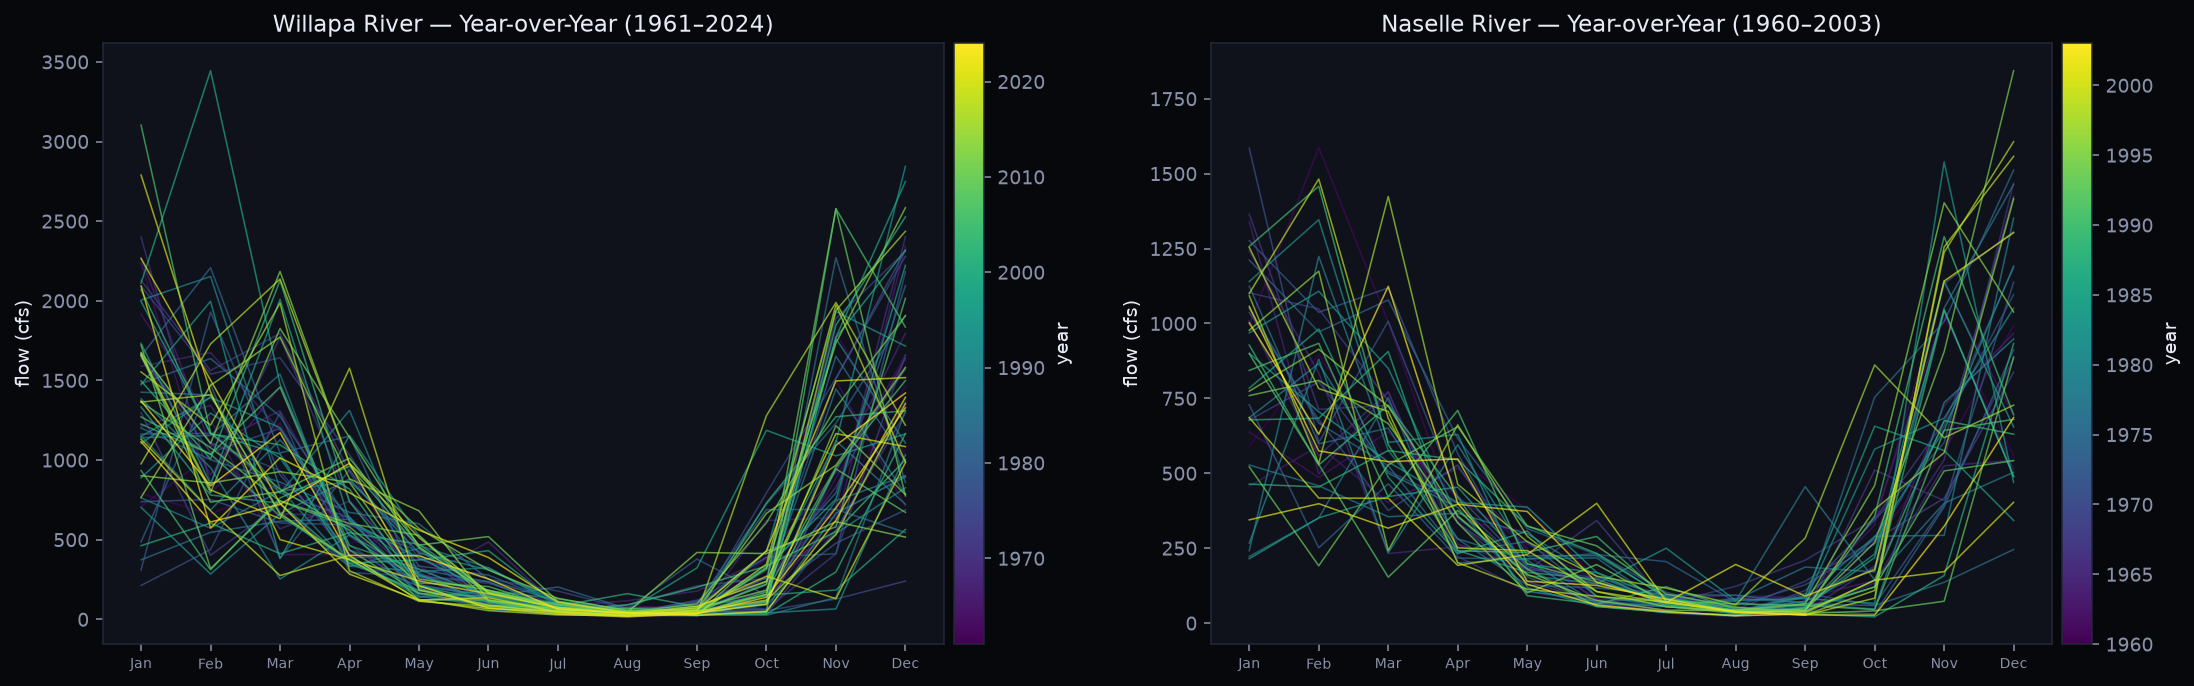

In [4]:
def plot_hydrographs(obs, title, ax):
    years = sorted(obs.keys())
    cmap = plt.get_cmap("viridis")
    span = max(years) - min(years) or 1
    for y in years:
        c = cmap((y - min(years)) / span)
        ax.plot(range(1, 13), obs[y], color=c, lw=0.8, alpha=0.7)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_ABBR, fontsize=7)
    ax.set_ylabel("flow (cfs)")
    ax.set_title(title)
    sm = plt.cm.ScalarMappable(cmap="viridis",
        norm=plt.Normalize(vmin=min(years), vmax=max(years)))
    ax.figure.colorbar(sm, ax=ax, label="year", pad=0.01)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_hydrographs(willapa_obs,
    f"Willapa River — Year-over-Year ({min(willapa_obs.keys())}–{max(willapa_obs.keys())})", axes[0])
plot_hydrographs(naselle_obs,
    f"Naselle River — Year-over-Year ({min(naselle_obs.keys())}–{max(naselle_obs.keys())})", axes[1])
plt.tight_layout()
plt.show()

---
## 3. Typical Year — Mean Monthly Hydrograph + Confidence Band

The average seasonal shape with P10–P90 spread across years.

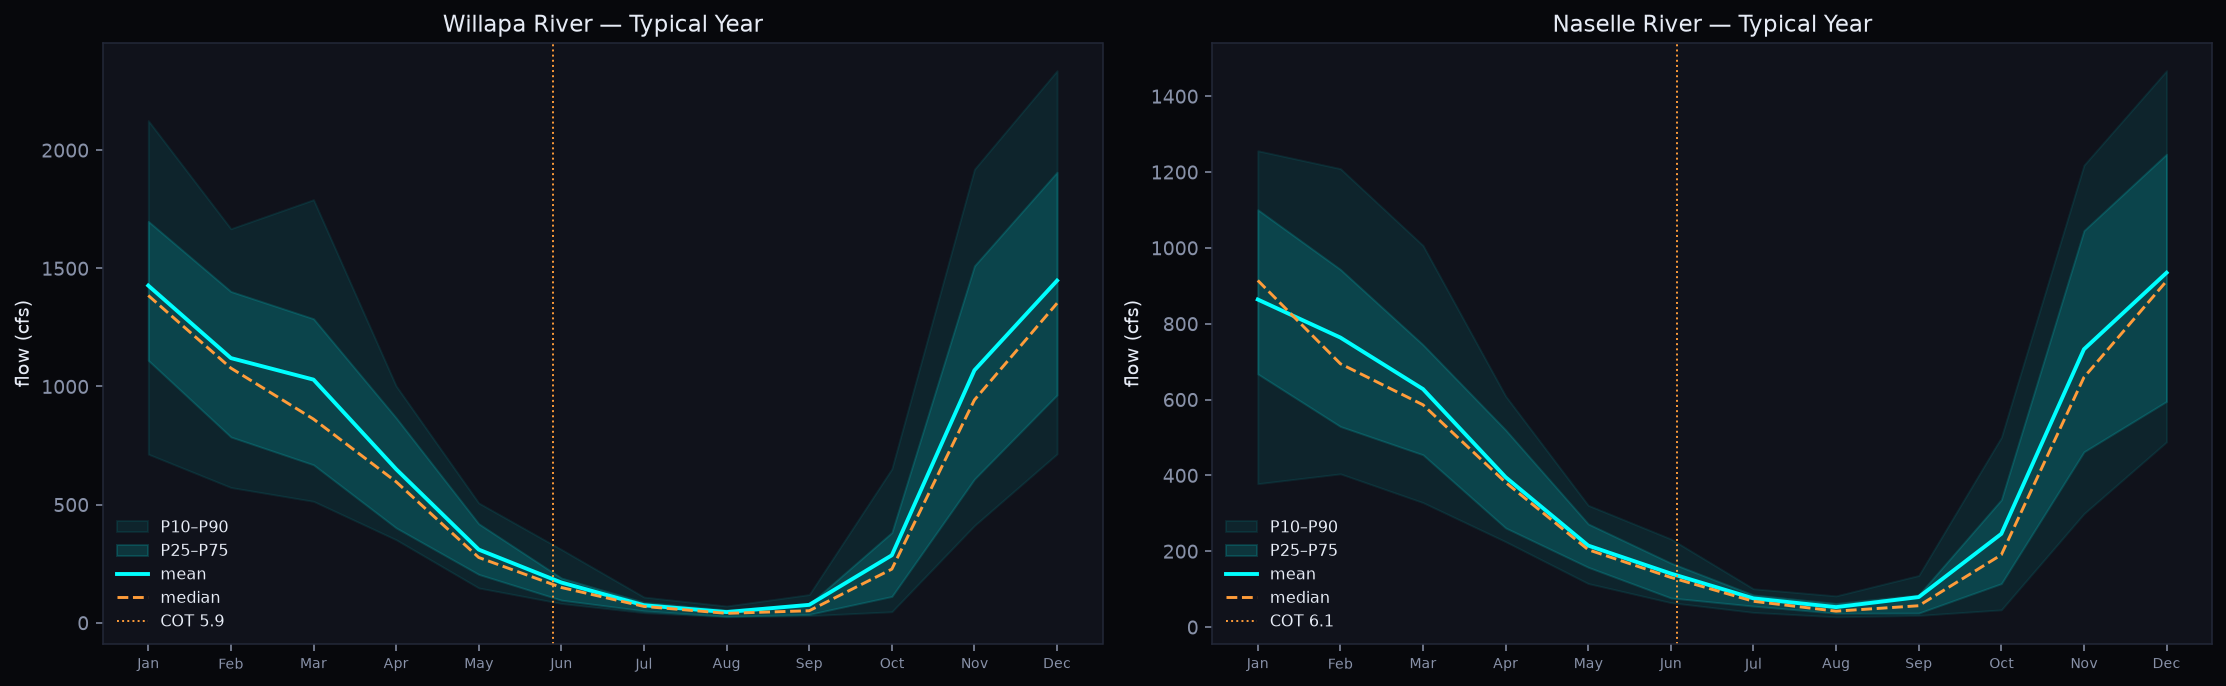

In [5]:
def plot_typical_year(obs, title, ax):
    years = sorted(obs.keys())
    stack = np.array([obs[y] for y in years])
    mean = np.nanmean(stack, axis=0)
    p10 = np.nanpercentile(stack, 10, axis=0)
    p25 = np.nanpercentile(stack, 25, axis=0)
    p75 = np.nanpercentile(stack, 75, axis=0)
    p90 = np.nanpercentile(stack, 90, axis=0)
    m = range(1, 13)
    ax.fill_between(m, p10, p90, color=CYAN, alpha=0.08, label="P10–P90")
    ax.fill_between(m, p25, p75, color=CYAN, alpha=0.15, label="P25–P75")
    ax.plot(m, mean, color=CYAN, lw=2, label="mean")
    ax.plot(m, np.nanmedian(stack, axis=0), color=AMBER, lw=1.5, ls="--", label="median")
    cot = fm.center_of_timing(mean)
    ax.axvline(cot, color=AMBER, ls=":", lw=1, label=f"COT {cot:.1f}")
    ax.set_xticks(list(m))
    ax.set_xticklabels(MONTH_ABBR, fontsize=7)
    ax.set_ylabel("flow (cfs)")
    ax.set_title(title)
    ax.legend(fontsize=8, frameon=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_typical_year(willapa_obs, "Willapa River — Typical Year", axes[0])
plot_typical_year(naselle_obs, "Naselle River — Typical Year", axes[1])
plt.tight_layout()
plt.show()

---
## 4. Long-Record Trend — Annual Mean + Mann-Kendall / Sen's Slope

Is flow increasing or decreasing over the gauge record? Non-parametric
Mann-Kendall trend test with Sen's robust slope estimator.

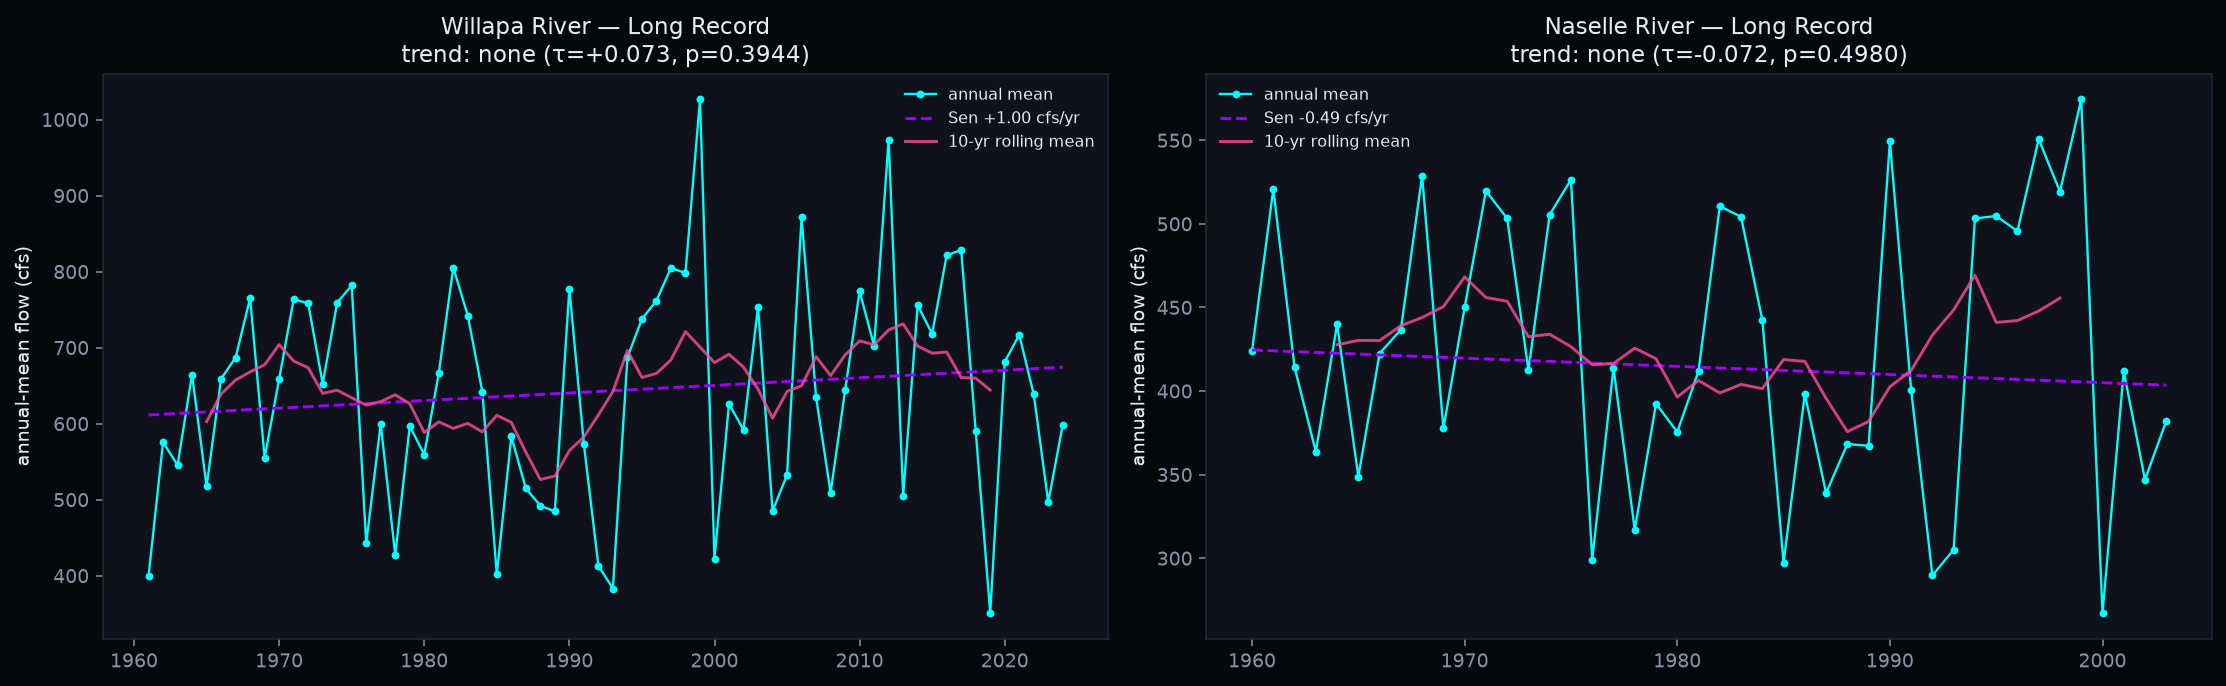

Willapa: {'trend': 'none', 'tau': 0.07341269841269842, 'p': 0.3944014613797751, 'sens_slope': 0.9979097252700401}
Naselle: {'trend': 'none', 'tau': -0.07188160676532769, 'p': 0.497990100720428, 'sens_slope': -0.4888097447345676}


In [6]:
def plot_long_record(obs, title, ax):
    years = sorted(obs.keys())
    annual = np.array([float(np.nanmean(obs[y])) for y in years])
    mk = fm.mann_kendall(annual)
    slope = fm.sens_slope(annual)
    x = np.arange(len(years))
    fit = np.median(annual) + slope * (x - np.median(x))
    ax.plot(years, annual, "o-", color=CYAN, lw=1.2, ms=3, label="annual mean")
    ax.plot(years, fit, "--", color=VIOLET, lw=1.5,
            label=f"Sen {slope:+.2f} cfs/yr")
    # 10-year rolling mean
    if len(annual) >= 10:
        kernel = np.ones(10) / 10
        rolling = np.convolve(annual, kernel, mode="valid")
        ax.plot(years[4:4+len(rolling)], rolling, color=MAGENTA, lw=1.5,
                alpha=0.8, label="10-yr rolling mean")
    ax.set_ylabel("annual-mean flow (cfs)")
    ax.set_title(f"{title}\ntrend: {mk.trend} (τ={mk.tau:+.3f}, p={mk.p:.4f})")
    ax.legend(fontsize=8, frameon=False)
    return {"trend": mk.trend, "tau": mk.tau, "p": mk.p, "sens_slope": slope}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
w_trend = plot_long_record(willapa_obs, "Willapa River — Long Record", axes[0])
n_trend = plot_long_record(naselle_obs, "Naselle River — Long Record", axes[1])
plt.tight_layout()
plt.show()

print(f"Willapa: {w_trend}")
print(f"Naselle: {n_trend}")

---
## 5. Summer Low-Flow Trend

Jun–Aug minimum — the drought-stress signal. Are summers getting drier?

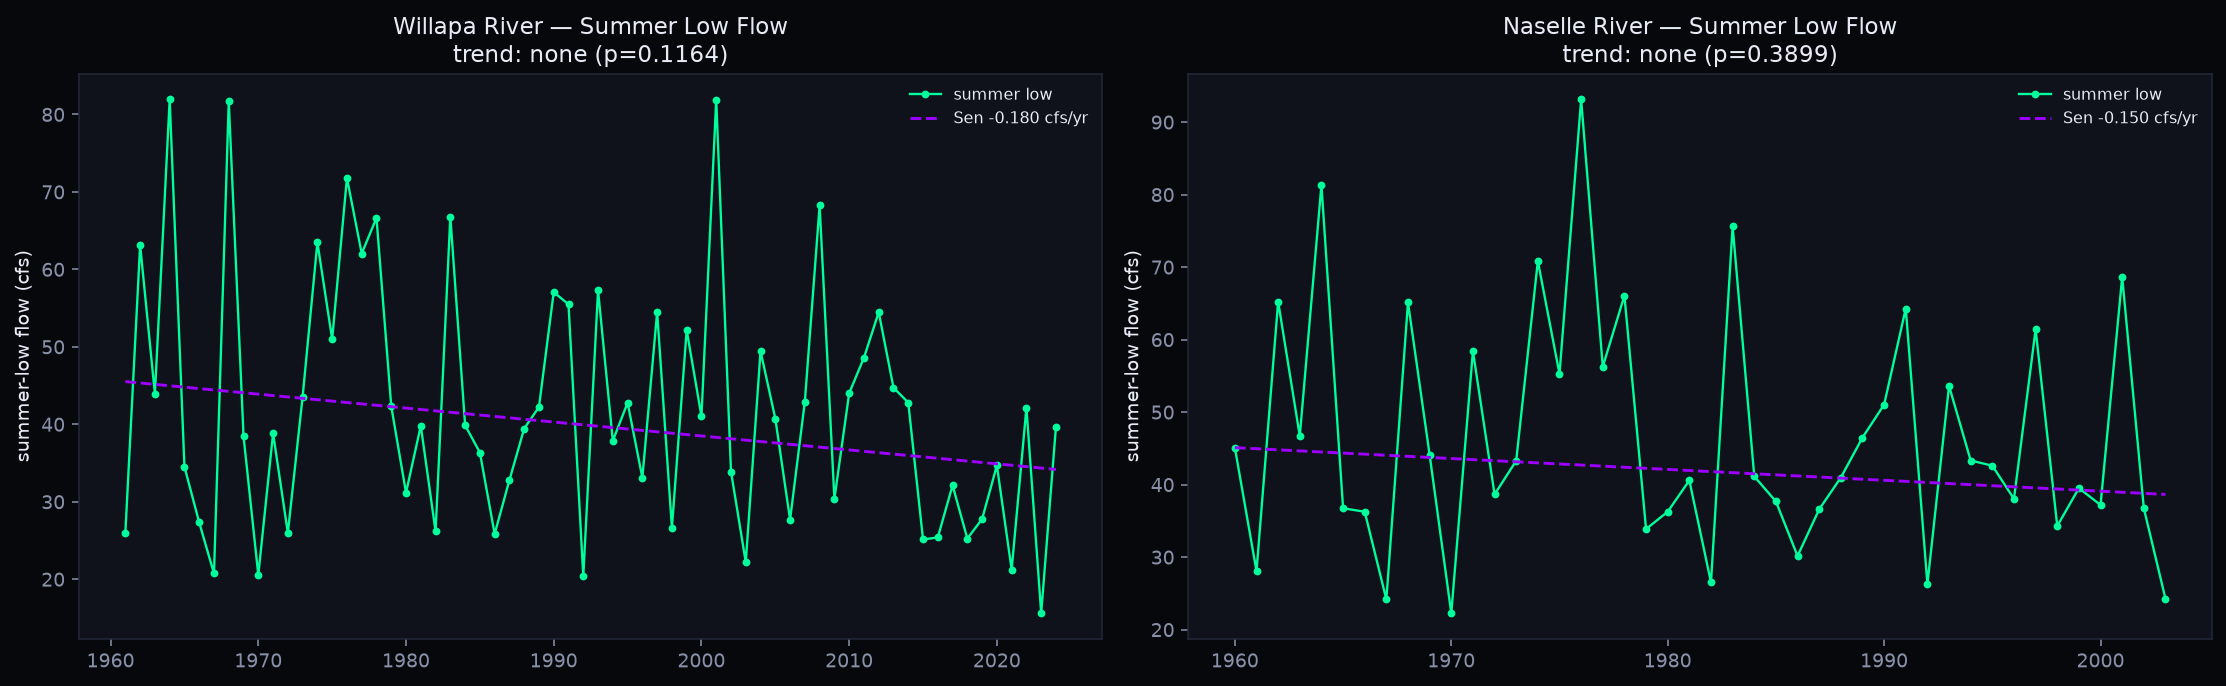

In [7]:
def plot_low_flow(obs, title, ax):
    years = sorted(obs.keys())
    low = np.array([float(np.nanmin(obs[y][5:8])) for y in years])
    slope = fm.sens_slope(low)
    mk = fm.mann_kendall(low)
    x = np.arange(len(years))
    fit = np.median(low) + slope * (x - np.median(x))
    ax.plot(years, low, "o-", color=LIME, lw=1.2, ms=3, label="summer low")
    ax.plot(years, fit, "--", color=VIOLET, lw=1.5,
            label=f"Sen {slope:+.3f} cfs/yr")
    ax.set_ylabel("summer-low flow (cfs)")
    ax.set_title(f"{title}\ntrend: {mk.trend} (p={mk.p:.4f})")
    ax.legend(fontsize=8, frameon=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_low_flow(willapa_obs, "Willapa River — Summer Low Flow", axes[0])
plot_low_flow(naselle_obs, "Naselle River — Summer Low Flow", axes[1])
plt.tight_layout()
plt.show()

---
## 6. Peak Flow Trend

Annual maximum monthly flow — the flood signal.

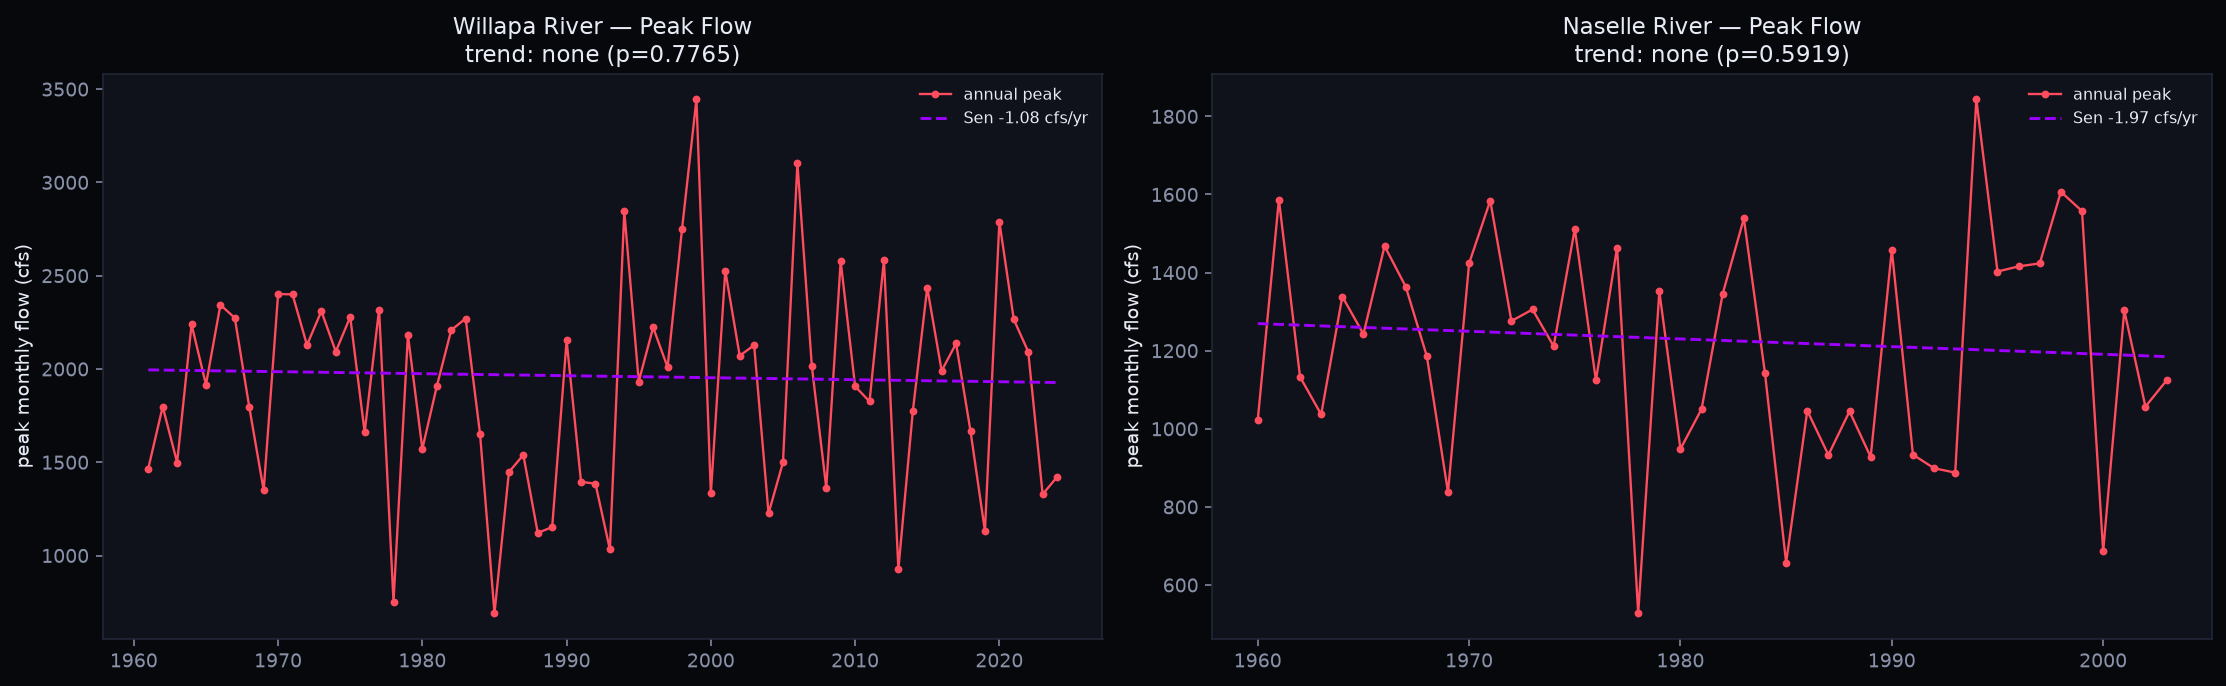

In [8]:
def plot_peak_flow(obs, title, ax):
    years = sorted(obs.keys())
    peak = np.array([float(np.nanmax(obs[y])) for y in years])
    slope = fm.sens_slope(peak)
    mk = fm.mann_kendall(peak)
    x = np.arange(len(years))
    fit = np.median(peak) + slope * (x - np.median(x))
    ax.plot(years, peak, "o-", color=RED, lw=1.2, ms=3, label="annual peak")
    ax.plot(years, fit, "--", color=VIOLET, lw=1.5,
            label=f"Sen {slope:+.2f} cfs/yr")
    ax.set_ylabel("peak monthly flow (cfs)")
    ax.set_title(f"{title}\ntrend: {mk.trend} (p={mk.p:.4f})")
    ax.legend(fontsize=8, frameon=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_peak_flow(willapa_obs, "Willapa River — Peak Flow", axes[0])
plot_peak_flow(naselle_obs, "Naselle River — Peak Flow", axes[1])
plt.tight_layout()
plt.show()

---
## 7. Timing Drift — Center of Timing per Year

Is the hydrograph's mass shifting earlier in the year? The center-of-timing
trend detects snowmelt-dominated rivers arriving earlier under warming, or
rain-dominated rivers shifting with changing storm patterns.

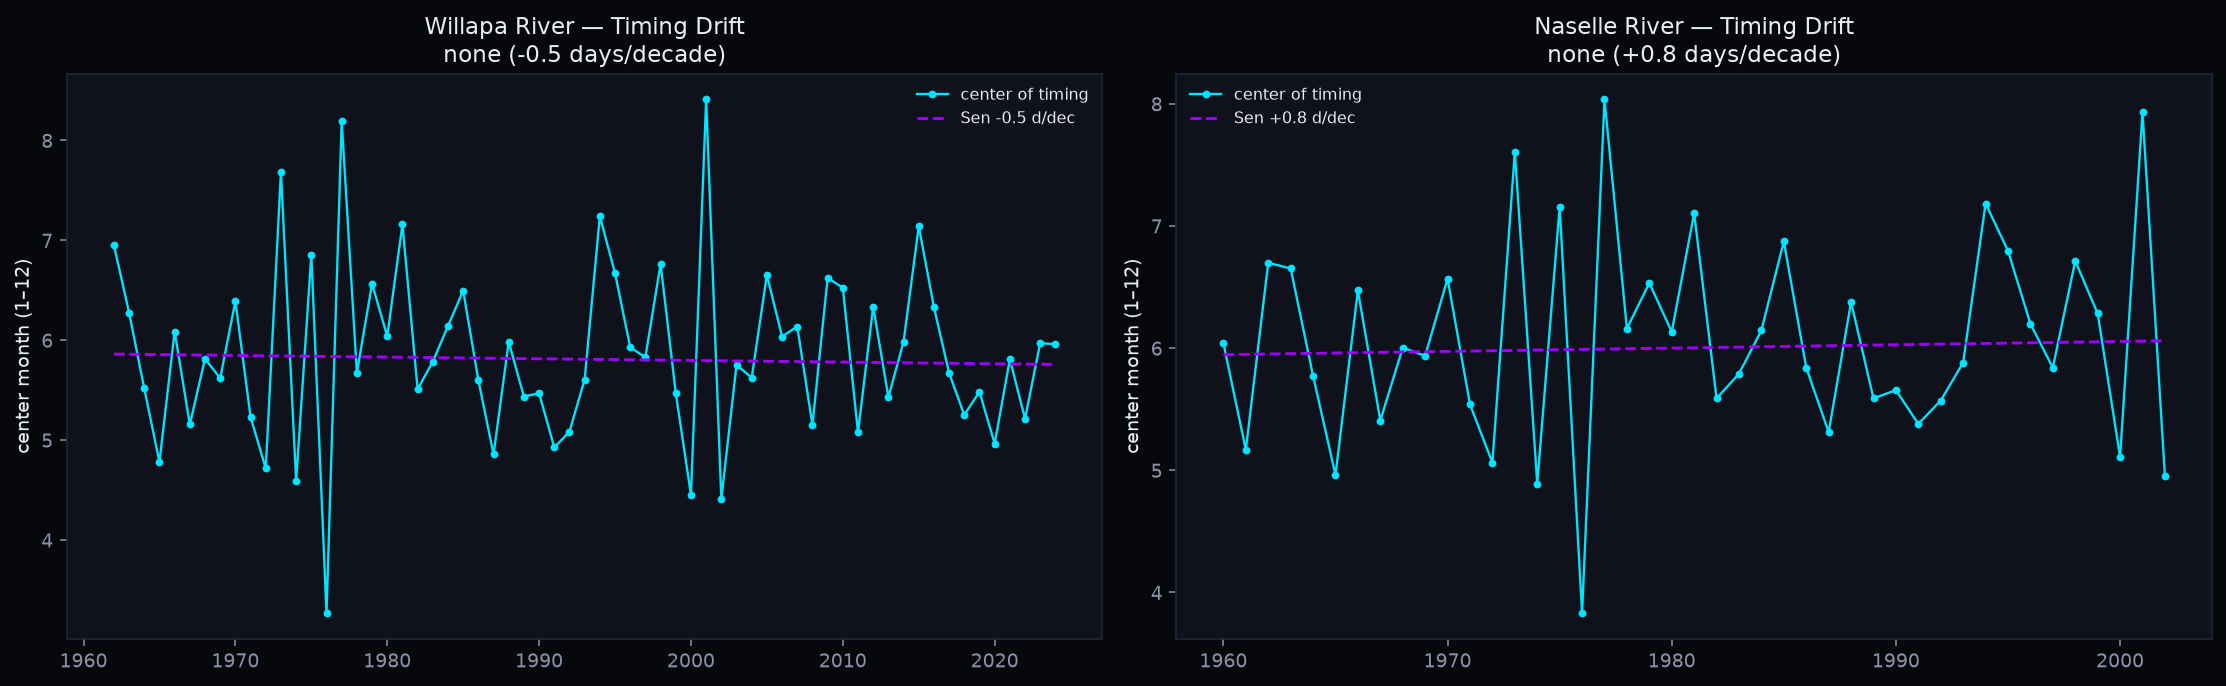

Willapa: -0.5 days/decade (none)
Naselle: +0.8 days/decade (none)


In [9]:
def plot_timing_drift(obs, title, ax):
    clean = complete_years(obs)
    tt = fm.center_of_timing_trend(clean)
    years = list(tt.years)
    centers = np.array(tt.center_months)
    ax.plot(years, centers, "o-", color=COOL_BLUE, lw=1.2, ms=3, label="center of timing")
    x = np.arange(len(years))
    fit = np.median(centers) + tt.slope_months_per_year * (x - np.median(x))
    ax.plot(years, fit, "--", color=VIOLET, lw=1.5,
            label=f"Sen {tt.days_per_decade:+.1f} d/dec")
    ax.set_ylabel("center month (1–12)")
    ax.set_title(f"{title}\n{tt.trend} ({tt.days_per_decade:+.1f} days/decade)")
    ax.legend(fontsize=8, frameon=False)
    return tt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
w_tt = plot_timing_drift(willapa_obs, "Willapa River — Timing Drift", axes[0])
n_tt = plot_timing_drift(naselle_obs, "Naselle River — Timing Drift", axes[1])
plt.tight_layout()
plt.show()

print(f"Willapa: {w_tt.days_per_decade:+.1f} days/decade ({w_tt.trend})")
print(f"Naselle: {n_tt.days_per_decade:+.1f} days/decade ({n_tt.trend})")

---
## 8. ENSO Teleconnection — Peak Flow vs. ONI

Pacific County sits in the Pacific Northwest — El Niño typically brings
warmer/drier winters, La Niña cooler/wetter. Does peak flow correlate?

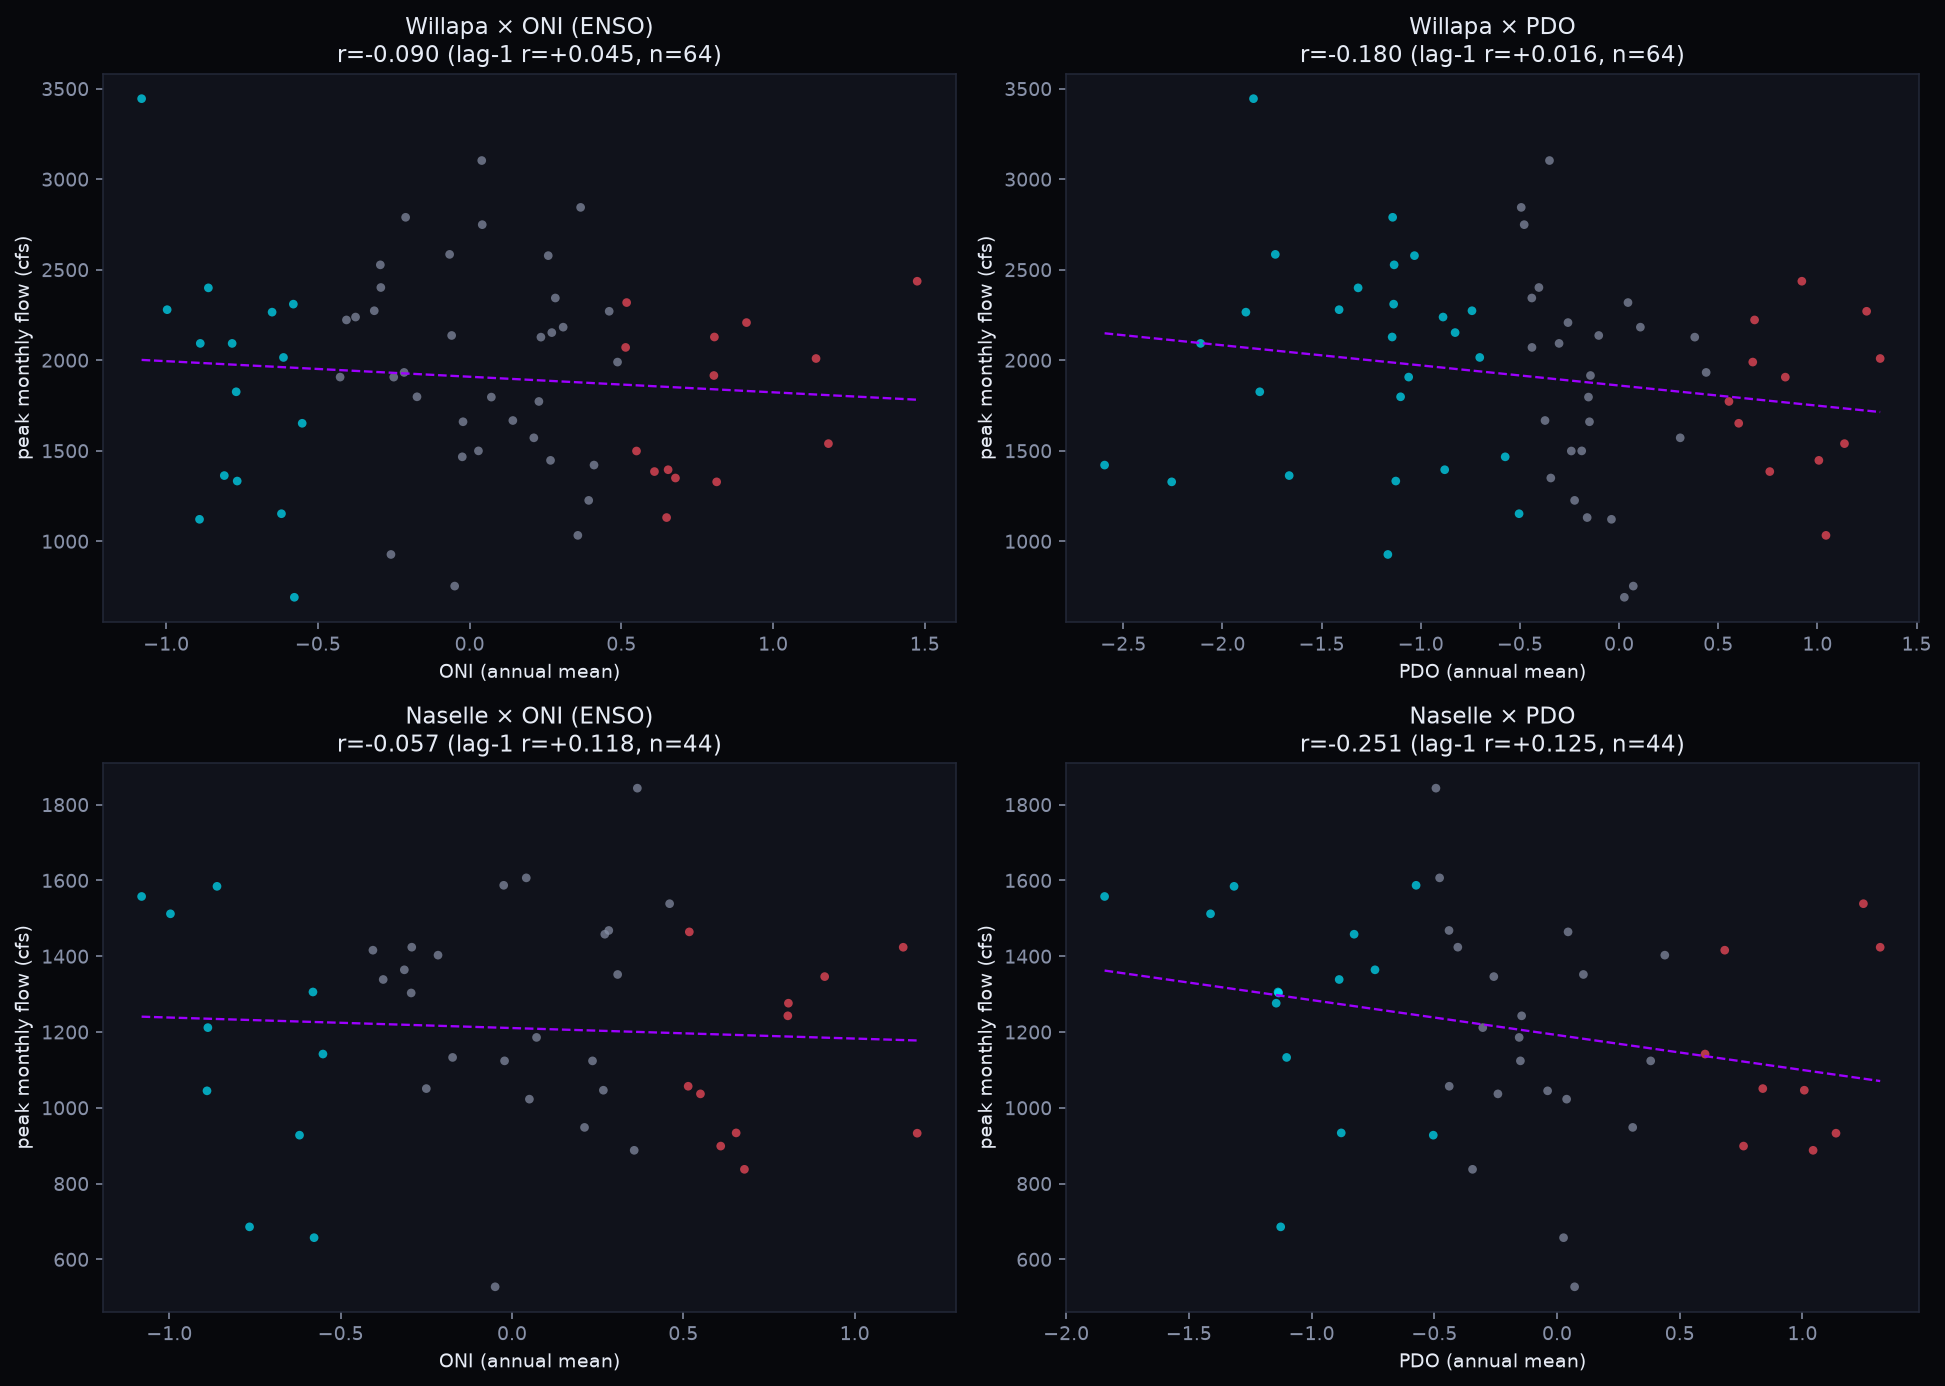

In [10]:
def plot_enso(obs, index_by_year, title, ax, *, index_name="ONI"):
    years = sorted(obs.keys())
    peak_by_year = {y: float(np.nanmax(obs[y])) for y in years}
    try:
        metric, index = fm.align_index(peak_by_year, index_by_year)
    except fm.FlowValidationError:
        ax.text(0.5, 0.5, "no overlap", ha="center", transform=ax.transAxes)
        return {}
    r0 = fm.correlate(peak_by_year, index_by_year)
    r1 = fm.correlate(peak_by_year, index_by_year, lag=1)
    # color by phase
    colors = [RED if v >= 0.5 else COOL_BLUE if v <= -0.5 else MUTED for v in index]
    ax.scatter(index, metric, s=20, c=colors, alpha=0.7, edgecolors="none")
    # trendline
    z = np.polyfit(index, metric, 1)
    xfit = np.linspace(index.min(), index.max(), 50)
    ax.plot(xfit, np.polyval(z, xfit), "--", color=VIOLET, lw=1.2)
    ax.set_xlabel(f"{index_name} (annual mean)")
    ax.set_ylabel("peak monthly flow (cfs)")
    ax.set_title(f"{title}\nr={r0:+.3f} (lag-1 r={r1:+.3f}, n={len(metric)})")
    return {"r": r0, "r_lag1": r1}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_enso(willapa_obs, oni, "Willapa × ONI (ENSO)", axes[0, 0], index_name="ONI")
plot_enso(willapa_obs, pdo, "Willapa × PDO", axes[0, 1], index_name="PDO")
plot_enso(naselle_obs, oni, "Naselle × ONI (ENSO)", axes[1, 0], index_name="ONI")
plot_enso(naselle_obs, pdo, "Naselle × PDO", axes[1, 1], index_name="PDO")
plt.tight_layout()
plt.show()

---
## 9. ENSO Composite Hydrographs

Average seasonal shape for warm (El Niño), neutral, and cool (La Niña) years.
Shows how ENSO modulates the entire hydrograph, not just peak flow.

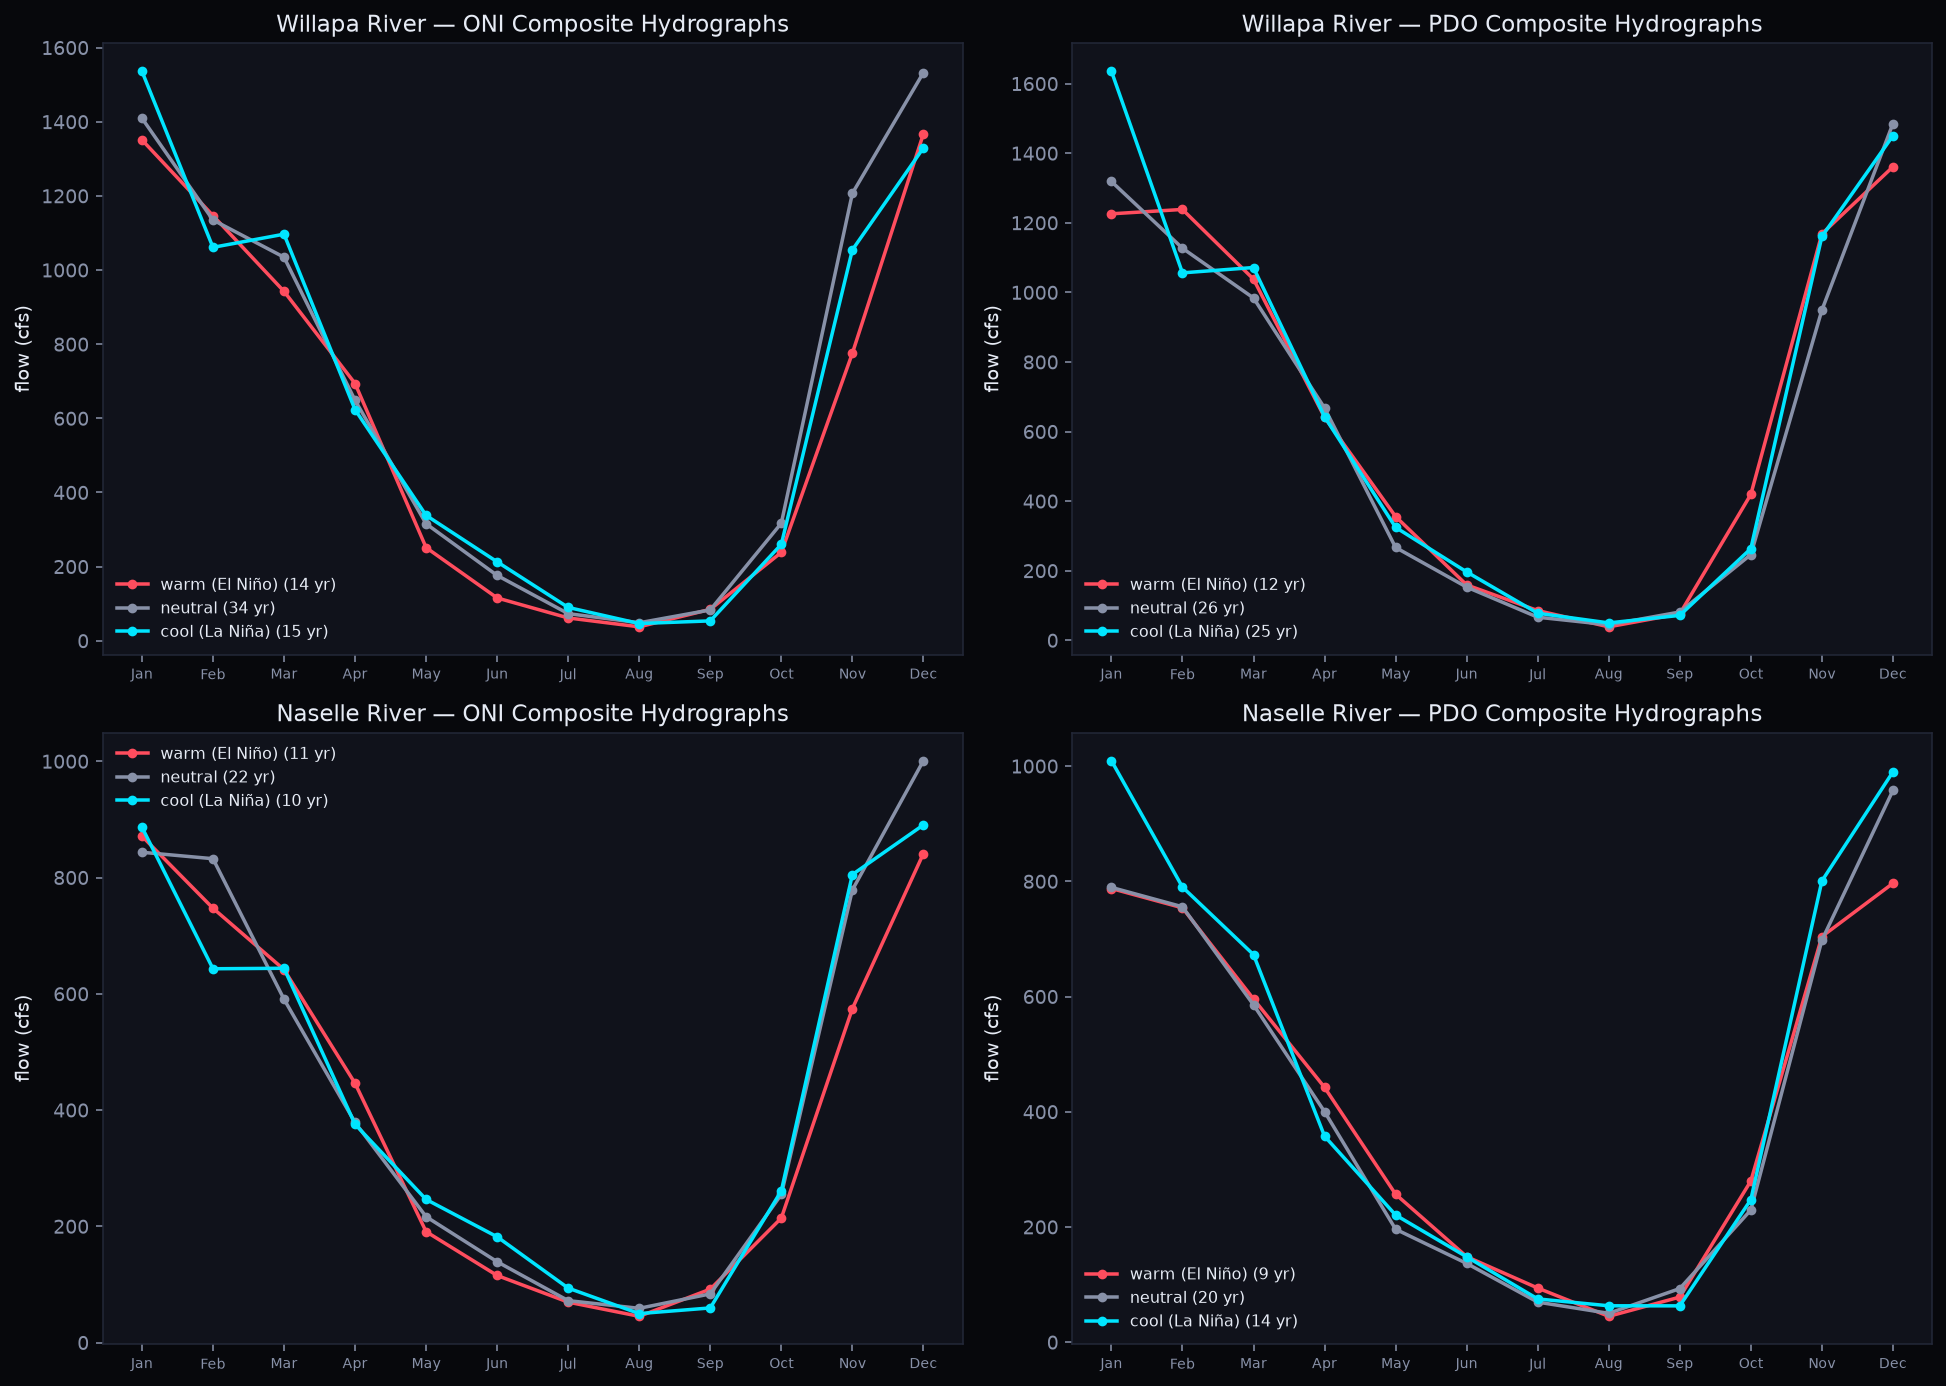

In [11]:
def plot_composites(obs, index_by_year, title, ax, *, index_name="ONI"):
    clean = complete_years(obs)
    pc = fm.composite_hydrographs(clean, index_by_year)
    m = range(1, 13)
    for label, vec, color in (("warm (El Niño)", pc.warm, RED),
                               ("neutral", pc.neutral, MUTED),
                               ("cool (La Niña)", pc.cool, COOL_BLUE)):
        if vec is not None:
            n_yrs = len(getattr(pc, label.split()[0] + "_years"))
            ax.plot(m, vec, "-o", ms=4, lw=1.8, color=color,
                    label=f"{label} ({n_yrs} yr)")
    ax.set_xticks(list(m))
    ax.set_xticklabels(MONTH_ABBR, fontsize=7)
    ax.set_ylabel("flow (cfs)")
    ax.set_title(f"{title} — {index_name} Composite Hydrographs")
    ax.legend(fontsize=8, frameon=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_composites(willapa_obs, oni, "Willapa River", axes[0, 0], index_name="ONI")
plot_composites(willapa_obs, pdo, "Willapa River", axes[0, 1], index_name="PDO")
plot_composites(naselle_obs, oni, "Naselle River", axes[1, 0], index_name="ONI")
plot_composites(naselle_obs, pdo, "Naselle River", axes[1, 1], index_name="PDO")
plt.tight_layout()
plt.show()

---
## 10. Flow-Duration Curves by Decade

How has the entire flow *distribution* shifted over time? Each curve shows
the percentage of time a flow level is equaled or exceeded within that decade.

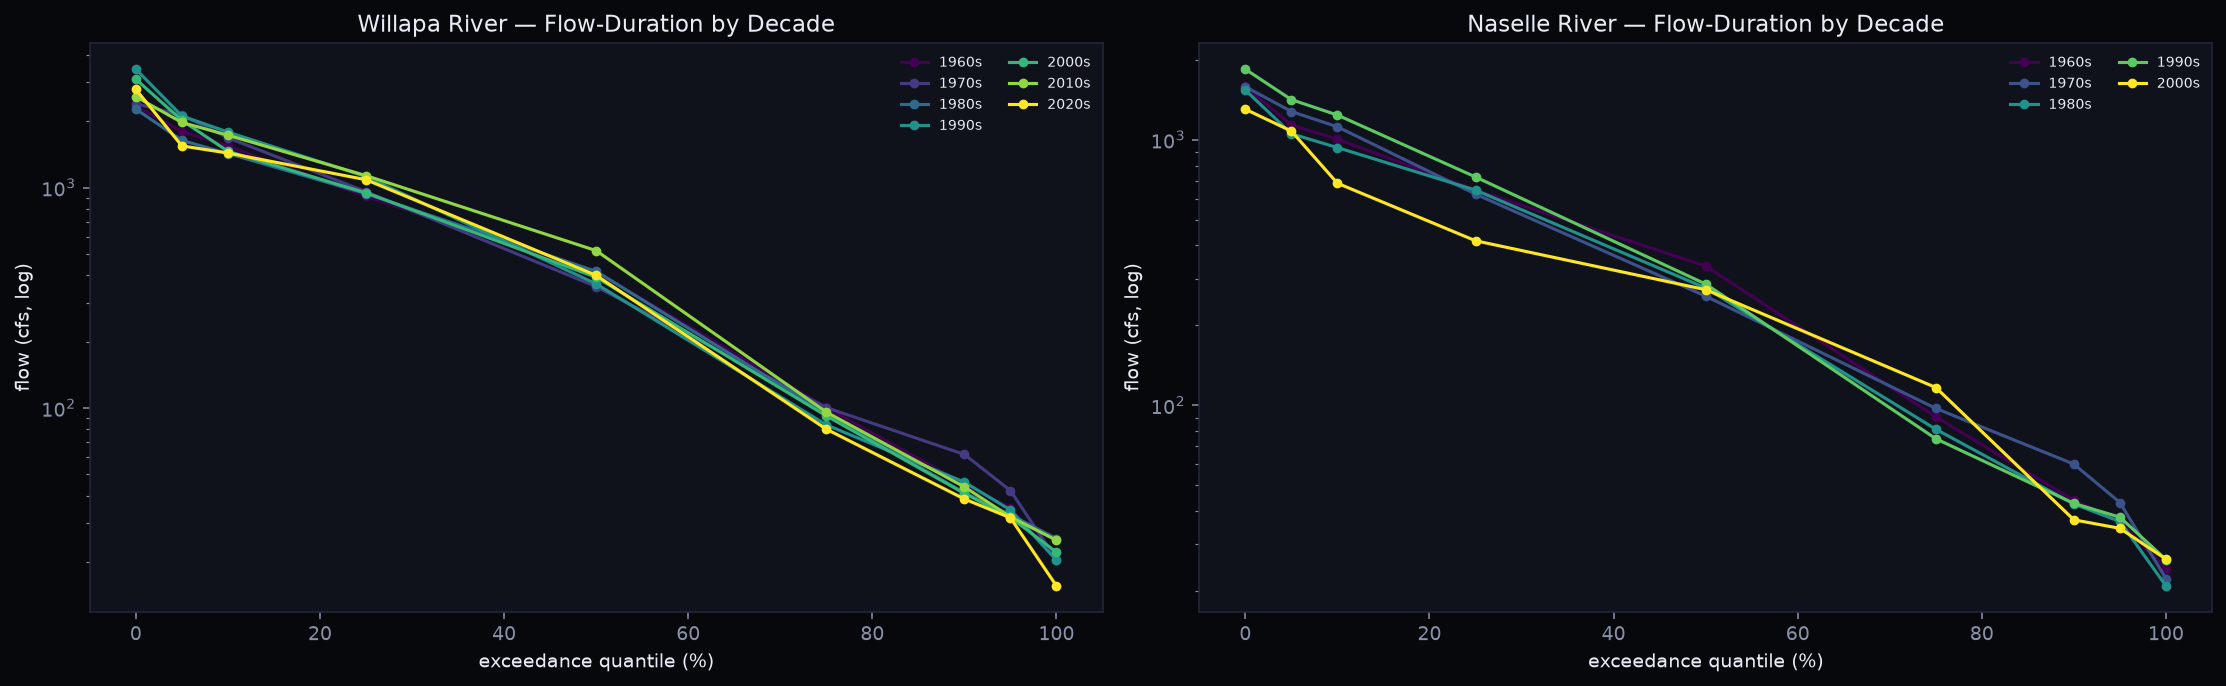

In [12]:
def plot_decade_fdc(obs, title, ax):
    clean = complete_years(obs)
    quantiles = [0, 5, 10, 25, 50, 75, 90, 95, 100]
    decades = fm.decade_flow_duration(clean, quantiles)
    cmap = plt.get_cmap("viridis")
    span = max(1, len(decades) - 1)
    for i, d in enumerate(decades):
        ax.plot(d.quantiles, np.clip(d.flows, 1e-2, None), "-o", ms=4,
                color=cmap(i / span), lw=1.6, label=f"{d.decade}s")
    ax.set_yscale("log")
    ax.set_xlabel("exceedance quantile (%)")
    ax.set_ylabel("flow (cfs, log)")
    ax.set_title(title)
    ax.legend(fontsize=7, frameon=False, ncol=2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_decade_fdc(willapa_obs, "Willapa River — Flow-Duration by Decade", axes[0])
plot_decade_fdc(naselle_obs, "Naselle River — Flow-Duration by Decade", axes[1])
plt.tight_layout()
plt.show()

---
## 11. Analog Years — Most Similar Historical Shapes

Which historical years had the most similar seasonal shape to the most
recent year? Ranked by Pearson correlation of the 12-month vectors
(removes mean/scale — focuses on shape).

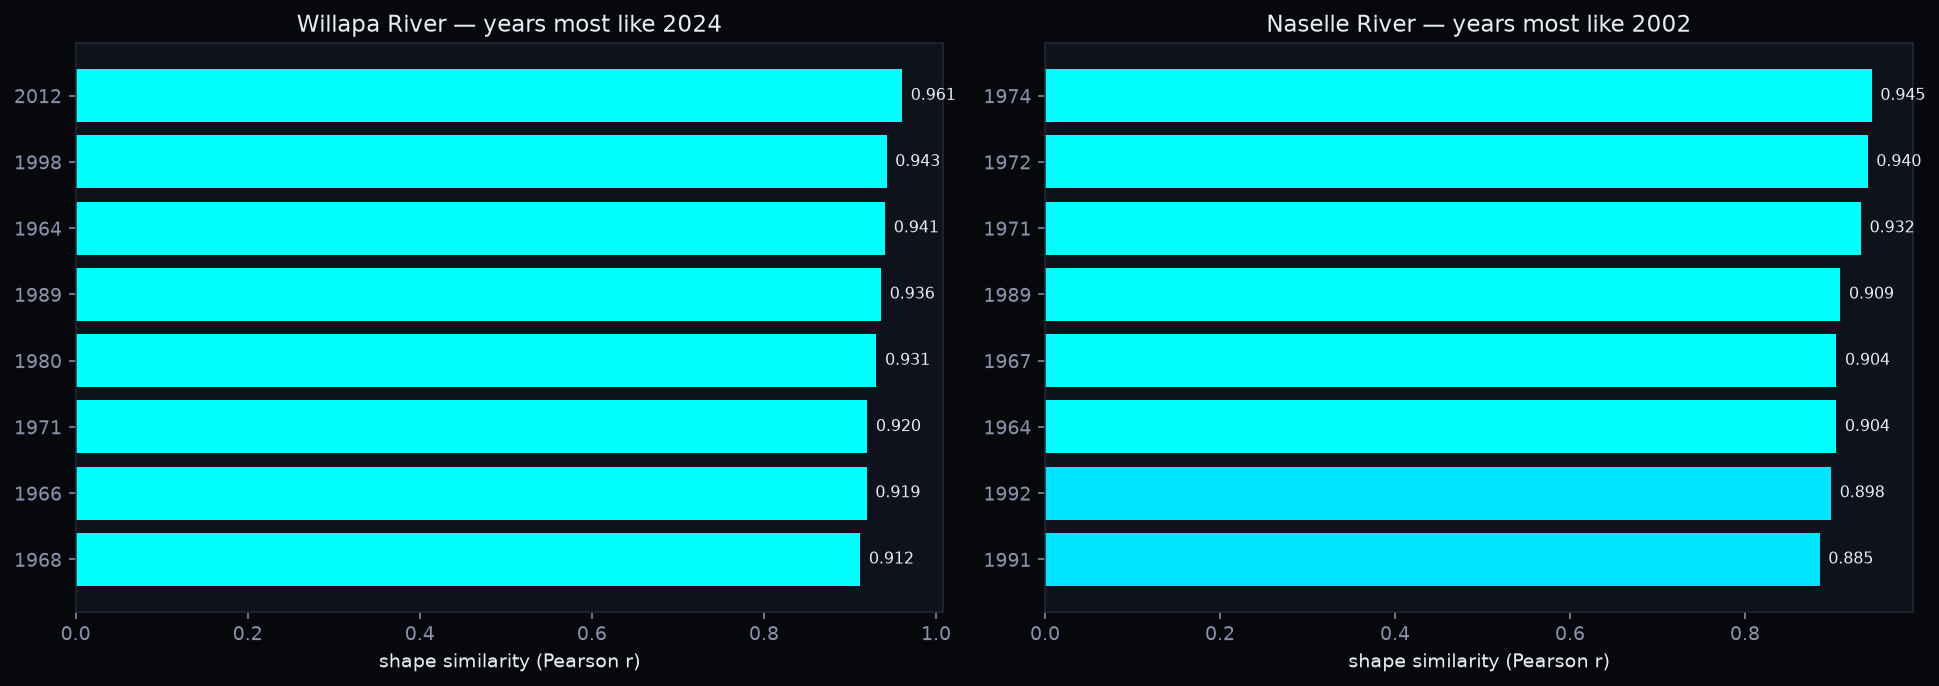

In [13]:
def plot_analog_years(obs, title, ax, *, n=8):
    clean = complete_years(obs)
    target = max(clean.keys())
    analogs = fm.analog_years(clean, target, n=n)
    labels = [str(a.year) for a in analogs]
    sims = [a.similarity for a in analogs]
    colors = [CYAN if s > 0.9 else COOL_BLUE if s > 0.7 else MUTED for s in sims]
    bars = ax.barh(labels, sims, color=colors)
    ax.invert_yaxis()
    ax.set_xlabel("shape similarity (Pearson r)")
    ax.set_title(f"{title} — years most like {target}")
    for bar, s in zip(bars, sims):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f"{s:.3f}", va="center", fontsize=8, color=LIGHT)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_analog_years(willapa_obs, "Willapa River", axes[0])
plot_analog_years(naselle_obs, "Naselle River", axes[1])
plt.tight_layout()
plt.show()

---
## 12. Drought / Flood Record Book

Top-5 driest summers and wettest years in the entire gauge record.

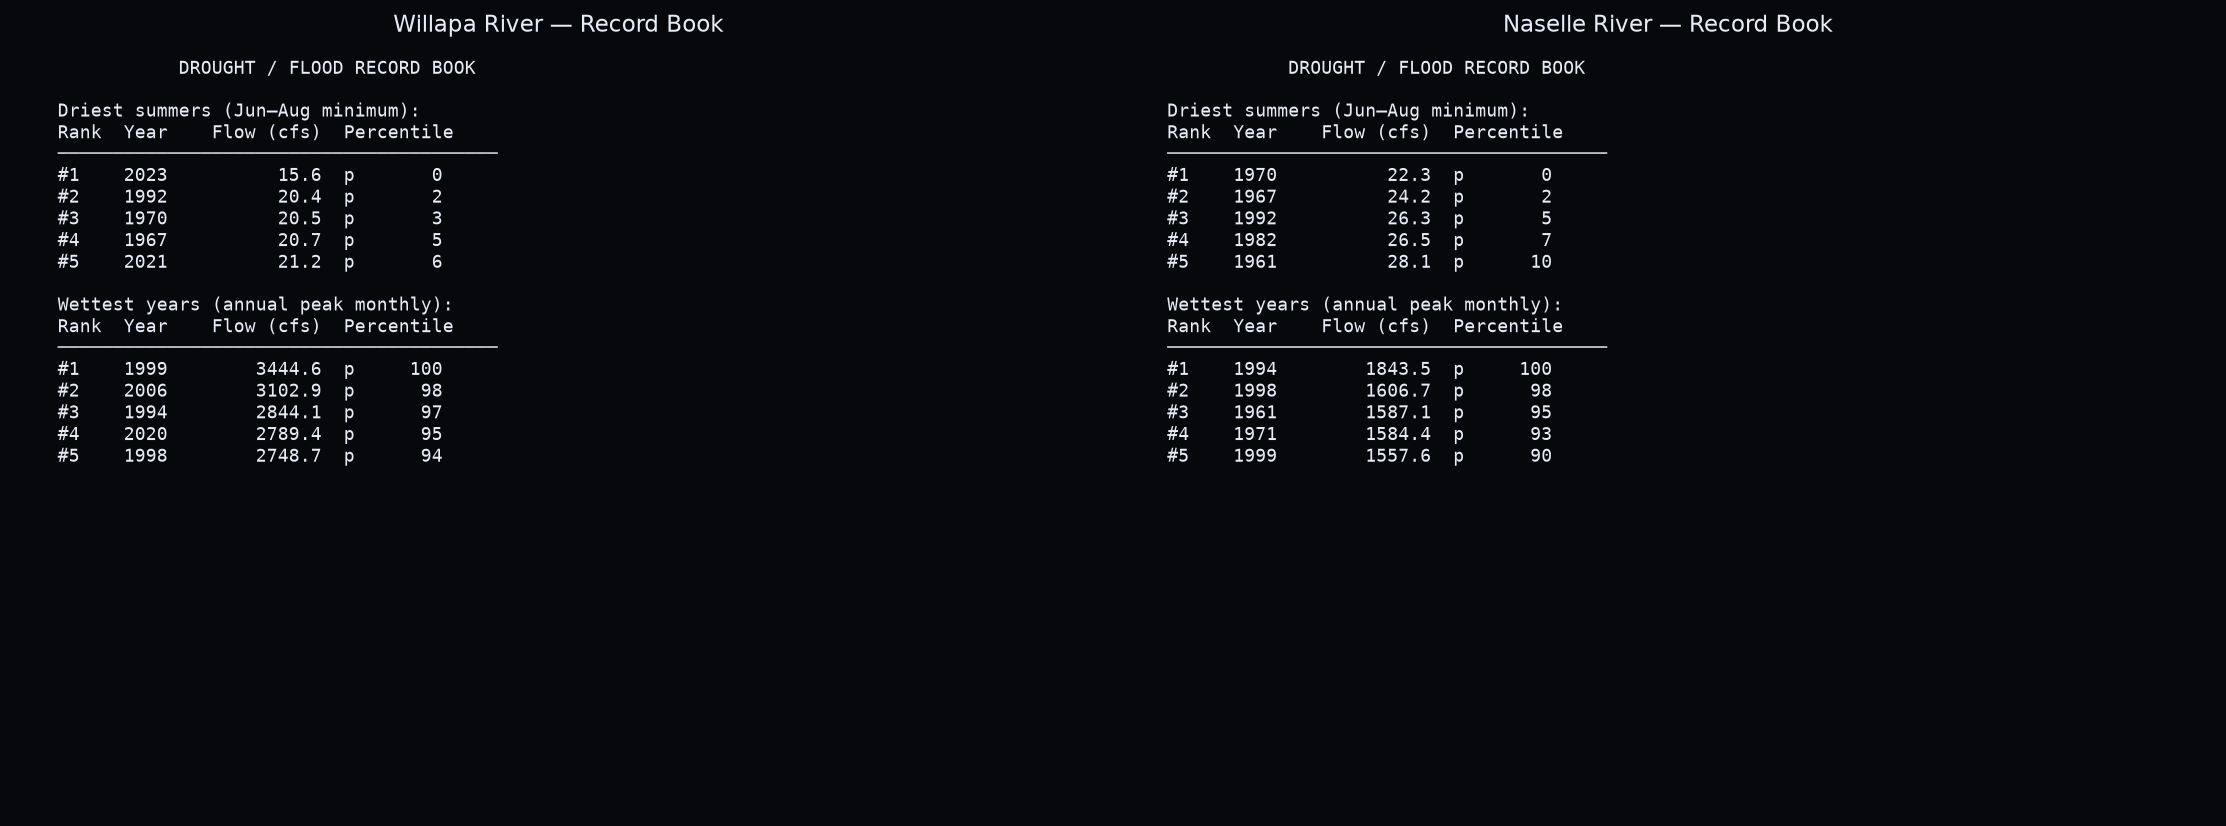

In [14]:
def plot_record_book(obs, title, ax):
    clean = complete_years(obs)
    rb = fm.record_book(clean, n=5)
    lines = [f"  {'DROUGHT / FLOOD RECORD BOOK':^50}", ""]
    lines.append("  Driest summers (Jun–Aug minimum):")
    lines.append(f"  {'Rank':>4}  {'Year':>4}  {'Flow (cfs)':>12}  {'Percentile':>10}")
    lines.append("  " + "─" * 40)
    for e in rb.driest_summers:
        lines.append(f"  #{e.rank:<3}  {e.year}  {e.value:>12.1f}  p{e.percentile*100:>8.0f}")
    lines += ["", "  Wettest years (annual peak monthly):"]
    lines.append(f"  {'Rank':>4}  {'Year':>4}  {'Flow (cfs)':>12}  {'Percentile':>10}")
    lines.append("  " + "─" * 40)
    for e in rb.wettest_years:
        lines.append(f"  #{e.rank:<3}  {e.year}  {e.value:>12.1f}  p{e.percentile*100:>8.0f}")
    ax.text(0.02, 0.98, "\n".join(lines), transform=ax.transAxes, va="top", ha="left",
            family="monospace", fontsize=9, color=LIGHT)
    ax.set_axis_off()
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_record_book(willapa_obs, "Willapa River — Record Book", axes[0])
plot_record_book(naselle_obs, "Naselle River — Record Book", axes[1])
plt.tight_layout()
plt.show()

---
## 13. Seasonal Ratio — Wet/Dry Season Balance

Ratio of wet-season (Nov–Apr) mean flow to dry-season (May–Oct) mean flow.
A higher ratio means a more seasonally concentrated flow regime.

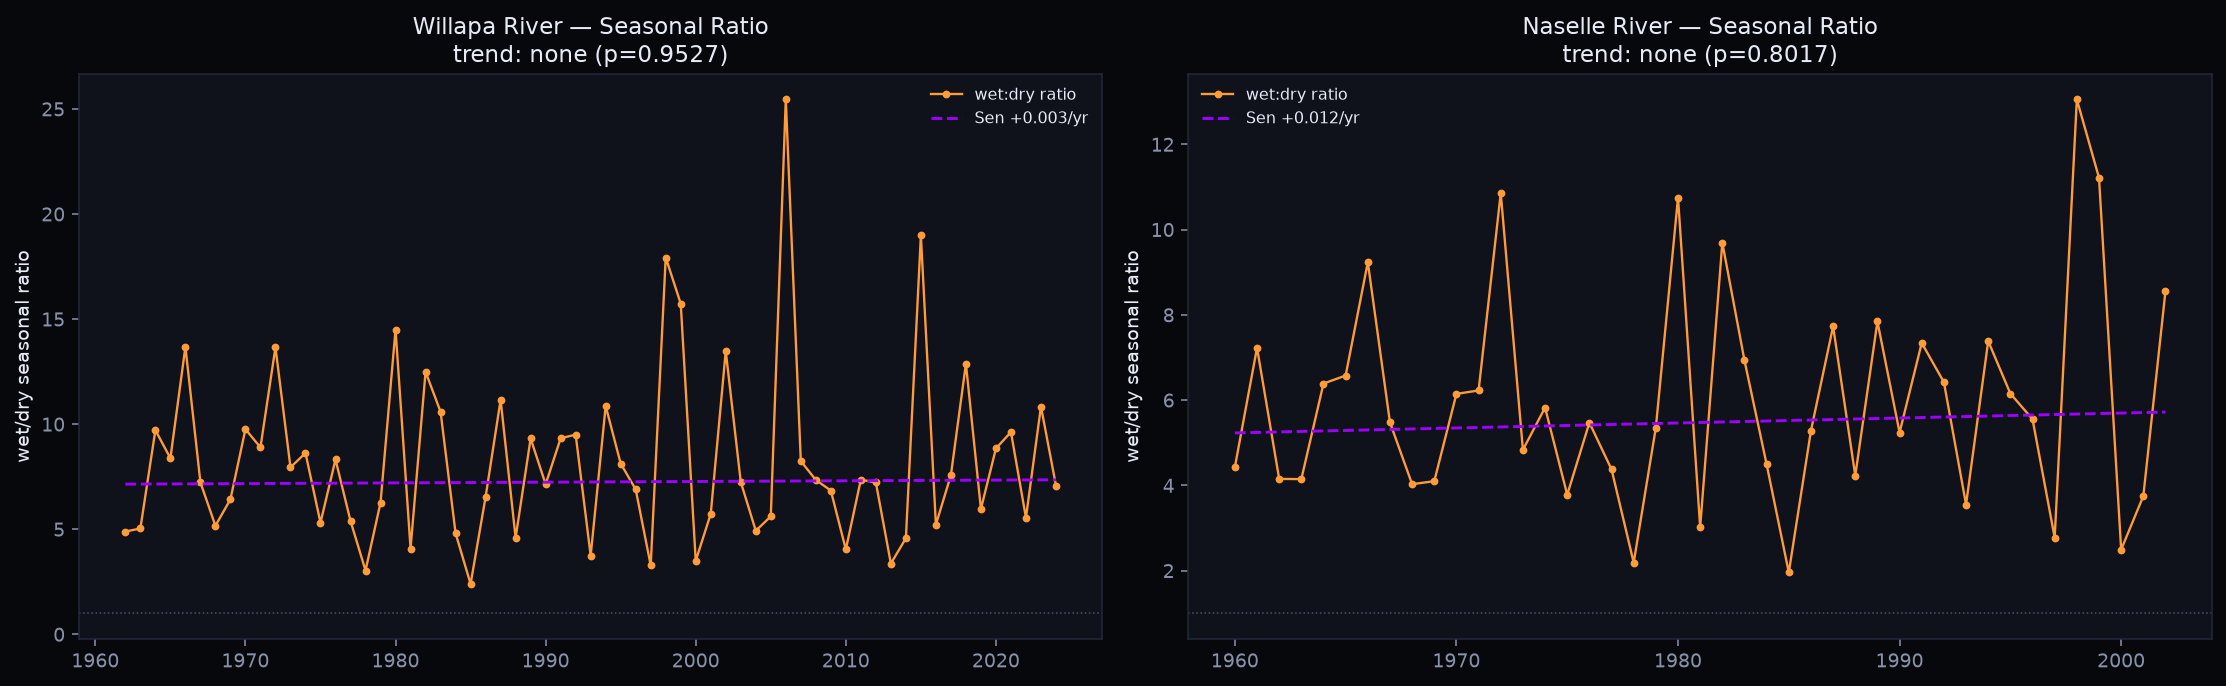

In [15]:
def plot_seasonal_ratio(obs, title, ax):
    clean = complete_years(obs)
    years = sorted(clean.keys())
    ratios = [fm.seasonal_ratio(clean[y]) for y in years]
    mk = fm.mann_kendall(ratios)
    slope = fm.sens_slope(ratios)
    x = np.arange(len(years))
    fit = np.median(ratios) + slope * (x - np.median(x))
    ax.plot(years, ratios, "o-", color=AMBER, lw=1.2, ms=3, label="wet:dry ratio")
    ax.plot(years, fit, "--", color=VIOLET, lw=1.5,
            label=f"Sen {slope:+.3f}/yr")
    ax.axhline(1.0, color=MUTED, ls=":", lw=0.8, alpha=0.5)
    ax.set_ylabel("wet/dry seasonal ratio")
    ax.set_title(f"{title}\ntrend: {mk.trend} (p={mk.p:.4f})")
    ax.legend(fontsize=8, frameon=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_seasonal_ratio(willapa_obs, "Willapa River — Seasonal Ratio", axes[0])
plot_seasonal_ratio(naselle_obs, "Naselle River — Seasonal Ratio", axes[1])
plt.tight_layout()
plt.show()

---
## 14. Flashiness Index — Richards-Baker Variability

How "spiky" is each year's hydrograph? Higher flashiness = more extreme
month-to-month swings, characteristic of rain-dominated coastal basins.

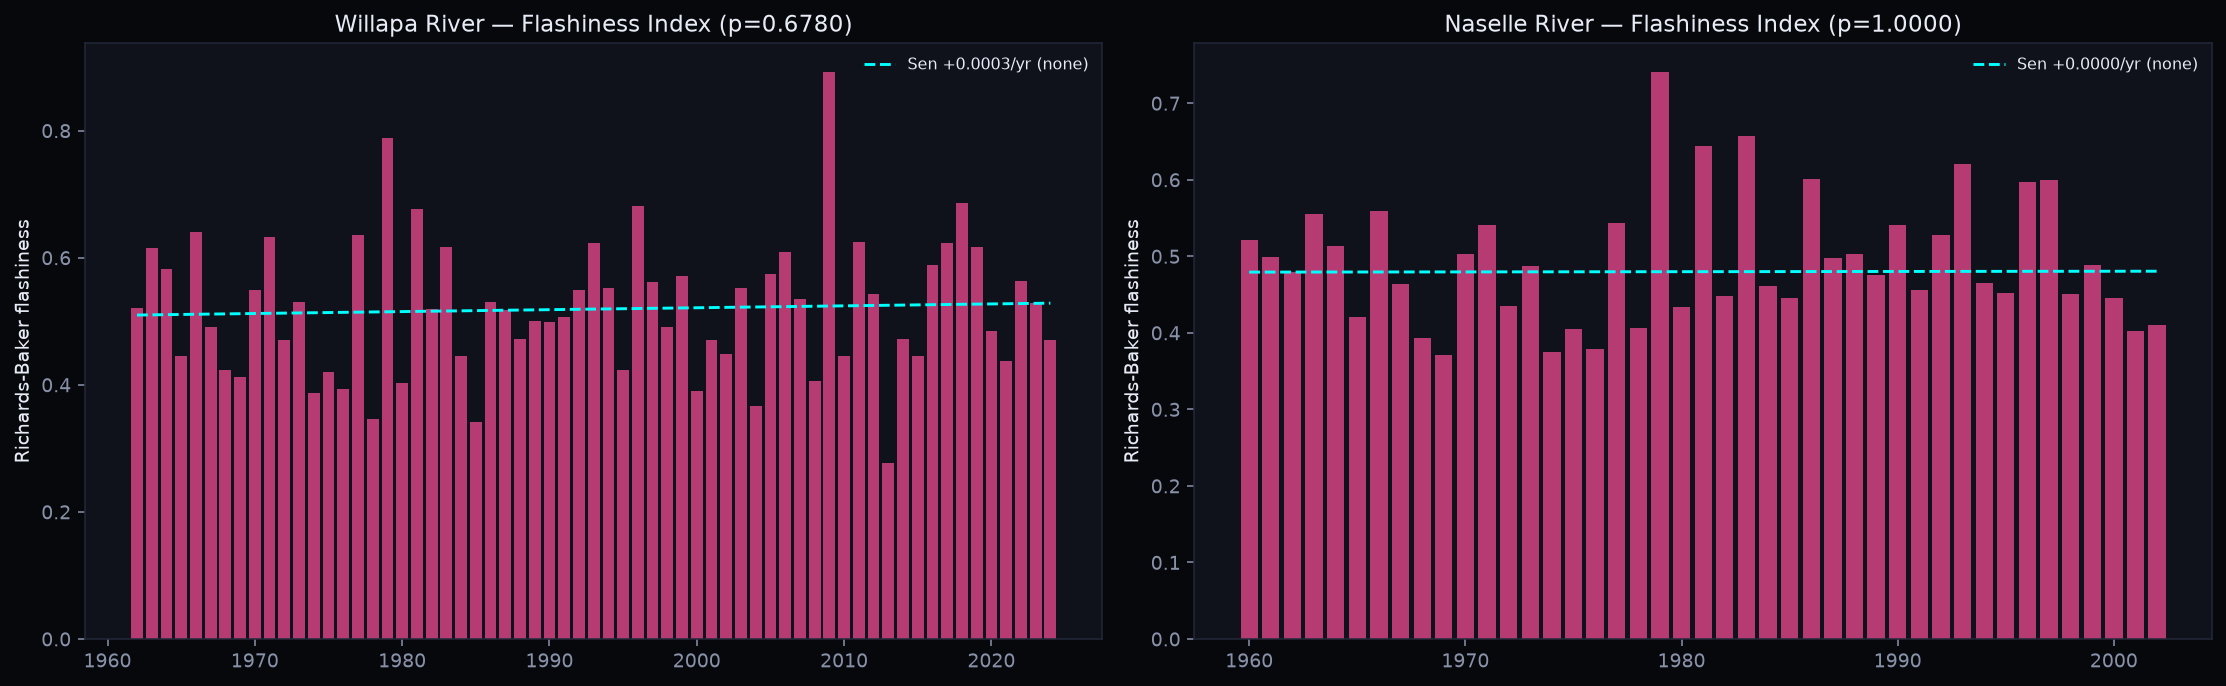

In [16]:
def plot_flashiness(obs, title, ax):
    clean = complete_years(obs)
    years = sorted(clean.keys())
    flash = [fm.flashiness(clean[y]) for y in years]
    mk = fm.mann_kendall(flash)
    slope = fm.sens_slope(flash)
    x = np.arange(len(years))
    fit = np.median(flash) + slope * (x - np.median(x))
    ax.bar(years, flash, color=MAGENTA, alpha=0.7, width=0.8)
    ax.plot(years, fit, "--", color=CYAN, lw=1.5,
            label=f"Sen {slope:+.4f}/yr ({mk.trend})")
    ax.set_ylabel("Richards-Baker flashiness")
    ax.set_title(f"{title} (p={mk.p:.4f})")
    ax.legend(fontsize=8, frameon=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_flashiness(willapa_obs, "Willapa River — Flashiness Index", axes[0])
plot_flashiness(naselle_obs, "Naselle River — Flashiness Index", axes[1])
plt.tight_layout()
plt.show()

---
## 15. Rolling 30-Year Climate Normals

Sliding 30-year mean of annual flow — shows the slow multi-decadal
climate signal distinct from year-to-year variability.

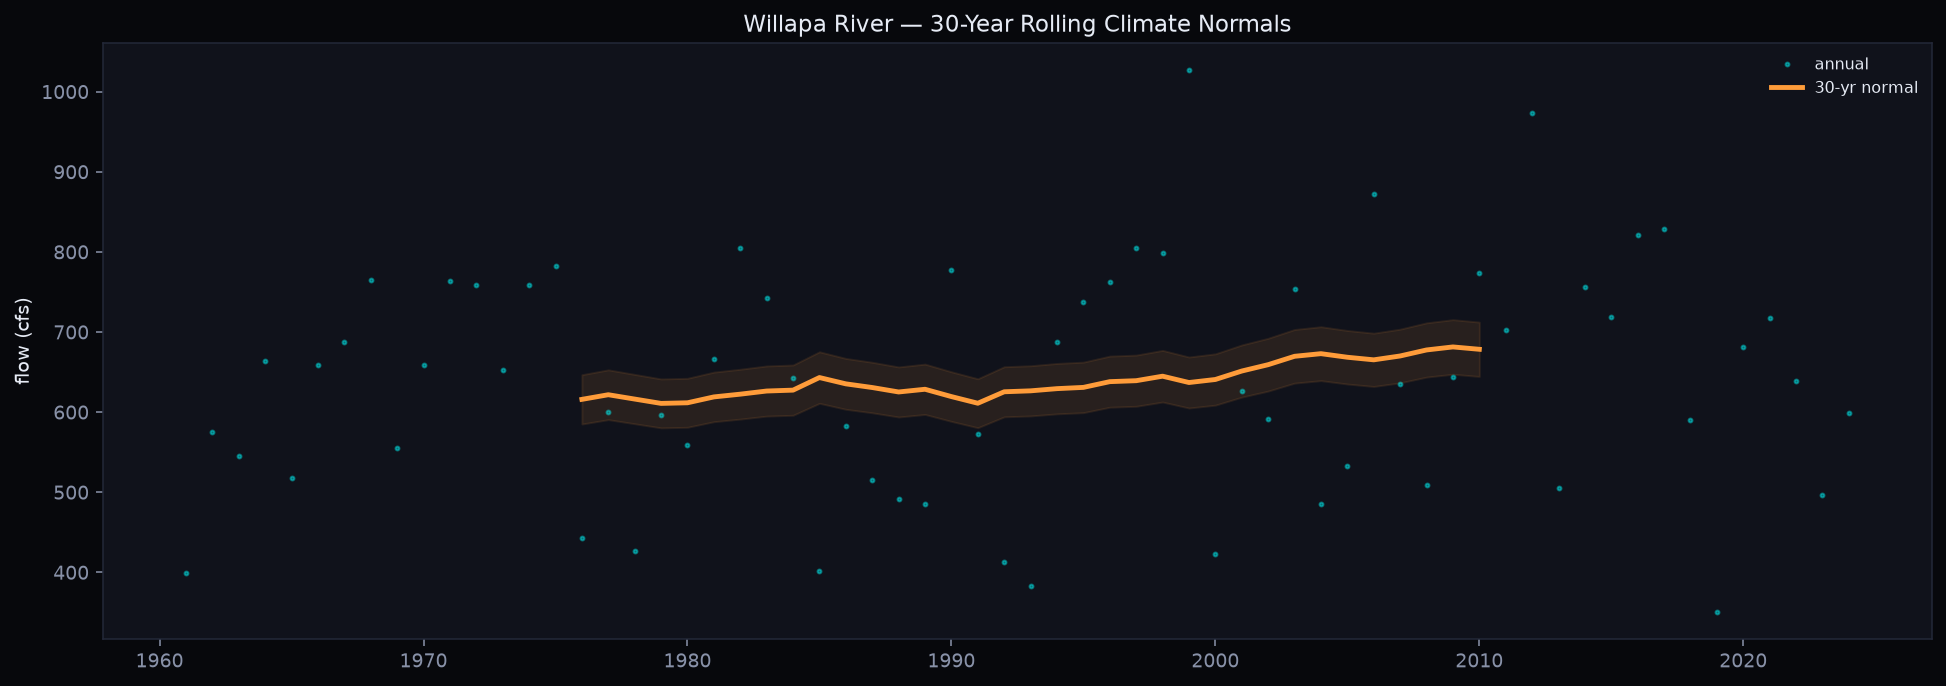

In [17]:
def plot_rolling_normals(obs, title, ax):
    years = sorted(obs.keys())
    annual = [float(np.nanmean(obs[y])) for y in years]
    if len(annual) < 30:
        ax.text(0.5, 0.5, "Need 30+ years for normals", ha="center",
                transform=ax.transAxes, color=MUTED)
        ax.set_title(title)
        return
    normals = fm.rolling_normals(annual, window=30)
    center_years = [years[n.start + 15] for n in normals]
    means = [n.mean for n in normals]
    ax.plot(years, annual, "o", color=CYAN, ms=2, alpha=0.4, label="annual")
    ax.plot(center_years, means, "-", color=AMBER, lw=2.5, label="30-yr normal")
    ax.fill_between(center_years,
                    [m * 0.95 for m in means],
                    [m * 1.05 for m in means],
                    color=AMBER, alpha=0.1)
    ax.set_ylabel("flow (cfs)")
    ax.set_title(title)
    ax.legend(fontsize=8, frameon=False)

fig, ax = plt.subplots(figsize=(14, 5))
plot_rolling_normals(willapa_obs, "Willapa River — 30-Year Rolling Climate Normals", ax)
plt.tight_layout()
plt.show()

---
## 16. Monthly Flow Histograms

Distribution of observed monthly flows for each month — reveals which months
are tightly clustered vs. highly variable.

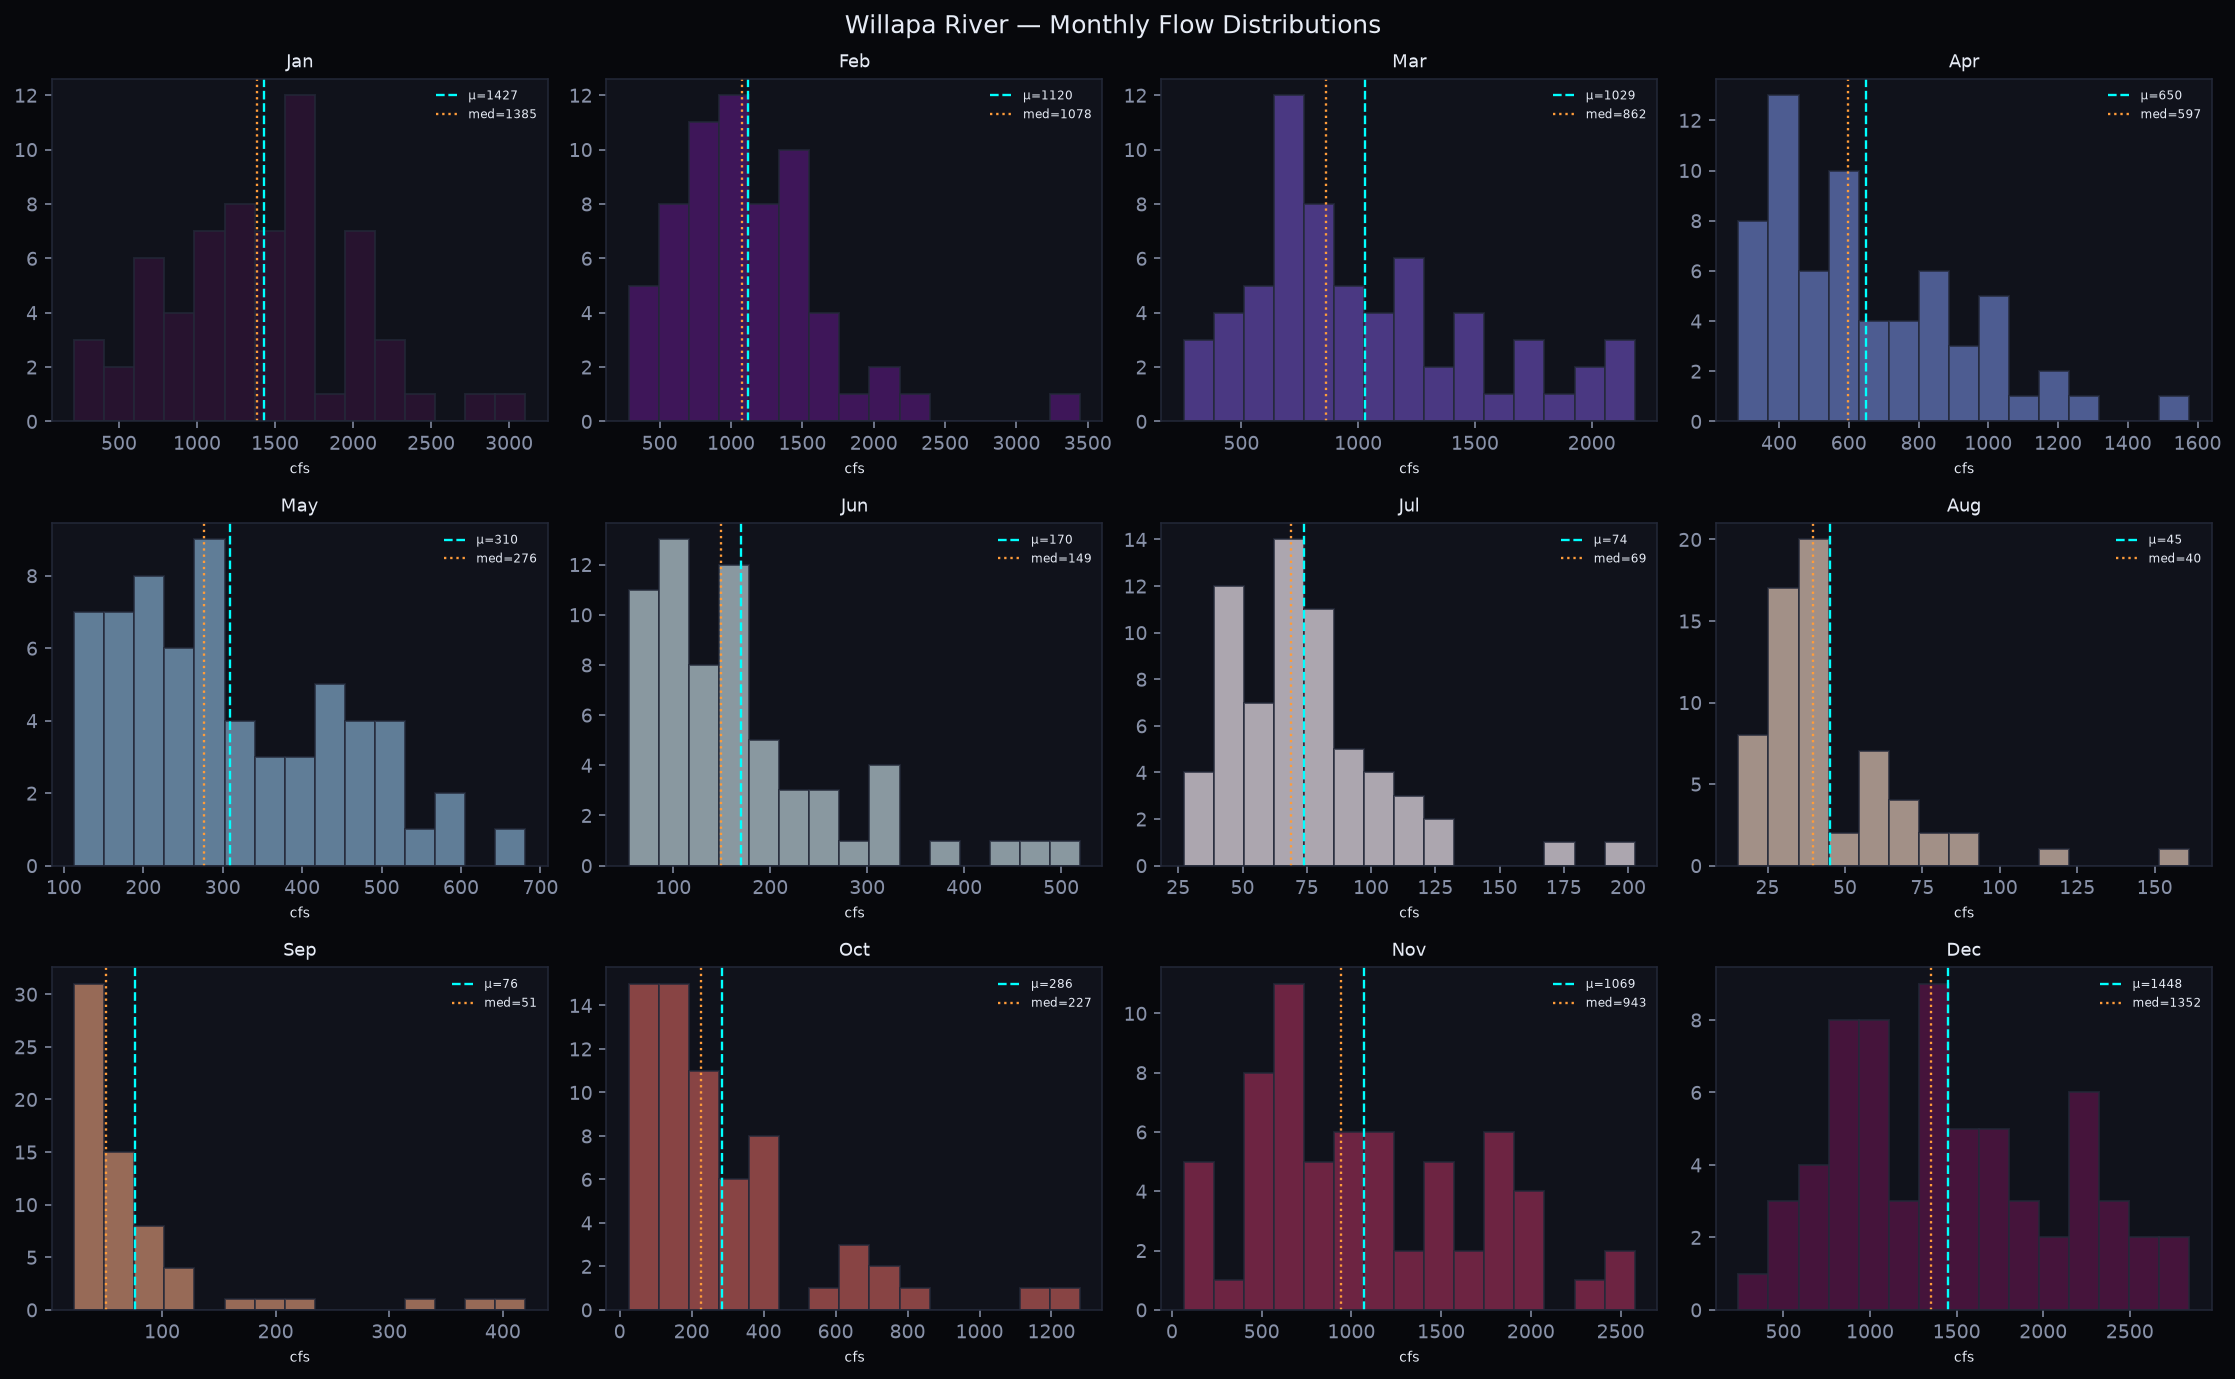

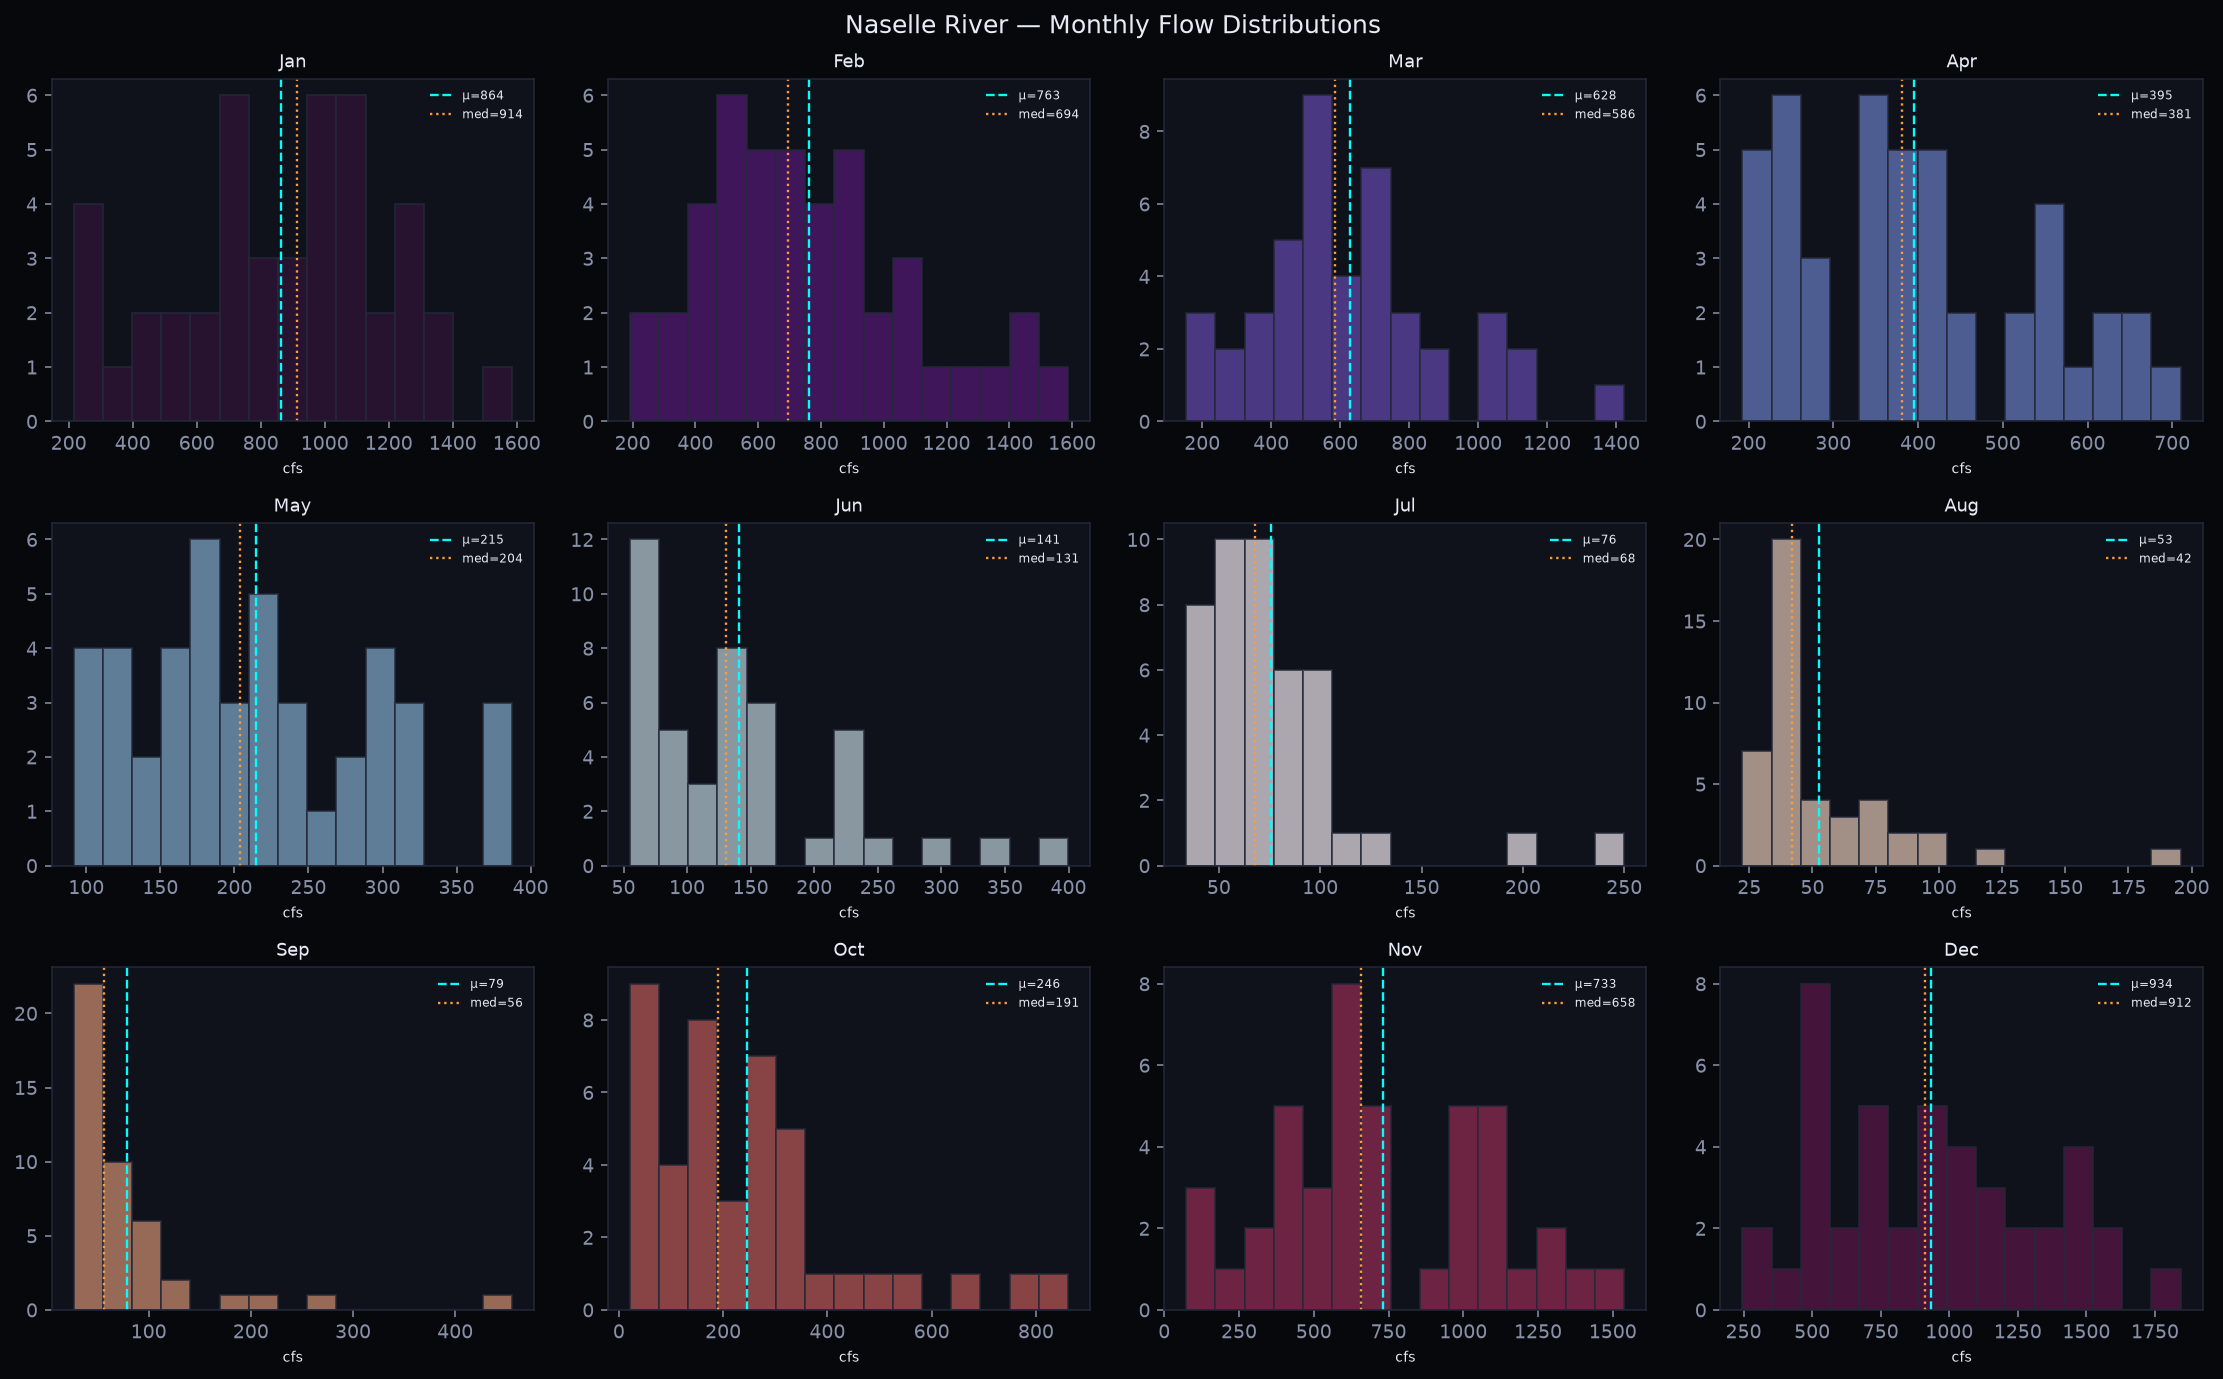

In [18]:
def plot_monthly_histograms(obs, title):
    years = sorted(obs.keys())
    fig, axes = plt.subplots(3, 4, figsize=(16, 10))
    fig.suptitle(title, fontsize=13, color=LIGHT)
    cmap = plt.get_cmap("twilight_shifted")
    for m in range(12):
        ax = axes[m // 4, m % 4]
        vals = [obs[y][m] for y in years if np.isfinite(obs[y][m])]
        color = cmap(m / 12)
        ax.hist(vals, bins=15, color=color, alpha=0.75, edgecolor="#232838")
        ax.axvline(np.mean(vals), color=CYAN, ls="--", lw=1.2, label=f"μ={np.mean(vals):.0f}")
        ax.axvline(np.median(vals), color=AMBER, ls=":", lw=1.2, label=f"med={np.median(vals):.0f}")
        ax.set_title(MONTH_ABBR[m], fontsize=9)
        ax.set_xlabel("cfs", fontsize=7)
        ax.legend(fontsize=6, frameon=False)
    plt.tight_layout()
    plt.show()

plot_monthly_histograms(willapa_obs, "Willapa River — Monthly Flow Distributions")
plot_monthly_histograms(naselle_obs, "Naselle River — Monthly Flow Distributions")

---
## 17. Annual Flow Histogram + Kernel Density

How is annual-mean flow distributed across the entire record?

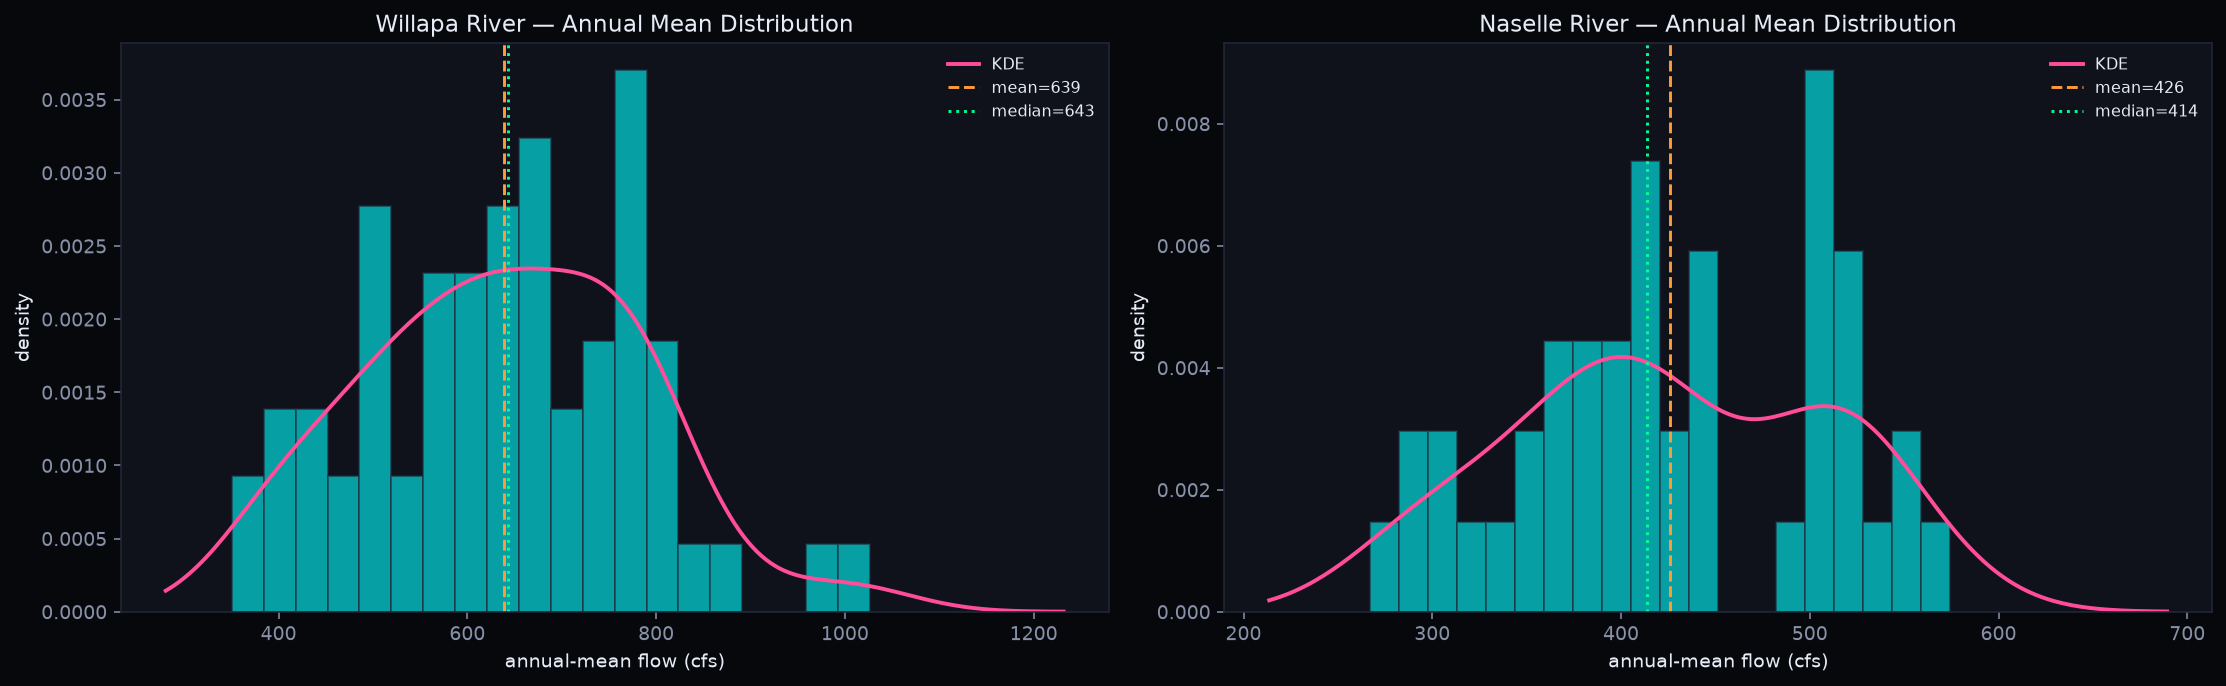

In [19]:
def plot_annual_histogram(obs, title, ax):
    years = sorted(obs.keys())
    annual = np.array([float(np.nanmean(obs[y])) for y in years])
    ax.hist(annual, bins=20, color=CYAN, alpha=0.6, edgecolor="#232838", density=True)
    # kernel density estimate (Gaussian, bandwidth = Silverman)
    from scipy.stats import gaussian_kde
    try:
        kde = gaussian_kde(annual)
        x_kde = np.linspace(annual.min() * 0.8, annual.max() * 1.2, 200)
        ax.plot(x_kde, kde(x_kde), color=MAGENTA, lw=2, label="KDE")
    except Exception:
        pass  # scipy not available — histogram alone
    ax.axvline(np.mean(annual), color=AMBER, ls="--", lw=1.5, label=f"mean={np.mean(annual):.0f}")
    ax.axvline(np.median(annual), color=LIME, ls=":", lw=1.5, label=f"median={np.median(annual):.0f}")
    ax.set_xlabel("annual-mean flow (cfs)")
    ax.set_ylabel("density")
    ax.set_title(title)
    ax.legend(fontsize=8, frameon=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_annual_histogram(willapa_obs, "Willapa River — Annual Mean Distribution", axes[0])
plot_annual_histogram(naselle_obs, "Naselle River — Annual Mean Distribution", axes[1])
plt.tight_layout()
plt.show()

---
## 18. Cross-Gauge Correlation — Willapa vs. Naselle

How similar are the two rivers? They share the same weather but have
different catchment sizes and geometries.

Common years: 1961–2003 (43 yr)


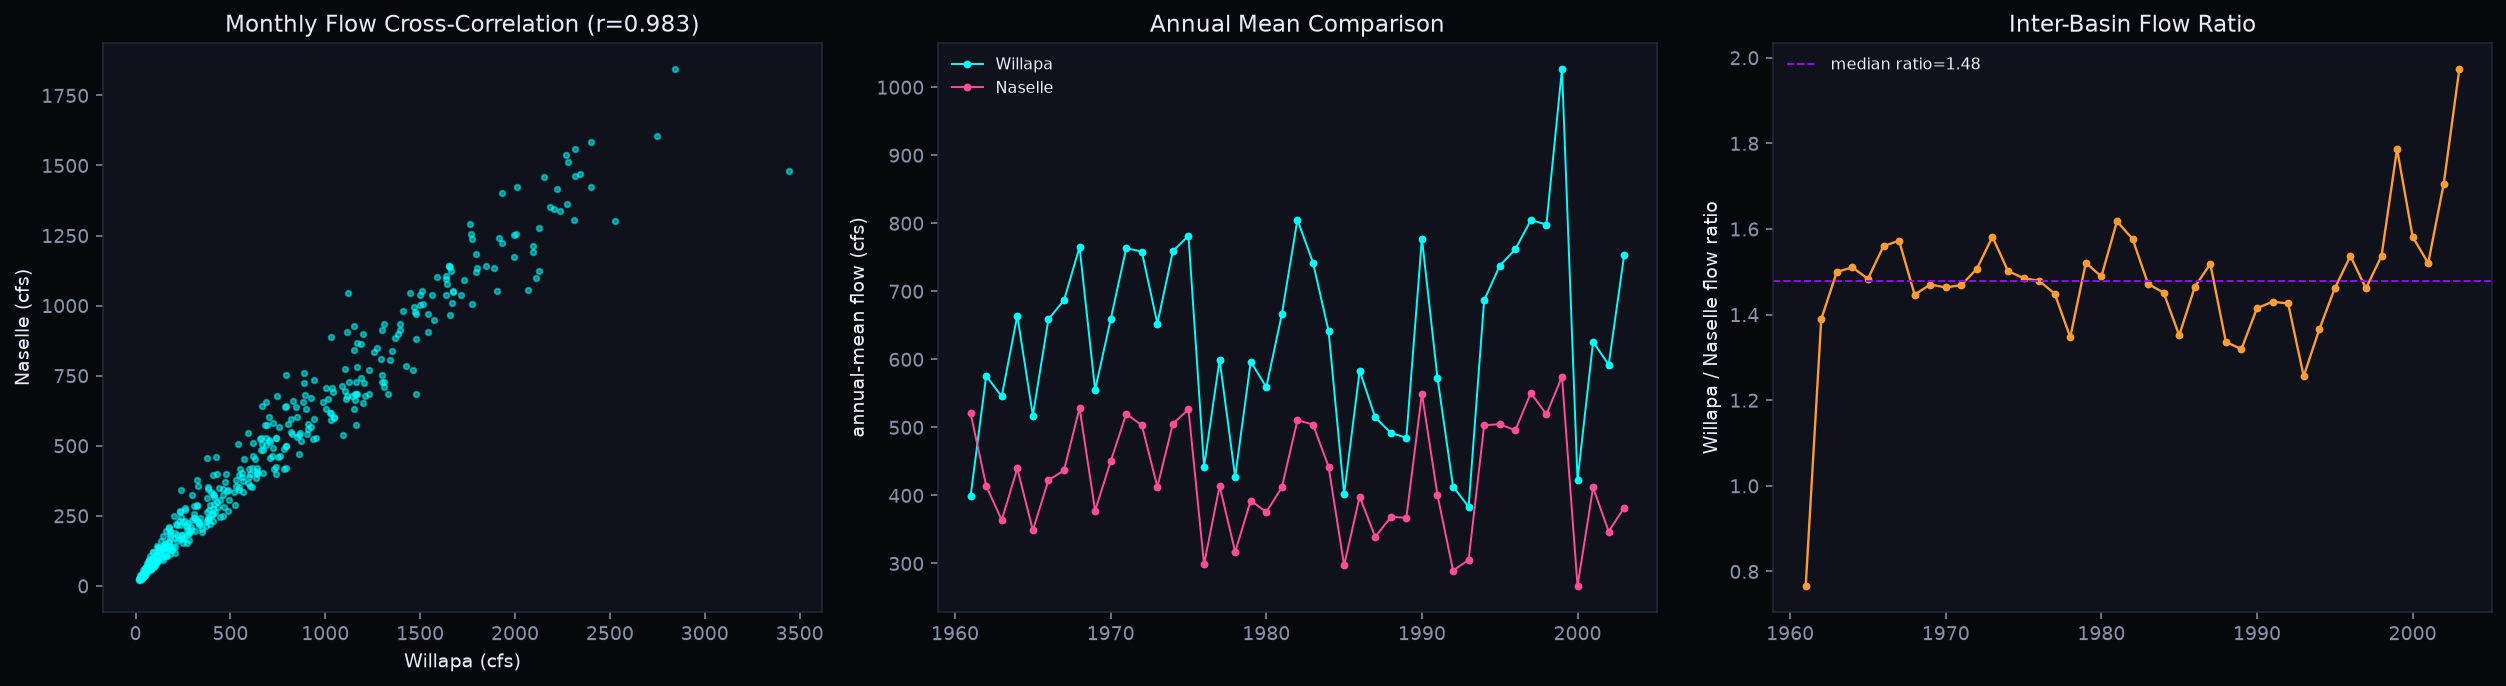

In [20]:
# overlap period
common_years = sorted(set(willapa_obs) & set(naselle_obs))
print(f"Common years: {common_years[0]}–{common_years[-1]} ({len(common_years)} yr)")

w_flat = np.concatenate([willapa_obs[y] for y in common_years])
n_flat = np.concatenate([naselle_obs[y] for y in common_years])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# scatter
ax = axes[0]
ax.scatter(w_flat, n_flat, s=8, color=CYAN, alpha=0.5)
r = fm.pearson_r(w_flat, n_flat)
lim = [0, max(w_flat.max(), n_flat.max()) * 1.05]
ax.plot(lim, lim, "--", color=MUTED, lw=1)
ax.set_xlabel("Willapa (cfs)")
ax.set_ylabel("Naselle (cfs)")
ax.set_title(f"Monthly Flow Cross-Correlation (r={r:.3f})")

# annual mean comparison
ax = axes[1]
w_ann = [float(np.nanmean(willapa_obs[y])) for y in common_years]
n_ann = [float(np.nanmean(naselle_obs[y])) for y in common_years]
ax.plot(common_years, w_ann, "o-", color=CYAN, ms=3, lw=1, label="Willapa")
ax.plot(common_years, n_ann, "o-", color=MAGENTA, ms=3, lw=1, label="Naselle")
ax.set_ylabel("annual-mean flow (cfs)")
ax.set_title("Annual Mean Comparison")
ax.legend(fontsize=8, frameon=False)

# ratio time series
ax = axes[2]
ratio = np.array(w_ann) / np.array(n_ann)
ax.plot(common_years, ratio, "o-", color=AMBER, ms=3, lw=1.2)
ax.axhline(np.median(ratio), color=VIOLET, ls="--", lw=1,
           label=f"median ratio={np.median(ratio):.2f}")
ax.set_ylabel("Willapa / Naselle flow ratio")
ax.set_title("Inter-Basin Flow Ratio")
ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

---
## 19. Heatmap — Month × Year Flow Matrix

Every observed monthly flow value as a color cell. Reveals multi-year
drought/flood clusters and seasonal patterns at a glance.

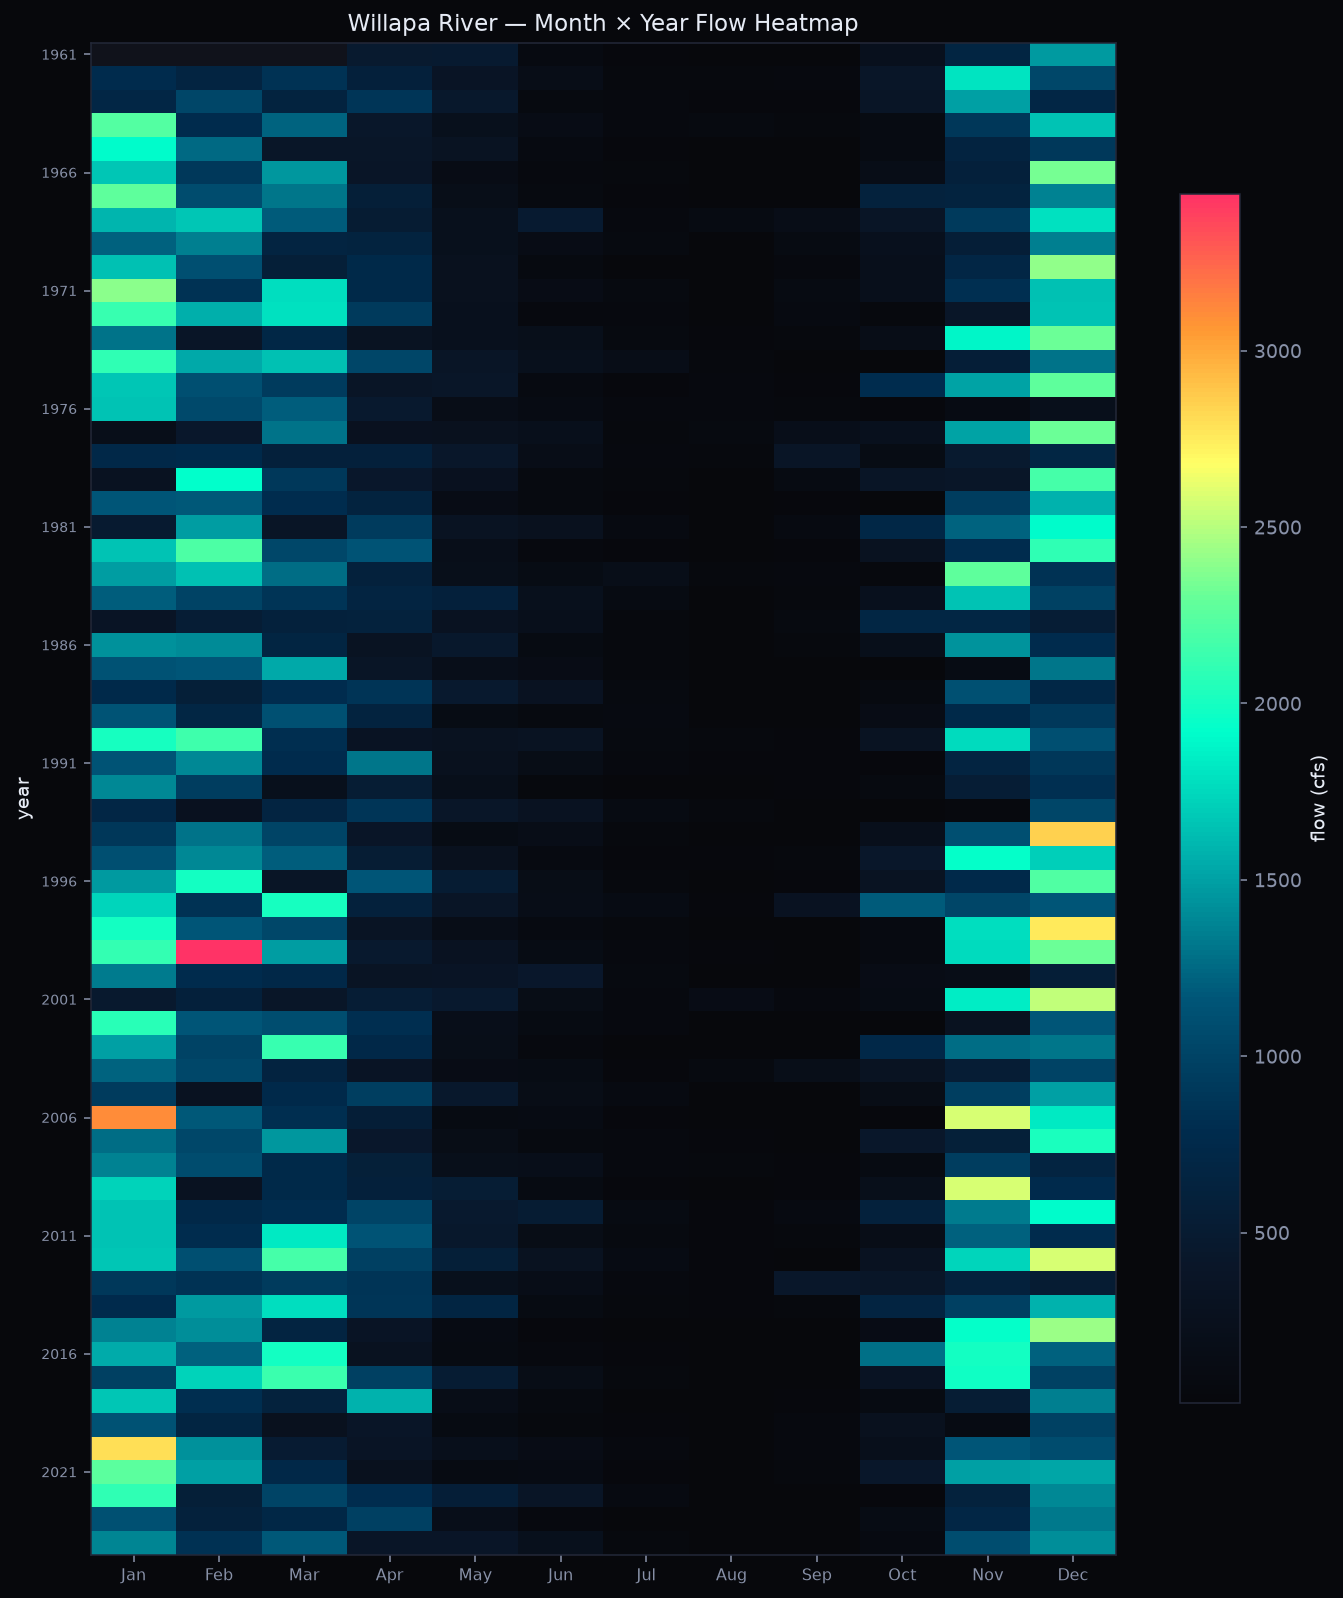

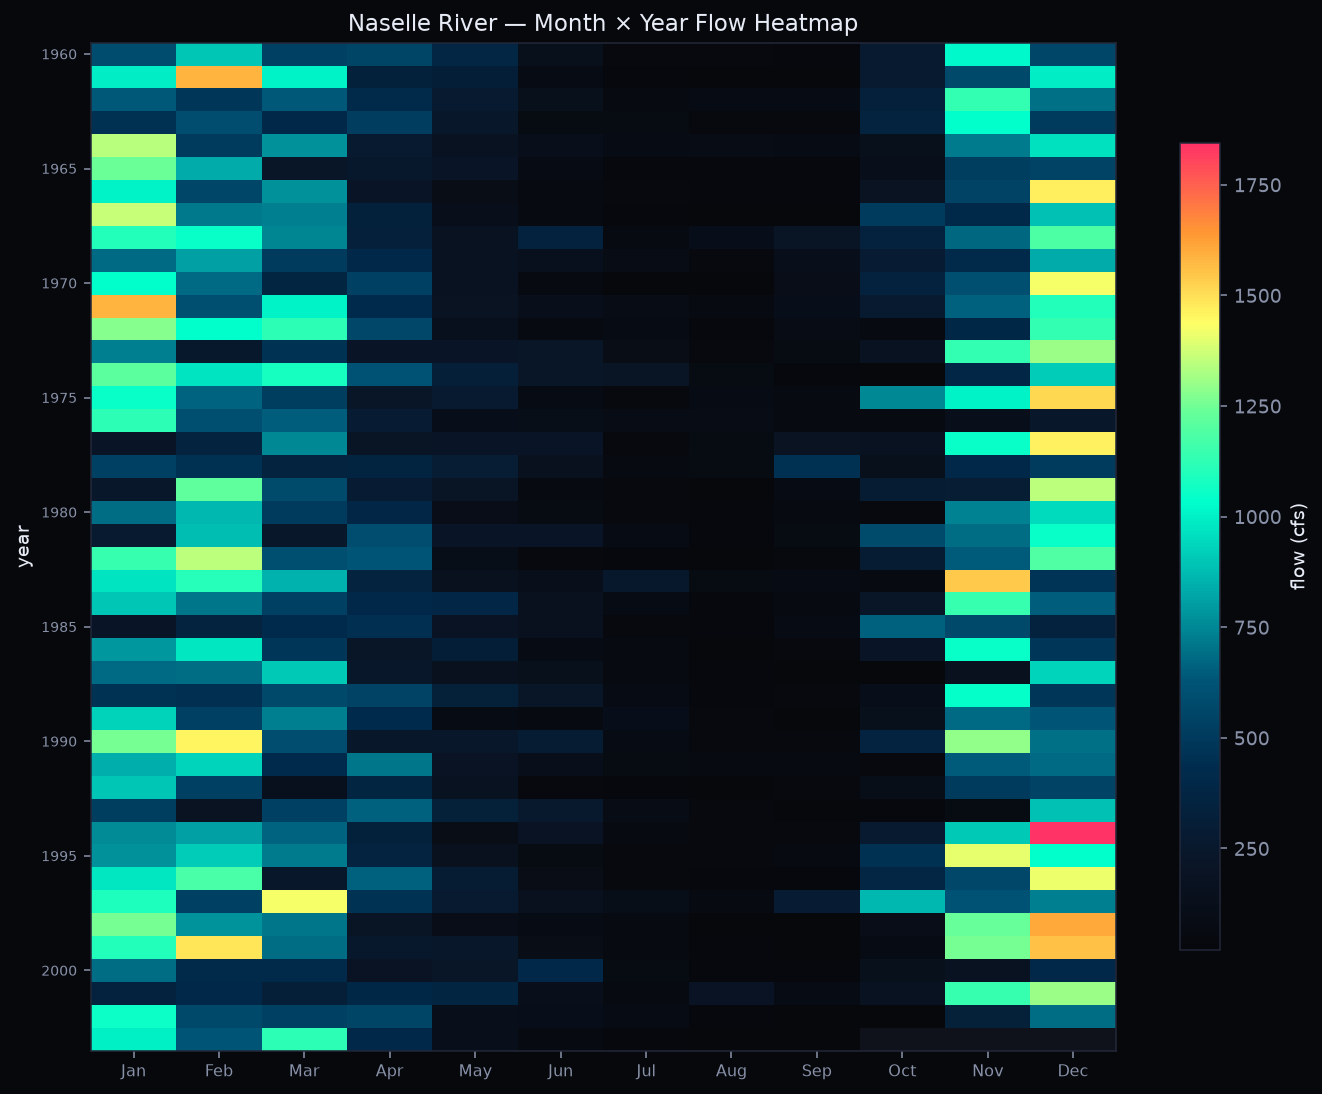

In [21]:
def plot_heatmap(obs, title):
    years = sorted(obs.keys())
    mat = np.array([obs[y] for y in years])
    fig, ax = plt.subplots(figsize=(10, max(6, len(years) * 0.18)))
    # custom neon colormap
    neon_cmap = LinearSegmentedColormap.from_list(
        "neon", ["#07080c", "#0a1628", "#002b4d", "#005577", "#00aaaa",
                 "#00ffcc", "#66ff99", "#ffff66", "#ff9933", "#ff3366"])
    im = ax.imshow(mat, aspect="auto", cmap=neon_cmap, interpolation="nearest")
    ax.set_xticks(range(12))
    ax.set_xticklabels(MONTH_ABBR, fontsize=8)
    # show every 5th year label
    ytick_idx = list(range(0, len(years), 5))
    ax.set_yticks(ytick_idx)
    ax.set_yticklabels([years[i] for i in ytick_idx], fontsize=7)
    ax.set_ylabel("year")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="flow (cfs)", shrink=0.8)
    plt.tight_layout()
    plt.show()

plot_heatmap(willapa_obs, "Willapa River — Month × Year Flow Heatmap")
plot_heatmap(naselle_obs, "Naselle River — Month × Year Flow Heatmap")

---
## 20. Box Plots — Monthly Flow Distributions

Quartile-based view of each month's flow distribution with outliers.

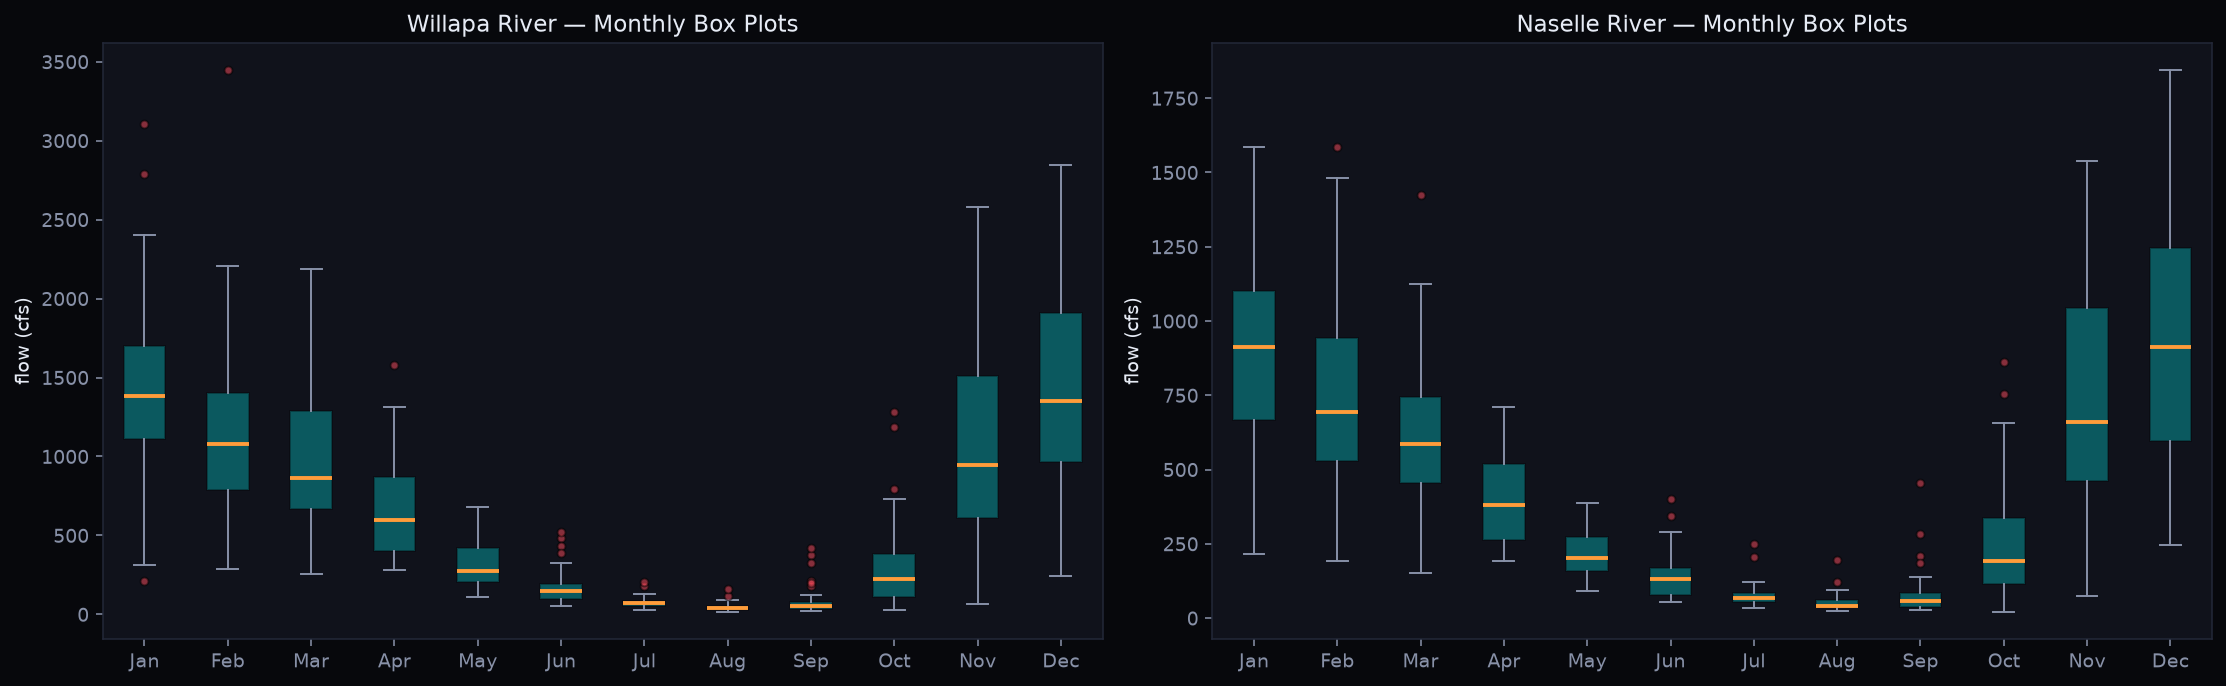

In [22]:
def plot_monthly_box(obs, title, ax):
    years = sorted(obs.keys())
    data = [[obs[y][m] for y in years if np.isfinite(obs[y][m])] for m in range(12)]
    bp = ax.boxplot(data, patch_artist=True, tick_labels=MONTH_ABBR,
                    boxprops=dict(facecolor=CYAN, alpha=0.3),
                    medianprops=dict(color=AMBER, lw=2),
                    whiskerprops=dict(color=MUTED),
                    capprops=dict(color=MUTED),
                    flierprops=dict(marker="o", markerfacecolor=RED, ms=4, alpha=0.5))
    ax.set_ylabel("flow (cfs)")
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_monthly_box(willapa_obs, "Willapa River — Monthly Box Plots", axes[0])
plot_monthly_box(naselle_obs, "Naselle River — Monthly Box Plots", axes[1])
plt.tight_layout()
plt.show()

---
## 21. Climate Index Time Series — ONI + PDO

The raw climate drivers overlaid on the flow record.

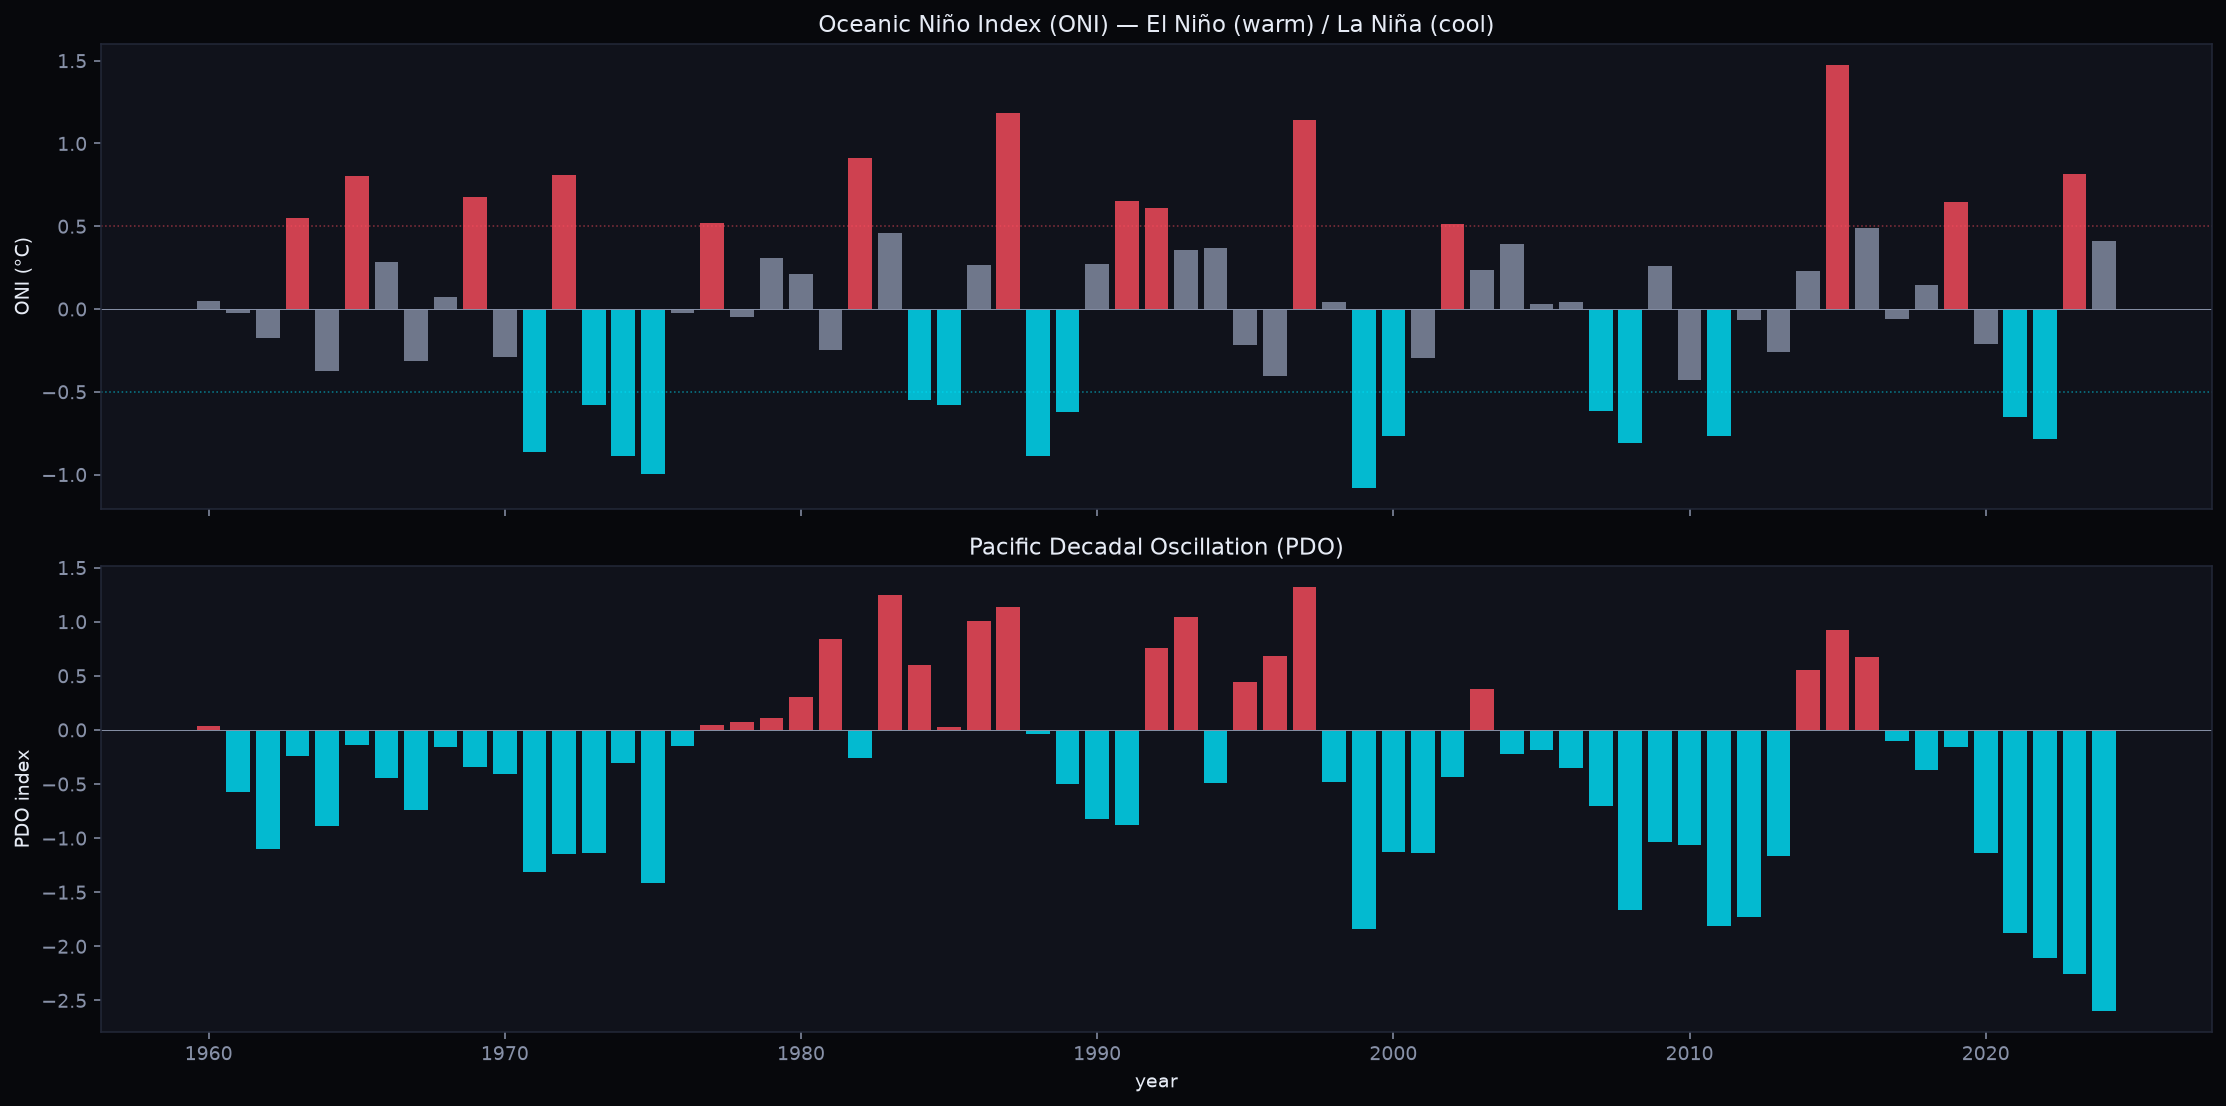

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# ONI
ax = axes[0]
oni_years = sorted(oni.keys())
oni_vals = [oni[y] for y in oni_years]
colors_oni = [RED if v >= 0.5 else COOL_BLUE if v <= -0.5 else MUTED for v in oni_vals]
ax.bar(oni_years, oni_vals, color=colors_oni, alpha=0.8, width=0.8)
ax.axhline(0.5, color=RED, ls=":", lw=0.8, alpha=0.5)
ax.axhline(-0.5, color=COOL_BLUE, ls=":", lw=0.8, alpha=0.5)
ax.axhline(0, color=MUTED, ls="-", lw=0.5)
ax.set_ylabel("ONI (°C)")
ax.set_title("Oceanic Niño Index (ONI) — El Niño (warm) / La Niña (cool)")

# PDO
ax = axes[1]
pdo_years = sorted(pdo.keys())
pdo_vals = [pdo[y] for y in pdo_years]
colors_pdo = [RED if v > 0 else COOL_BLUE for v in pdo_vals]
ax.bar(pdo_years, pdo_vals, color=colors_pdo, alpha=0.8, width=0.8)
ax.axhline(0, color=MUTED, ls="-", lw=0.5)
ax.set_ylabel("PDO index")
ax.set_title("Pacific Decadal Oscillation (PDO)")
ax.set_xlabel("year")

plt.tight_layout()
plt.show()

---
## 22. Decadal Shift Analysis

Compare each decade's mean hydrograph to the long-term average.
How has the seasonal shape itself evolved?

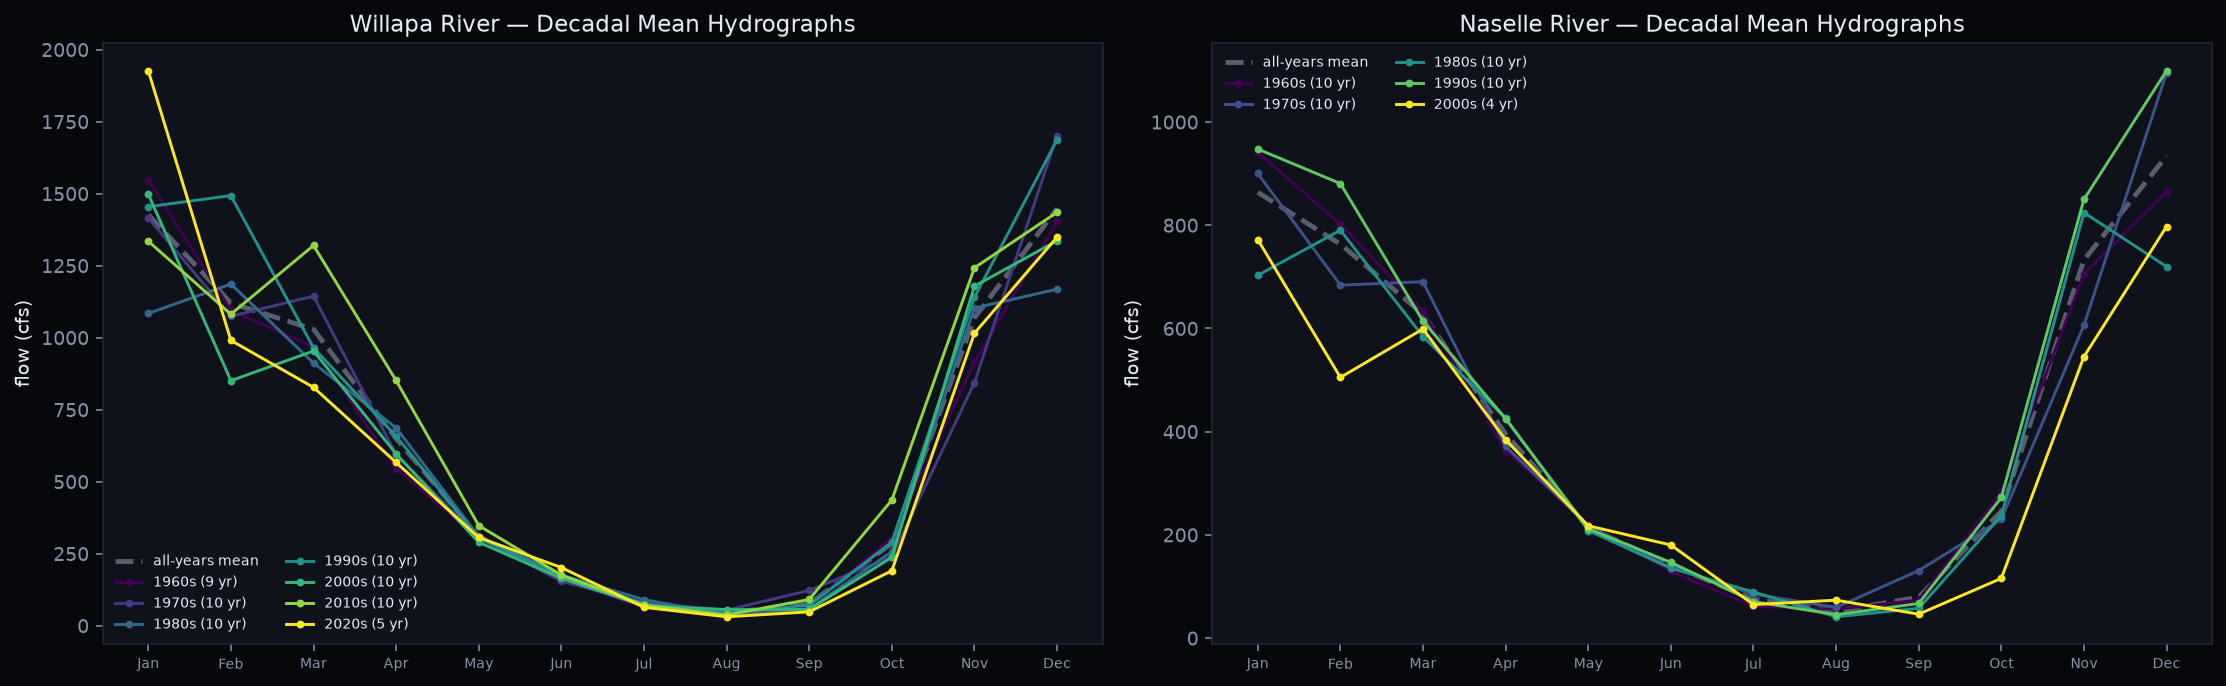

In [24]:
def plot_decadal_shift(obs, title, ax):
    years = sorted(obs.keys())
    overall_mean = np.nanmean([obs[y] for y in years], axis=0)
    decades = {}
    for y in years:
        d = (y // 10) * 10
        decades.setdefault(d, []).append(obs[y])
    cmap = plt.get_cmap("viridis")
    dec_list = sorted(decades.keys())
    span = max(1, len(dec_list) - 1)
    m = range(1, 13)
    ax.plot(m, overall_mean, color=MUTED, lw=2.5, ls="--", label="all-years mean", alpha=0.6)
    for i, d in enumerate(dec_list):
        dmean = np.nanmean(decades[d], axis=0)
        ax.plot(m, dmean, "-o", ms=3, lw=1.5, color=cmap(i / span),
                label=f"{d}s ({len(decades[d])} yr)")
    ax.set_xticks(list(m))
    ax.set_xticklabels(MONTH_ABBR, fontsize=7)
    ax.set_ylabel("flow (cfs)")
    ax.set_title(title)
    ax.legend(fontsize=7, frameon=False, ncol=2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_decadal_shift(willapa_obs, "Willapa River — Decadal Mean Hydrographs", axes[0])
plot_decadal_shift(naselle_obs, "Naselle River — Decadal Mean Hydrographs", axes[1])
plt.tight_layout()
plt.show()

---
## 23. Anomaly Stripes — Annual Departure from Normal

Warming-stripes inspired visualization showing each year's departure
from the long-term mean as a colored bar.

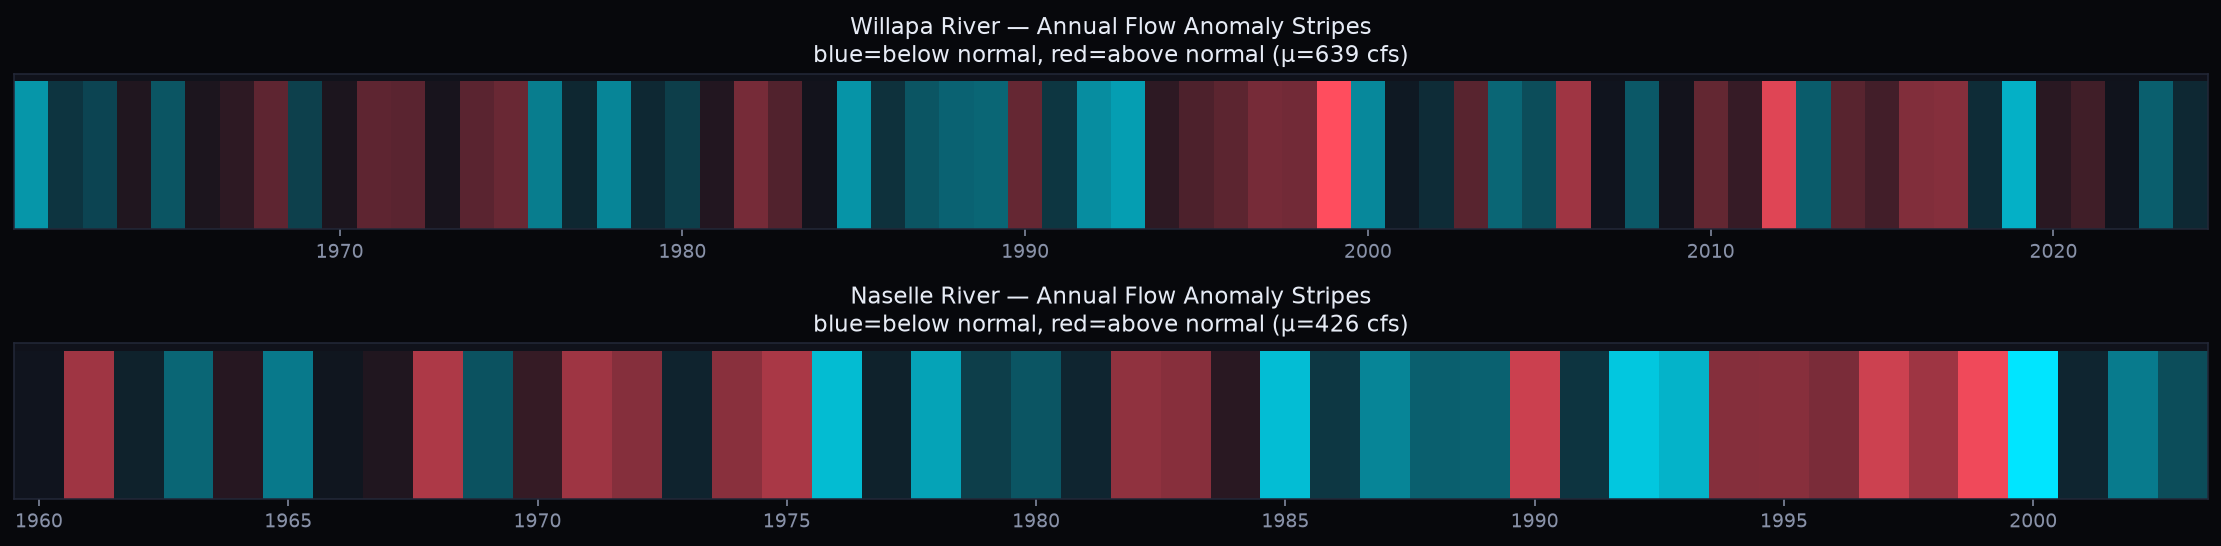

In [25]:
def plot_anomaly_stripes(obs, title, ax):
    years = sorted(obs.keys())
    annual = np.array([float(np.nanmean(obs[y])) for y in years])
    normal = np.mean(annual)
    anomalies = annual - normal
    vmax = max(abs(anomalies.min()), abs(anomalies.max()))
    cmap_div = LinearSegmentedColormap.from_list(
        "anomaly", [COOL_BLUE, "#10121b", RED])
    for i, (y, a) in enumerate(zip(years, anomalies)):
        color = cmap_div((a / vmax + 1) / 2)
        ax.bar(y, 1, color=color, width=1.0, edgecolor="none")
    ax.set_xlim(min(years) - 0.5, max(years) + 0.5)
    ax.set_yticks([])
    ax.set_title(f"{title}\nblue=below normal, red=above normal (μ={normal:.0f} cfs)")

fig, axes = plt.subplots(2, 1, figsize=(16, 4))
plot_anomaly_stripes(willapa_obs, "Willapa River — Annual Flow Anomaly Stripes", axes[0])
plot_anomaly_stripes(naselle_obs, "Naselle River — Annual Flow Anomaly Stripes", axes[1])
plt.tight_layout()
plt.show()

---
## 24. Cumulative Flow — Water Year Accumulation

Cumulative monthly flow through each year, showing when the annual
water budget fills up. Steeper slopes = higher flow periods.

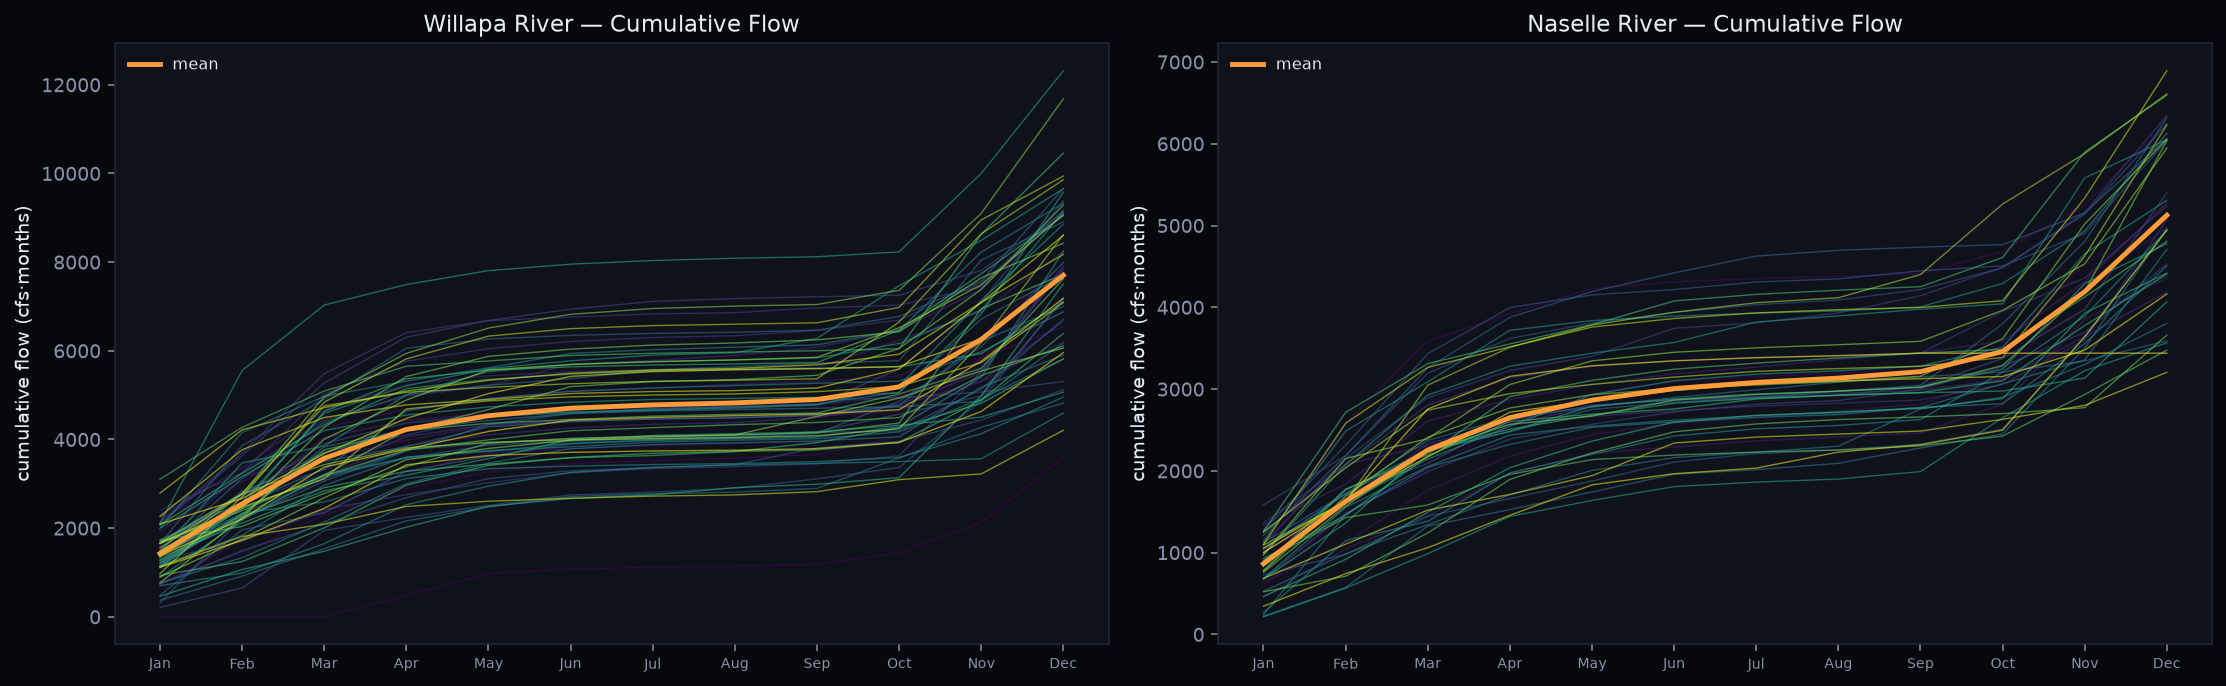

In [26]:
def plot_cumulative(obs, title, ax):
    years = sorted(obs.keys())
    cmap = plt.get_cmap("viridis")
    span = max(years) - min(years) or 1
    for y in years:
        cumul = np.nancumsum(obs[y])
        ax.plot(range(1, 13), cumul, color=cmap((y - min(years)) / span),
                lw=0.7, alpha=0.6)
    # mean cumulative
    mean_cumul = np.nancumsum(np.nanmean([obs[y] for y in years], axis=0))
    ax.plot(range(1, 13), mean_cumul, color=AMBER, lw=2.5, label="mean")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_ABBR, fontsize=7)
    ax.set_ylabel("cumulative flow (cfs·months)")
    ax.set_title(title)
    ax.legend(fontsize=8, frameon=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_cumulative(willapa_obs, "Willapa River — Cumulative Flow", axes[0])
plot_cumulative(naselle_obs, "Naselle River — Cumulative Flow", axes[1])
plt.tight_layout()
plt.show()

---
## 25. Return Period Estimate — Annual Peaks

Empirical return period (Weibull plotting position) for annual peak
monthly flows. How rare was each year's highest flow?

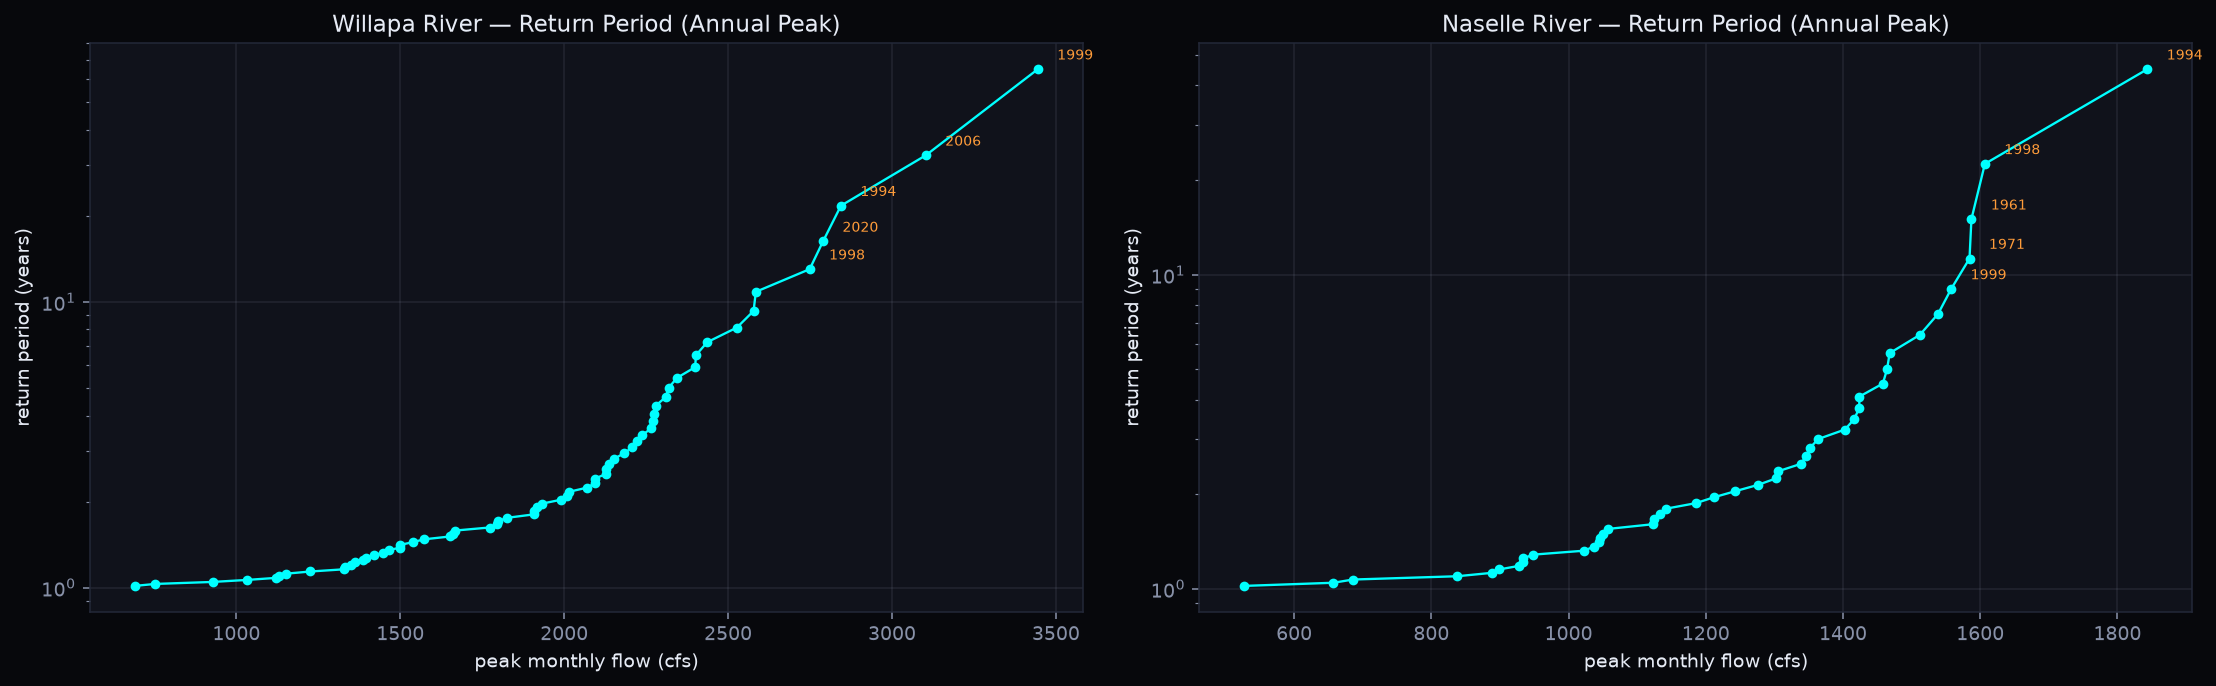

In [27]:
def plot_return_period(obs, title, ax):
    years = sorted(obs.keys())
    peaks = np.array([float(np.nanmax(obs[y])) for y in years])
    n = len(peaks)
    # Weibull plotting position
    sorted_peaks = np.sort(peaks)[::-1]
    rank = np.arange(1, n + 1)
    return_period = (n + 1) / rank
    ax.semilogy(sorted_peaks, return_period, "o-", color=CYAN, ms=4, lw=1.2)
    # label top-5 events
    for i in range(min(5, n)):
        yr_idx = int(np.where(peaks == sorted_peaks[i])[0][0])
        ax.annotate(str(years[yr_idx]),
                    xy=(sorted_peaks[i], return_period[i]),
                    xytext=(10, 5), textcoords="offset points",
                    fontsize=7, color=AMBER)
    ax.set_xlabel("peak monthly flow (cfs)")
    ax.set_ylabel("return period (years)")
    ax.set_title(title)
    ax.grid(True, alpha=0.15, color=MUTED)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_return_period(willapa_obs, "Willapa River — Return Period (Annual Peak)", axes[0])
plot_return_period(naselle_obs, "Naselle River — Return Period (Annual Peak)", axes[1])
plt.tight_layout()
plt.show()

---
## 26. Lag-1 Autocorrelogram — Year Memory

Does a wet year predict the next year? Autocorrelation at lags 1–15 years
reveals persistence (multi-year drought/pluvial cycles).

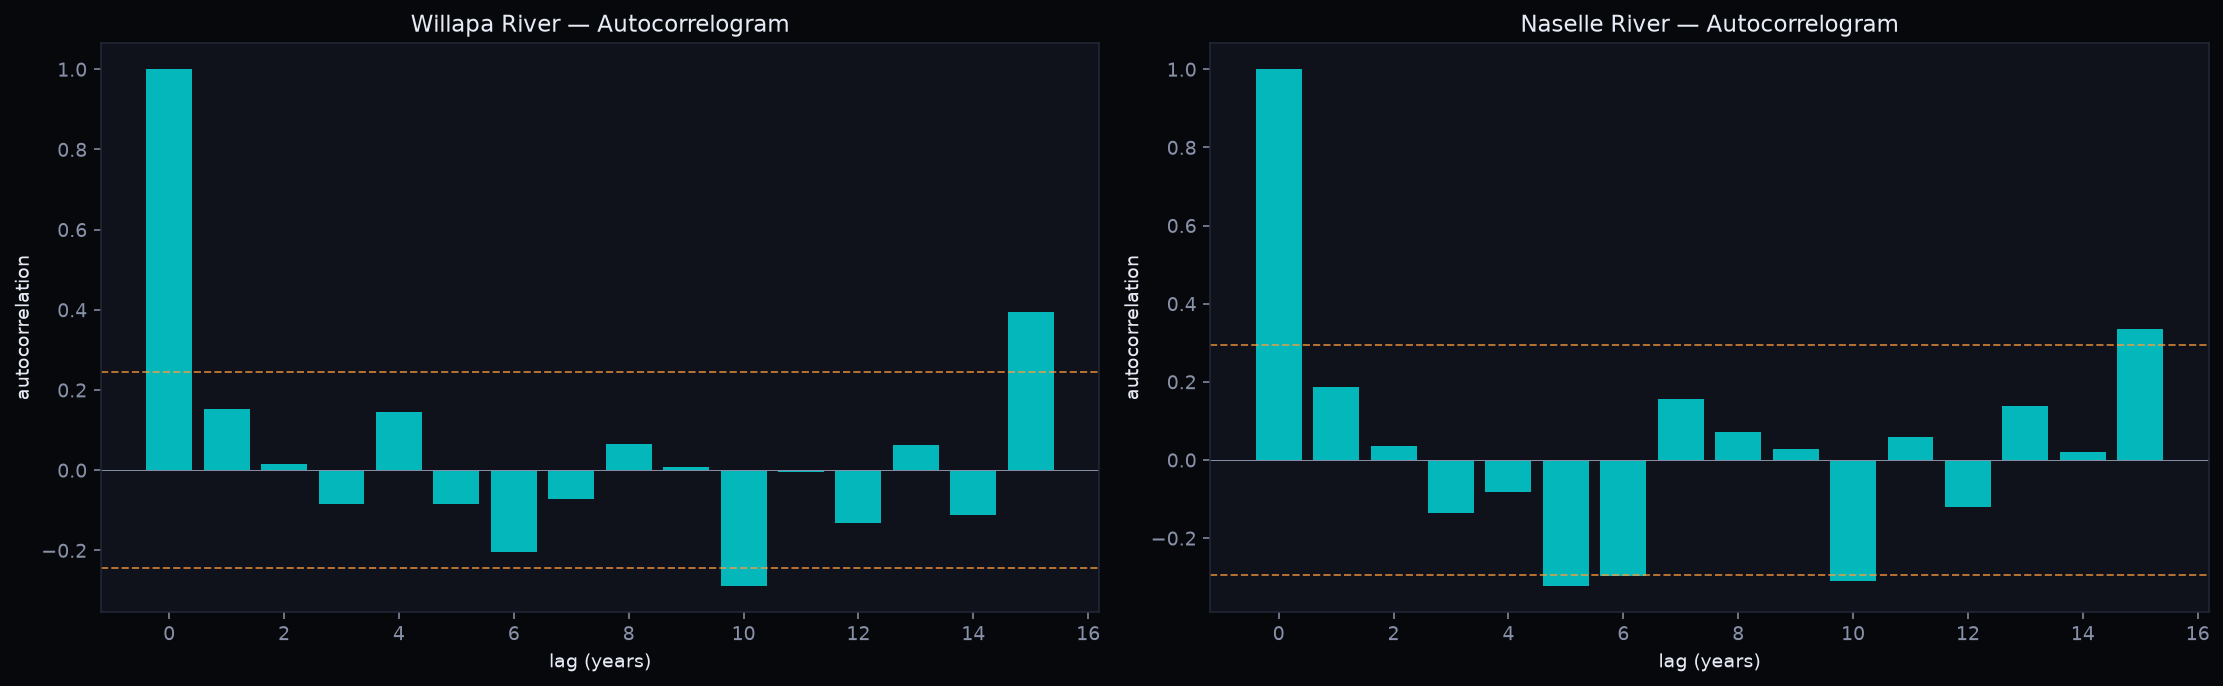

In [28]:
def plot_autocorrelation(obs, title, ax, *, max_lag=15):
    years = sorted(obs.keys())
    annual = np.array([float(np.nanmean(obs[y])) for y in years])
    n = len(annual)
    mean = annual.mean()
    var = annual.var()
    acf = []
    for lag in range(max_lag + 1):
        if lag >= n:
            break
        cov = np.mean((annual[:n-lag] - mean) * (annual[lag:] - mean)) if lag > 0 else var
        acf.append(cov / var if var > 0 else 0)
    lags = range(len(acf))
    ax.bar(lags, acf, color=CYAN, alpha=0.7, width=0.8)
    # 95% confidence bounds
    ci = 1.96 / np.sqrt(n)
    ax.axhline(ci, color=AMBER, ls="--", lw=1, alpha=0.7)
    ax.axhline(-ci, color=AMBER, ls="--", lw=1, alpha=0.7)
    ax.axhline(0, color=MUTED, lw=0.5)
    ax.set_xlabel("lag (years)")
    ax.set_ylabel("autocorrelation")
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_autocorrelation(willapa_obs, "Willapa River — Autocorrelogram", axes[0])
plot_autocorrelation(naselle_obs, "Naselle River — Autocorrelogram", axes[1])
plt.tight_layout()
plt.show()

---
## 27. Percentile Rank Forecast Context

Where does the most recent year fall in the historical distribution?
Visualizes the percentile position of each month relative to the
full record — a forecast-like "how unusual is this year" view.

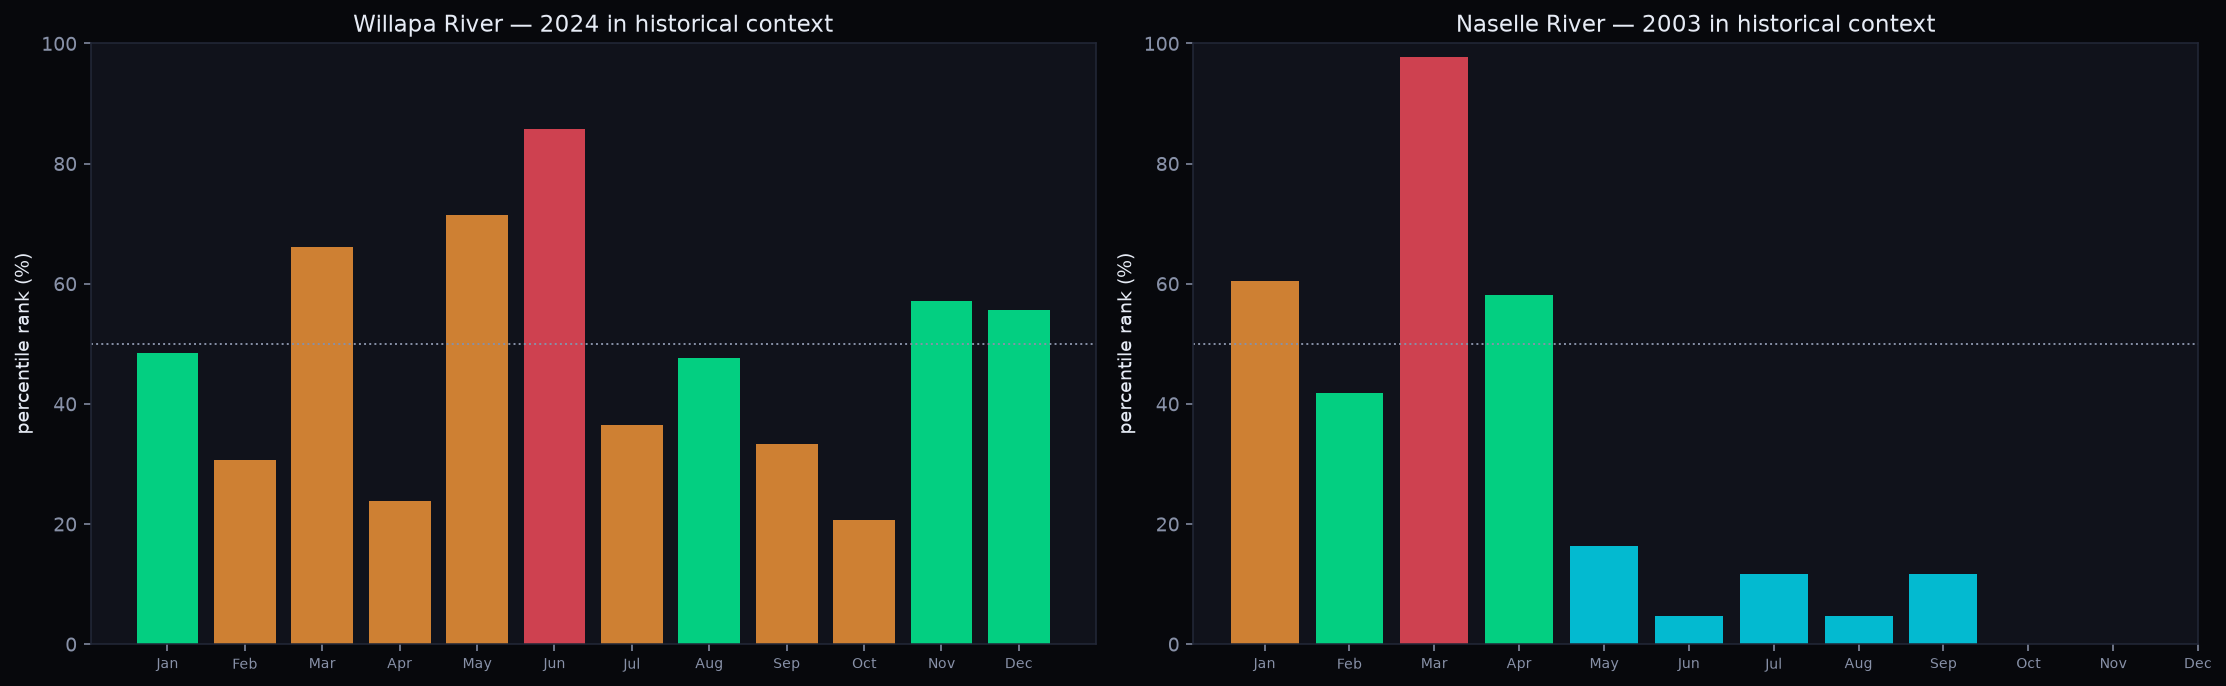

In [29]:
def plot_percentile_context(obs, title, ax):
    years = sorted(obs.keys())
    latest = years[-1]
    latest_flow = obs[latest]
    pctiles = []
    for m in range(12):
        record = np.array([obs[y][m] for y in years if np.isfinite(obs[y][m])])
        if len(record) > 1 and np.isfinite(latest_flow[m]):
            pctiles.append(fm.percentile_rank(latest_flow[m], record))
        else:
            pctiles.append(np.nan)
    colors = [RED if p > 0.8 else COOL_BLUE if p < 0.2 else LIME if 0.4 <= p <= 0.6 else AMBER
              for p in pctiles]
    bars = ax.bar(range(12), [p * 100 for p in pctiles], color=colors, alpha=0.8)
    ax.set_xticks(range(12))
    ax.set_xticklabels(MONTH_ABBR, fontsize=7)
    ax.set_ylabel("percentile rank (%)")
    ax.axhline(50, color=MUTED, ls=":", lw=1)
    ax.set_ylim(0, 100)
    ax.set_title(f"{title} — {latest} in historical context")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_percentile_context(willapa_obs, "Willapa River", axes[0])
plot_percentile_context(naselle_obs, "Naselle River", axes[1])
plt.tight_layout()
plt.show()

---
## 28. Multi-Metric Dashboard

Radar chart comparing the two gauges across six key metrics (normalized).

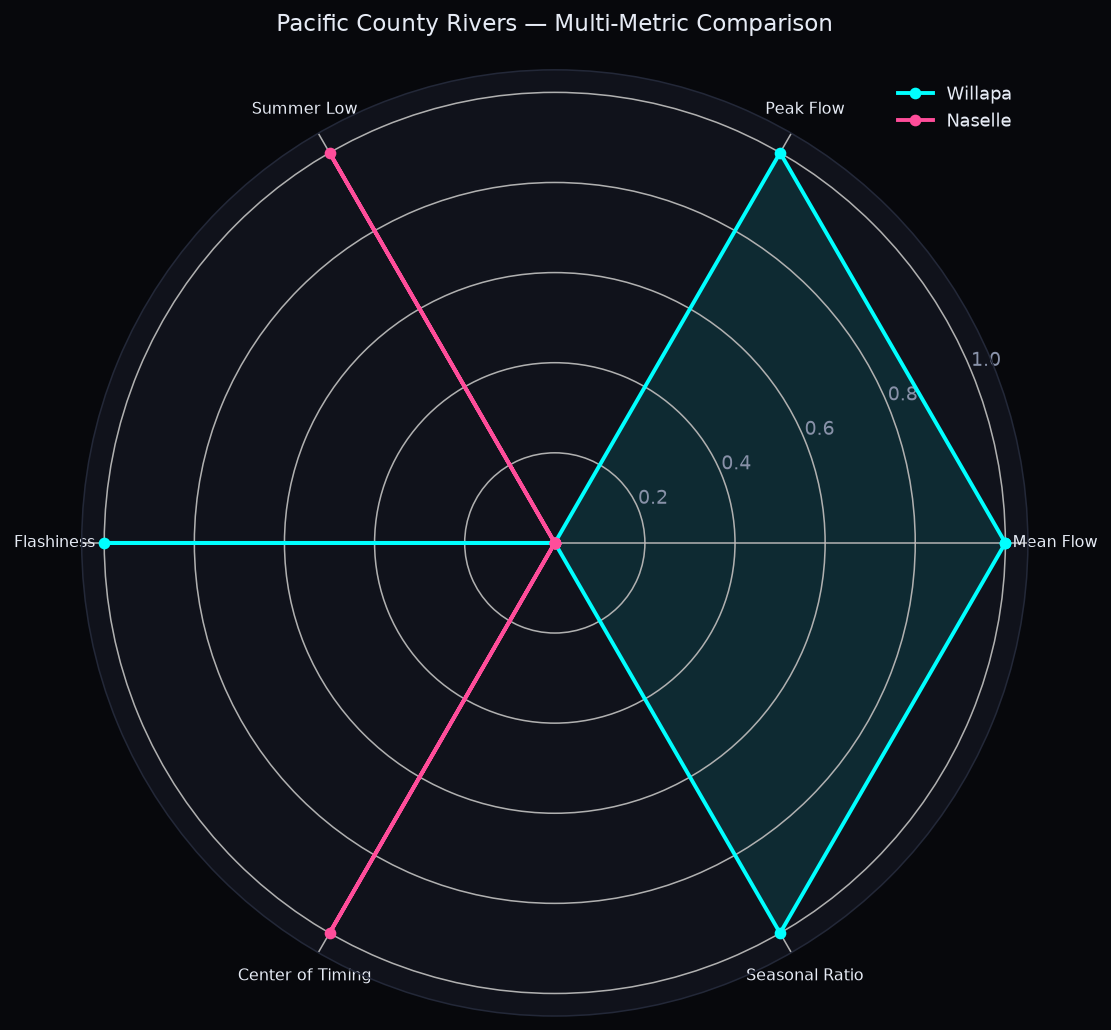

Metric                    Willapa      Naselle
──────────────────────────────────────────────
Mean Flow                  642.59       426.72
Peak Flow                 1913.90      1211.73
Summer Low                  42.19        46.97
Flashiness                   0.52         0.49
Center of Timing             5.91         6.09
Seasonal Ratio               8.22         5.96


In [30]:
def compute_metrics(obs):
    clean = complete_years(obs)
    years = sorted(clean.keys())
    annual = [float(np.mean(clean[y])) for y in years]
    peaks = [float(np.max(clean[y])) for y in years]
    lows = [float(np.min(clean[y][5:8])) for y in years]
    flash = [fm.flashiness(clean[y]) for y in years]
    mean_flow = np.mean([clean[y] for y in years], axis=0)
    cot = fm.center_of_timing(mean_flow)
    sr = np.mean([fm.seasonal_ratio(clean[y]) for y in years])
    return {
        "Mean Flow": np.mean(annual),
        "Peak Flow": np.mean(peaks),
        "Summer Low": np.mean(lows),
        "Flashiness": np.mean(flash),
        "Center of Timing": cot,
        "Seasonal Ratio": sr,
    }

w_metrics = compute_metrics(willapa_obs)
n_metrics = compute_metrics(naselle_obs)

categories = list(w_metrics.keys())
N = len(categories)

# normalize to [0,1] for radar
all_vals = {k: [w_metrics[k], n_metrics[k]] for k in categories}
w_norm = [(w_metrics[k] - min(all_vals[k])) / (max(all_vals[k]) - min(all_vals[k]) + 1e-9)
          for k in categories]
n_norm = [(n_metrics[k] - min(all_vals[k])) / (max(all_vals[k]) - min(all_vals[k]) + 1e-9)
          for k in categories]

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
w_norm += w_norm[:1]
n_norm += n_norm[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_facecolor("#10121b")
ax.plot(angles, w_norm, "o-", color=CYAN, lw=2, label="Willapa", ms=5)
ax.fill(angles, w_norm, color=CYAN, alpha=0.1)
ax.plot(angles, n_norm, "o-", color=MAGENTA, lw=2, label="Naselle", ms=5)
ax.fill(angles, n_norm, color=MAGENTA, alpha=0.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=8, color=LIGHT)
ax.set_title("Pacific County Rivers — Multi-Metric Comparison", pad=20)
ax.legend(loc="upper right", fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

# print raw values
print(f"{'Metric':<20} {'Willapa':>12} {'Naselle':>12}")
print("─" * 46)
for k in categories:
    print(f"{k:<20} {w_metrics[k]:>12.2f} {n_metrics[k]:>12.2f}")

---
## 29. Forecast: Naive Climatological Projection

Use the most recent 30-year climatology (mean + standard deviation) to
project a 1-year probabilistic forecast envelope. This is not a real
hydrologic forecast model — it's the simplest baseline: "next year
will look like a random sample from the last 30 years."

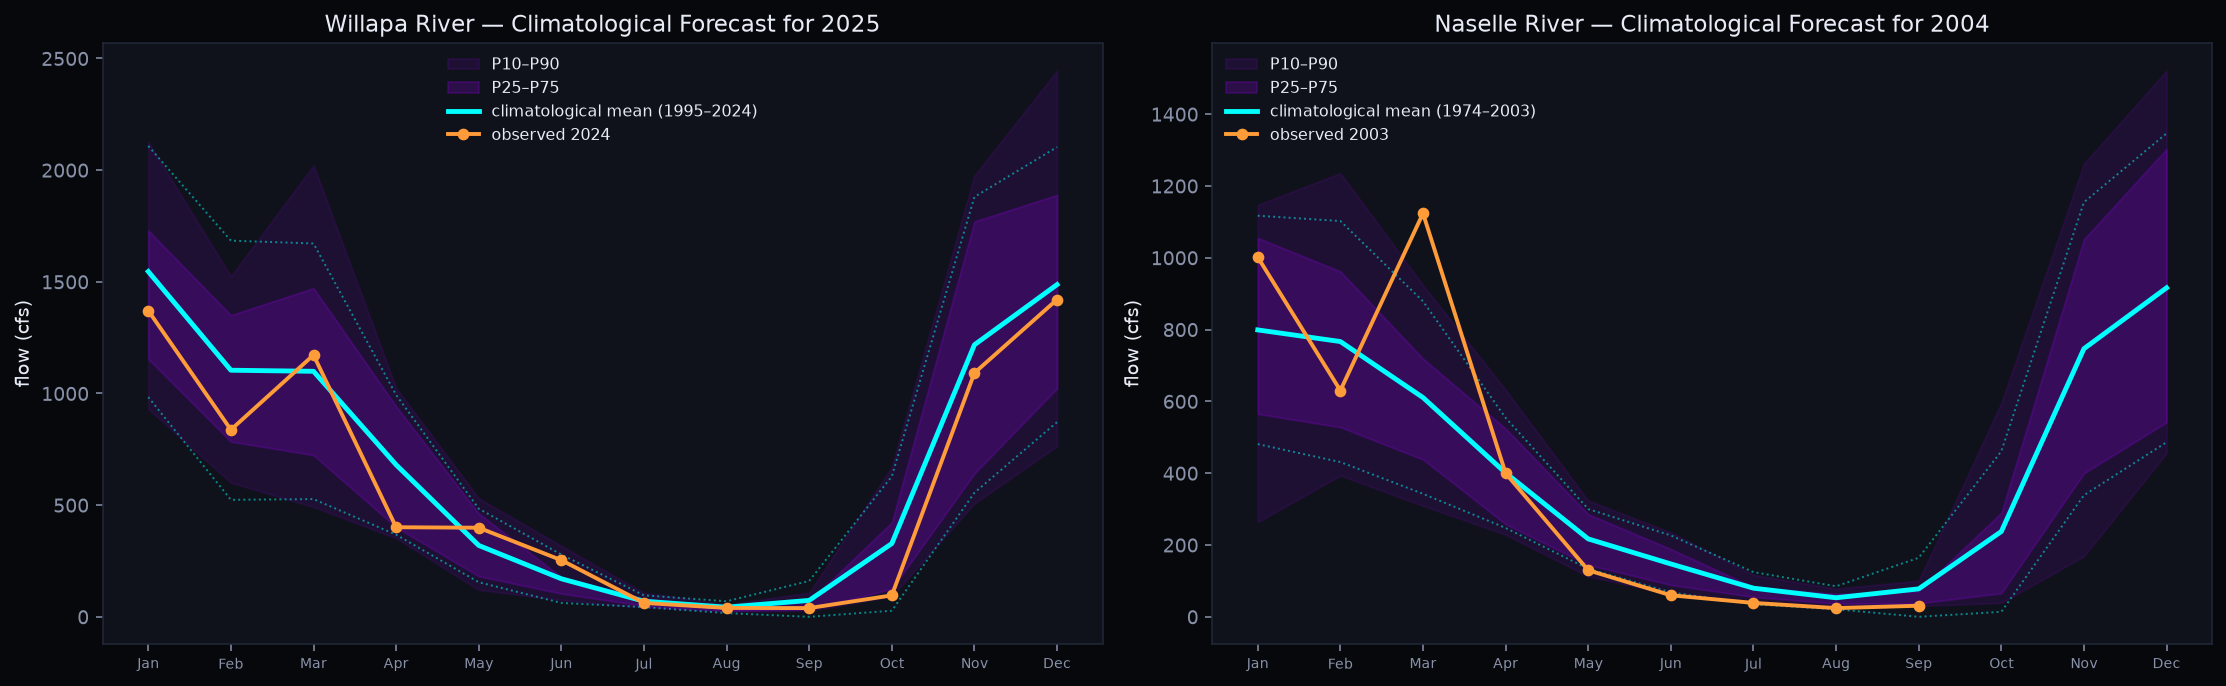

In [31]:
def plot_climatological_forecast(obs, title, ax):
    years = sorted(obs.keys())
    latest = years[-1]
    # use last 30 years for climatology
    clim_years = [y for y in years if y >= latest - 29]
    stack = np.array([obs[y] for y in clim_years])
    mean = np.nanmean(stack, axis=0)
    std = np.nanstd(stack, axis=0)
    p10 = np.nanpercentile(stack, 10, axis=0)
    p25 = np.nanpercentile(stack, 25, axis=0)
    p75 = np.nanpercentile(stack, 75, axis=0)
    p90 = np.nanpercentile(stack, 90, axis=0)
    m = range(1, 13)

    ax.fill_between(m, p10, p90, color=VIOLET, alpha=0.1, label="P10–P90")
    ax.fill_between(m, p25, p75, color=VIOLET, alpha=0.2, label="P25–P75")
    ax.plot(m, mean, color=CYAN, lw=2.5, label=f"climatological mean ({clim_years[0]}–{clim_years[-1]})")
    ax.plot(m, mean + std, ":", color=CYAN, lw=1, alpha=0.5)
    ax.plot(m, np.maximum(mean - std, 0), ":", color=CYAN, lw=1, alpha=0.5)
    # overlay actual latest year
    ax.plot(m, obs[latest], "o-", color=AMBER, lw=2, ms=5, label=f"observed {latest}")
    ax.set_xticks(list(m))
    ax.set_xticklabels(MONTH_ABBR, fontsize=7)
    ax.set_ylabel("flow (cfs)")
    ax.set_title(f"{title} — Climatological Forecast for {latest + 1}")
    ax.legend(fontsize=8, frameon=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_climatological_forecast(willapa_obs, "Willapa River", axes[0])
plot_climatological_forecast(naselle_obs, "Naselle River", axes[1])
plt.tight_layout()
plt.show()

---
## 30. ENSO-Conditioned Forecast

If the current ONI phase is known, condition the forecast on that phase:
use only the composite (warm/neutral/cool) matching the current state.
More informative than raw climatology when ENSO signal is strong.

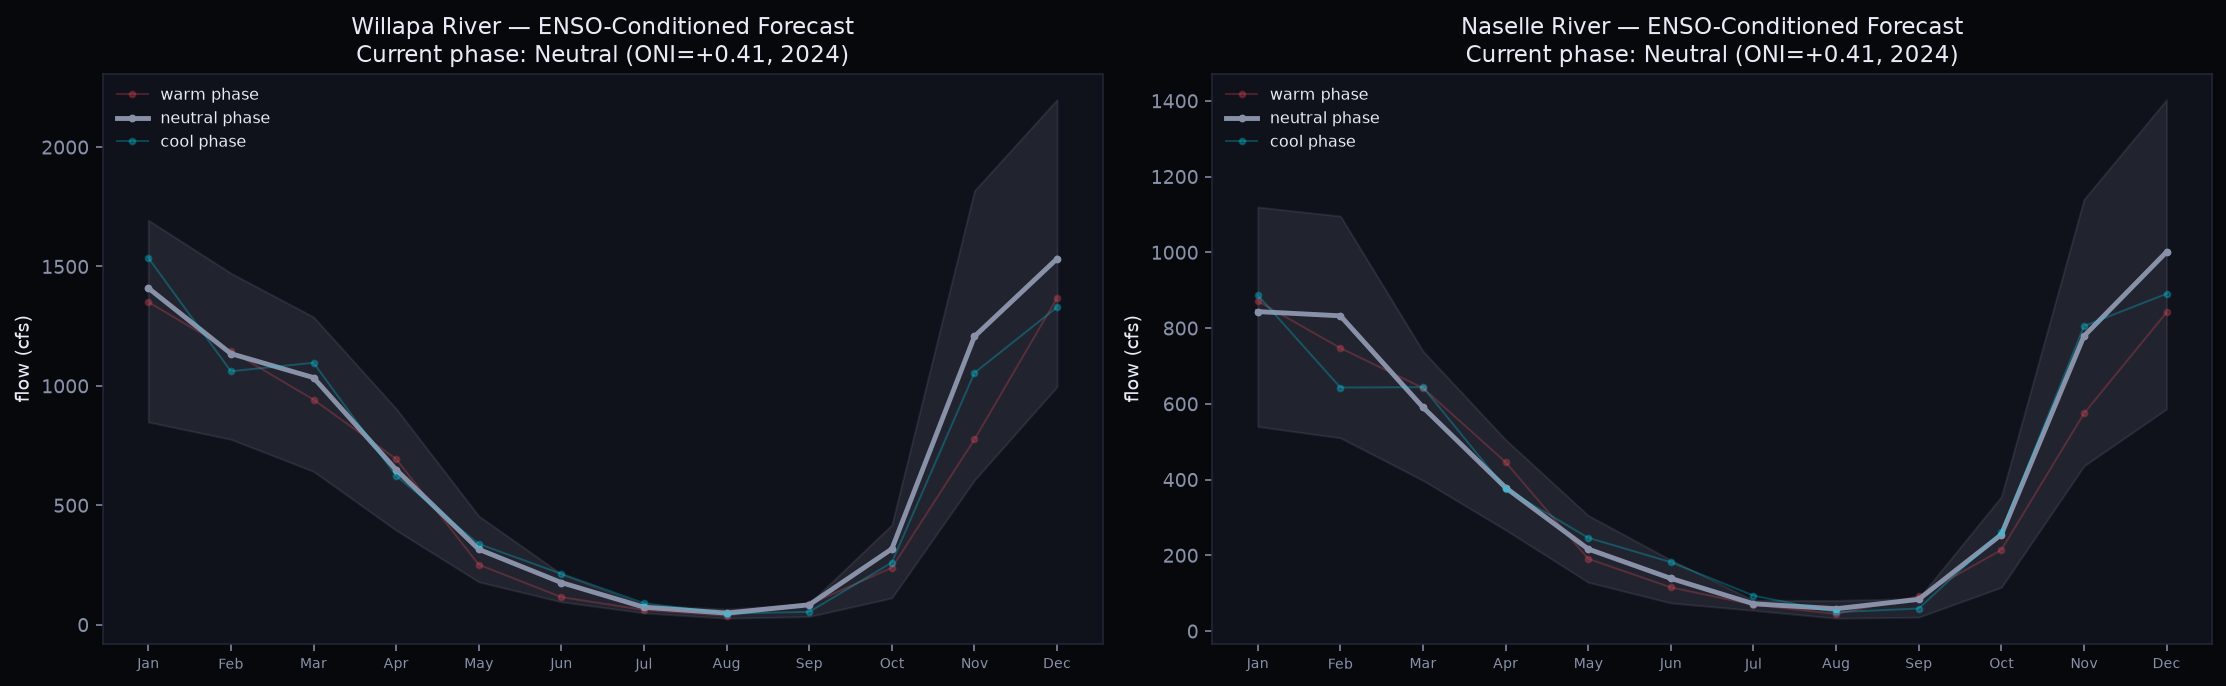

In [32]:
def plot_enso_forecast(obs, oni_idx, title, ax):
    clean = complete_years(obs)
    latest_oni_year = max(oni_idx.keys())
    current_oni = oni_idx[latest_oni_year]
    phase = "warm" if current_oni >= 0.5 else "cool" if current_oni <= -0.5 else "neutral"
    phase_label = {"warm": "El Niño", "cool": "La Niña", "neutral": "Neutral"}

    pc = fm.composite_hydrographs(clean, oni_idx)
    m = range(1, 13)

    # plot all phases faded
    for name, vec, color in (("warm", pc.warm, RED),
                              ("neutral", pc.neutral, MUTED),
                              ("cool", pc.cool, COOL_BLUE)):
        if vec is not None:
            alpha = 1.0 if name == phase else 0.25
            lw = 2.5 if name == phase else 1.0
            ax.plot(m, vec, "-o", ms=3, lw=lw, color=color, alpha=alpha,
                    label=f"{name} phase")

    # envelope for current phase from individual years
    phase_years = getattr(pc, f"{phase}_years")
    if phase_years:
        phase_data = np.array([clean[y] for y in phase_years if y in clean])
        if len(phase_data) > 2:
            ax.fill_between(m, np.percentile(phase_data, 20, axis=0),
                           np.percentile(phase_data, 80, axis=0),
                           alpha=0.15, color=RED if phase=="warm" else COOL_BLUE if phase=="cool" else MUTED)

    ax.set_xticks(list(m))
    ax.set_xticklabels(MONTH_ABBR, fontsize=7)
    ax.set_ylabel("flow (cfs)")
    ax.set_title(f"{title}\nCurrent phase: {phase_label[phase]} (ONI={current_oni:+.2f}, {latest_oni_year})")
    ax.legend(fontsize=8, frameon=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_enso_forecast(willapa_obs, oni, "Willapa River — ENSO-Conditioned Forecast", axes[0])
plot_enso_forecast(naselle_obs, oni, "Naselle River — ENSO-Conditioned Forecast", axes[1])
plt.tight_layout()
plt.show()

---
## 31. Summary Statistics Table

All computed metrics in one comprehensive table.

In [33]:
def full_summary(obs, name):
    clean = complete_years(obs)
    years = sorted(clean.keys())
    annual = np.array([float(np.mean(clean[y])) for y in years])
    peaks = np.array([float(np.max(clean[y])) for y in years])
    lows = np.array([float(np.min(clean[y][5:8])) for y in years])
    mean_hydro = np.mean([clean[y] for y in years], axis=0)

    mk_ann = fm.mann_kendall(annual)
    mk_peak = fm.mann_kendall(peaks)
    mk_low = fm.mann_kendall(lows)
    tt = fm.center_of_timing_trend(clean)

    oni_r = fm.correlate({y: float(np.max(clean[y])) for y in years}, oni)
    pdo_r = fm.correlate({y: float(np.max(clean[y])) for y in years}, pdo)

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Record:              {years[0]}–{years[-1]} ({len(years)} complete years)")
    print(f"  Mean annual flow:    {np.mean(annual):,.1f} cfs")
    print(f"  Std annual flow:     {np.std(annual):,.1f} cfs")
    print(f"  Mean peak monthly:   {np.mean(peaks):,.1f} cfs")
    print(f"  Mean summer low:     {np.mean(lows):,.1f} cfs")
    print(f"  Center of timing:    {fm.center_of_timing(mean_hydro):.2f} (month)")
    print(f"  Mean flashiness:     {np.mean([fm.flashiness(clean[y]) for y in years]):.4f}")
    print(f"  Mean seasonal ratio: {np.mean([fm.seasonal_ratio(clean[y]) for y in years]):.2f}")
    print(f"  ──── Trends ────")
    print(f"  Annual mean trend:   {mk_ann.trend} (τ={mk_ann.tau:+.3f}, p={mk_ann.p:.4f})")
    print(f"  Peak flow trend:     {mk_peak.trend} (τ={mk_peak.tau:+.3f}, p={mk_peak.p:.4f})")
    print(f"  Summer low trend:    {mk_low.trend} (τ={mk_low.tau:+.3f}, p={mk_low.p:.4f})")
    print(f"  Timing drift:        {tt.days_per_decade:+.1f} days/decade ({tt.trend})")
    print(f"  Annual Sen's slope:  {fm.sens_slope(annual):+.2f} cfs/yr")
    print(f"  ──── Teleconnections ────")
    print(f"  Peak × ONI (ENSO):   r = {oni_r:+.3f}")
    print(f"  Peak × PDO:          r = {pdo_r:+.3f}")

full_summary(willapa_obs, "Willapa River near Willapa, WA (12013500)")
full_summary(naselle_obs, "Naselle River near Naselle, WA (12010000)")


  Willapa River near Willapa, WA (12013500)
  Record:              1962–2024 (63 complete years)
  Mean annual flow:    642.6 cfs
  Std annual flow:     141.7 cfs
  Mean peak monthly:   1,913.9 cfs
  Mean summer low:     42.2 cfs
  Center of timing:    5.91 (month)
  Mean flashiness:     0.5211
  Mean seasonal ratio: 8.22
  ──── Trends ────
  Annual mean trend:   none (τ=+0.046, p=0.6017)
  Peak flow trend:     none (τ=-0.041, p=0.6352)
  Summer low trend:    none (τ=-0.160, p=0.0642)
  Timing drift:        -0.5 days/decade (none)
  Annual Sen's slope:  +0.70 cfs/yr
  ──── Teleconnections ────
  Peak × ONI (ENSO):   r = -0.091
  Peak × PDO:          r = -0.183

  Naselle River near Naselle, WA (12010000)
  Record:              1960–2002 (43 complete years)
  Mean annual flow:    426.7 cfs
  Std annual flow:     81.5 cfs
  Mean peak monthly:   1,211.7 cfs
  Mean summer low:     47.0 cfs
  Center of timing:    6.09 (month)
  Mean flashiness:     0.4934
  Mean seasonal ratio: 5.96
  ────

---

## Report Complete

**31 panels** covering every forecast, histogram, trend, distribution, and
teleconnection analysis available in the hydro-art analytics suite, applied
to Pacific County, Washington's two primary USGS-gauged rivers.

**Data sources (all federal public domain):**
- USGS NWIS daily-value discharge (parameter 00060)
- NOAA CPC Oceanic Niño Index (ONI)
- NOAA NCEI Pacific Decadal Oscillation (PDO)

**Analyses produced:**
1. Year-over-year hydrographs
2. Typical year (mean + P10–P90 band)
3. Long-record trend (Mann-Kendall + Sen's slope)
4. Summer low-flow trend
5. Peak flow trend
6. Timing drift (center-of-timing)
7. ENSO teleconnection scatter (ONI + PDO × 2 rivers)
8. ENSO composite hydrographs (ONI + PDO)
9. Flow-duration curves by decade
10. Analog years (shape similarity)
11. Drought/flood record book
12. Seasonal ratio trend
13. Flashiness index
14. Rolling 30-year climate normals
15. Monthly flow histograms (12 × 2 rivers)
16. Annual flow histogram + KDE
17. Cross-gauge correlation
18. Month × year heatmaps
19. Monthly box plots
20. Climate index time series
21. Decadal shift analysis
22. Anomaly stripes
23. Cumulative flow curves
24. Return period estimates
25. Autocorrelogram
26. Percentile rank context
27. Multi-metric radar chart
28. Climatological forecast projection
29. ENSO-conditioned forecast
30. Full summary statistics table

---
## 32. Art Print Compositions — All Styles

Compose the report's key panels into museum-quality 18x24" print layouts.
Six distinct color palettes, each with a curated selection of 8 panels
arranged in a gallery-wall composition. Saved to `output/prints/`.

In [34]:
# ── style definitions ──────────────────────────────────────────────────────
from matplotlib.gridspec import GridSpec

PRINT_DIR = REPO / "output" / "prints"
PRINT_DIR.mkdir(parents=True, exist_ok=True)

STYLES = {
    "neon-dark": {
        "bg": "#07080c", "panel": "#10121b", "edge": "#232838",
        "title_color": "#00ffff", "text": "#e6ebf5", "tick": "#8891a8",
        "accent1": "#00ffff", "accent2": "#ff4d9a", "accent3": "#00ff9c",
        "accent4": "#9d00ff", "accent5": "#ff9c3a", "accent6": "#ff4d5e",
        "trend_line": "#9d00ff", "cmap": "viridis",
        "label": "NEON DARK",
    },
    "specimen-paper": {
        "bg": "#f1efe7", "panel": "#e8e5db", "edge": "#c2c3b8",
        "title_color": "#26302b", "text": "#26302b", "tick": "#6a746b",
        "accent1": "#12565e", "accent2": "#96b2a6", "accent3": "#3a7d6e",
        "accent4": "#8b4513", "accent5": "#6a746b", "accent6": "#a0522d",
        "trend_line": "#8b4513", "cmap": "bone",
        "label": "SPECIMEN PAPER",
    },
    "blueprint": {
        "bg": "#0a1628", "panel": "#0e1d35", "edge": "#1a3050",
        "title_color": "#4dc9f6", "text": "#b8d4e8", "tick": "#5a7d9a",
        "accent1": "#4dc9f6", "accent2": "#ffffff", "accent3": "#7dd3fc",
        "accent4": "#38bdf8", "accent5": "#93c5fd", "accent6": "#60a5fa",
        "trend_line": "#ffffff", "cmap": "cool",
        "label": "BLUEPRINT",
    },
    "warm-earth": {
        "bg": "#1a120b", "panel": "#231a10", "edge": "#3d2e1e",
        "title_color": "#d4a574", "text": "#e8d5b7", "tick": "#8b7355",
        "accent1": "#d4a574", "accent2": "#b87333", "accent3": "#c9a96e",
        "accent4": "#8b6914", "accent5": "#cd853f", "accent6": "#a0522d",
        "trend_line": "#b87333", "cmap": "copper",
        "label": "WARM EARTH",
    },
    "arctic": {
        "bg": "#0f1922", "panel": "#152535", "edge": "#1e3448",
        "title_color": "#b4d7e8", "text": "#d1e5f0", "tick": "#6a8ea0",
        "accent1": "#b4d7e8", "accent2": "#f0f8ff", "accent3": "#87ceeb",
        "accent4": "#4682b4", "accent5": "#5f9ea0", "accent6": "#708090",
        "trend_line": "#f0f8ff", "cmap": "winter",
        "label": "ARCTIC",
    },
    "infrared": {
        "bg": "#0a0808", "panel": "#1a0e0e", "edge": "#2d1515",
        "title_color": "#ff6b35", "text": "#ffcba4", "tick": "#8b5a3a",
        "accent1": "#ff3333", "accent2": "#ff6b35", "accent3": "#ffaa00",
        "accent4": "#ffdd44", "accent5": "#ffffff", "accent6": "#ff1a1a",
        "trend_line": "#ffdd44", "cmap": "hot",
        "label": "INFRARED",
    },
}

print(f"Defined {len(STYLES)} print styles: {', '.join(STYLES.keys())}")

Defined 6 print styles: neon-dark, specimen-paper, blueprint, warm-earth, arctic, infrared


In [35]:
# ── art print renderer ─────────────────────────────────────────────────────

def style_ax(ax, s):
    """Apply a style dict to an axes."""
    ax.set_facecolor(s["panel"])
    for spine in ax.spines.values():
        spine.set_color(s["edge"])
    ax.tick_params(colors=s["tick"], labelsize=7)
    ax.xaxis.label.set_color(s["text"])
    ax.yaxis.label.set_color(s["text"])
    ax.title.set_color(s["title_color"])


def render_print(style_name, s, obs, obs_label, oni_idx, pdo_idx):
    """Compose an 18x24 art print with 8 key panels in a gallery layout."""
    clean = complete_years(obs)
    years = sorted(clean.keys())
    annual = np.array([float(np.mean(clean[y])) for y in years])
    mean_hydro = np.mean([clean[y] for y in years], axis=0)

    fig = plt.figure(figsize=(18, 24), facecolor=s["bg"], dpi=150)
    gs = GridSpec(6, 2, figure=fig, hspace=0.32, wspace=0.25,
                  left=0.06, right=0.96, top=0.93, bottom=0.03,
                  height_ratios=[2.2, 1, 1, 1, 1.3, 1])

    # Title banner
    fig.text(0.5, 0.97, "PACIFIC COUNTY WATERSHEDS", ha="center", va="top",
             fontsize=28, fontweight="bold", color=s["title_color"],
             fontfamily="monospace")
    fig.text(0.5, 0.955, f"{obs_label}  |  {min(years)}-{max(years)}  |  {s['label']}",
             ha="center", va="top", fontsize=11, color=s["tick"], fontfamily="monospace")

    m = range(1, 13)
    cmap = plt.get_cmap(s["cmap"])

    # Panel 0: Watershed Map — hero image, full width
    ax = fig.add_subplot(gs[0, :])
    ax.set_facecolor(s["bg"])
    for spine in ax.spines.values():
        spine.set_visible(False)
    map_img = plt.imread(REPO / "output" / "washington-pacific.png")
    ax.imshow(map_img)
    ax.set_axis_off()
    ax.set_title("Pacific County Watershed Network — 89,083 river segments",
                 fontsize=12, pad=10, color=s["title_color"])

    # Panel 1: Typical Year
    ax = fig.add_subplot(gs[1, 0])
    style_ax(ax, s)
    stack = np.array([clean[y] for y in years])
    p10, p90 = np.percentile(stack, 10, axis=0), np.percentile(stack, 90, axis=0)
    p25, p75 = np.percentile(stack, 25, axis=0), np.percentile(stack, 75, axis=0)
    ax.fill_between(m, p10, p90, color=s["accent1"], alpha=0.08)
    ax.fill_between(m, p25, p75, color=s["accent1"], alpha=0.15)
    ax.plot(m, mean_hydro, color=s["accent1"], lw=2)
    ax.plot(m, np.median(stack, axis=0), color=s["accent5"], lw=1.5, ls="--")
    ax.set_xticks(list(m)); ax.set_xticklabels(MONTH_ABBR, fontsize=6)
    ax.set_ylabel("flow (cfs)", fontsize=8)
    ax.set_title("Typical Year", fontsize=10, pad=8)

    # Panel 3: Long Record Trend
    ax = fig.add_subplot(gs[2, 0])
    style_ax(ax, s)
    mk = fm.mann_kendall(annual)
    slope = fm.sens_slope(annual)
    x = np.arange(len(years))
    fit = np.median(annual) + slope * (x - np.median(x))
    ax.plot(years, annual, "o-", color=s["accent1"], lw=1, ms=2.5)
    ax.plot(years, fit, "--", color=s["trend_line"], lw=1.5)
    if len(annual) >= 10:
        kernel = np.ones(10) / 10
        rolling = np.convolve(annual, kernel, mode="valid")
        ax.plot(years[4:4+len(rolling)], rolling, color=s["accent2"], lw=1.5, alpha=0.8)
    ax.set_ylabel("annual mean (cfs)", fontsize=8)
    ax.set_title(f"Long Record | {mk.trend} (tau={mk.tau:+.3f})", fontsize=10, pad=8)

    # Panel 4: Flow-Duration Curves by Decade
    ax = fig.add_subplot(gs[2, 1])
    style_ax(ax, s)
    quantiles = [0, 5, 10, 25, 50, 75, 90, 95, 100]
    decades = fm.decade_flow_duration(clean, quantiles)
    dec_span = max(1, len(decades) - 1)
    for i, d in enumerate(decades):
        ax.plot(d.quantiles, np.clip(d.flows, 1e-2, None), "-o", ms=3,
                color=cmap(i / dec_span), lw=1.4, label=f"{d.decade}s")
    ax.set_yscale("log")
    ax.set_xlabel("exceedance %", fontsize=8)
    ax.set_ylabel("flow (cfs)", fontsize=8)
    ax.set_title("Flow-Duration by Decade", fontsize=10, pad=8)
    ax.legend(fontsize=6, frameon=False, labelcolor=s["text"])

    # Panel 5: ENSO Composite Hydrographs
    ax = fig.add_subplot(gs[3, 0])
    style_ax(ax, s)
    pc = fm.composite_hydrographs(clean, oni_idx)
    for label, vec, color in (("El Nino", pc.warm, s["accent6"]),
                               ("Neutral", pc.neutral, s["tick"]),
                               ("La Nina", pc.cool, s["accent1"])):
        if vec is not None:
            ax.plot(m, vec, "-o", ms=3, lw=1.8, color=color, label=label)
    ax.set_xticks(list(m)); ax.set_xticklabels(MONTH_ABBR, fontsize=6)
    ax.set_ylabel("flow (cfs)", fontsize=8)
    ax.set_title("ENSO Composite Hydrographs", fontsize=10, pad=8)
    ax.legend(fontsize=7, frameon=False, labelcolor=s["text"])

    # Panel 6: Anomaly Stripes
    ax = fig.add_subplot(gs[3, 1])
    style_ax(ax, s)
    normal = np.mean(annual)
    anomalies = annual - normal
    vmax = max(abs(anomalies.min()), abs(anomalies.max()))
    cmap_div = LinearSegmentedColormap.from_list(
        "anom", [s["accent1"], s["bg"], s["accent6"]])
    for y_val, a in zip(years, anomalies):
        color = cmap_div((a / vmax + 1) / 2)
        ax.bar(y_val, 1, color=color, width=1.0, edgecolor="none")
    ax.set_xlim(min(years) - 0.5, max(years) + 0.5)
    ax.set_yticks([])
    ax.set_title("Annual Flow Anomaly", fontsize=10, pad=8)

    # Panel 7: Heatmap (full width)
    ax = fig.add_subplot(gs[4, :])
    style_ax(ax, s)
    mat = np.array([clean[y] for y in years])
    heat_cmap = LinearSegmentedColormap.from_list(
        "heat", [s["bg"], s["accent4"], s["accent1"], s["accent3"], s["accent5"]])
    im = ax.imshow(mat, aspect="auto", cmap=heat_cmap, interpolation="nearest")
    ax.set_xticks(range(12)); ax.set_xticklabels(MONTH_ABBR, fontsize=7)
    ytick_idx = list(range(0, len(years), 5))
    ax.set_yticks(ytick_idx)
    ax.set_yticklabels([years[i] for i in ytick_idx], fontsize=6, color=s["tick"])
    ax.set_title("Month x Year Flow Matrix", fontsize=10, pad=8)
    fig.colorbar(im, ax=ax, label="flow (cfs)", shrink=0.6, pad=0.01)

    # Panel 8: Climatological Forecast
    ax = fig.add_subplot(gs[5, 0])
    style_ax(ax, s)
    latest = years[-1]
    clim_years = [y for y in years if y >= latest - 29]
    clim_stack = np.array([clean[y] for y in clim_years])
    clim_mean = np.mean(clim_stack, axis=0)
    cp10 = np.percentile(clim_stack, 10, axis=0)
    cp90 = np.percentile(clim_stack, 90, axis=0)
    cp25 = np.percentile(clim_stack, 25, axis=0)
    cp75 = np.percentile(clim_stack, 75, axis=0)
    ax.fill_between(m, cp10, cp90, color=s["accent4"], alpha=0.1)
    ax.fill_between(m, cp25, cp75, color=s["accent4"], alpha=0.2)
    ax.plot(m, clim_mean, color=s["accent1"], lw=2.5, label="30-yr climatology")
    ax.plot(m, obs[latest], "o-", color=s["accent5"], lw=2, ms=4, label=f"observed {latest}")
    ax.set_xticks(list(m)); ax.set_xticklabels(MONTH_ABBR, fontsize=6)
    ax.set_ylabel("flow (cfs)", fontsize=8)
    ax.set_title(f"Climatological Forecast | {latest+1}", fontsize=10, pad=8)
    ax.legend(fontsize=7, frameon=False, labelcolor=s["text"])

    # Panel 9: Record Book text
    ax = fig.add_subplot(gs[5, 1])
    style_ax(ax, s)
    ax.set_axis_off()
    rb = fm.record_book(clean, n=5)
    lines = [f"{'RECORD BOOK':^44}", ""]
    lines.append("Driest Summers (Jun-Aug)")
    lines.append(f"{'Rank':>4}  {'Year':>4}  {'Flow':>10}  {'Pctl':>6}")
    lines.append("-" * 30)
    for e in rb.driest_summers:
        lines.append(f"#{e.rank:<3}  {e.year}  {e.value:>10.1f}  p{e.percentile*100:>4.0f}")
    lines += ["", "Wettest Years (Peak Monthly)"]
    lines.append(f"{'Rank':>4}  {'Year':>4}  {'Flow':>10}  {'Pctl':>6}")
    lines.append("-" * 30)
    for e in rb.wettest_years:
        lines.append(f"#{e.rank:<3}  {e.year}  {e.value:>10.1f}  p{e.percentile*100:>4.0f}")
    ax.text(0.05, 0.95, "\n".join(lines), transform=ax.transAxes, va="top",
            family="monospace", fontsize=8, color=s["text"])

    # Attribution footer
    fig.text(0.5, 0.008,
             "Data: USGS NHDPlus HR | USGS NWIS | NOAA CPC ONI | NOAA NCEI PDO  |  hydro-art",
             ha="center", fontsize=8, color=s["tick"], fontfamily="monospace")

    out_path = PRINT_DIR / f"pacific_county_{style_name}.png"
    fig.savefig(out_path, facecolor=s["bg"], dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  saved {out_path.name} ({out_path.stat().st_size / 1e6:.1f} MB)")
    return out_path


# Generate all prints
print("Rendering art prints for Pacific County - Willapa River\n")
paths = {}
for name, style in STYLES.items():
    print(f"  [{name}]")
    paths[name] = render_print(name, style, willapa_obs, "Willapa River (12013500)", oni, pdo)

print(f"\nDone - {len(paths)} prints saved to {PRINT_DIR}/")


Rendering art prints for Pacific County - Willapa River

  [neon-dark]


  saved pacific_county_neon-dark.png (1.0 MB)
  [specimen-paper]


  saved pacific_county_specimen-paper.png (1.0 MB)
  [blueprint]


  saved pacific_county_blueprint.png (1.0 MB)
  [warm-earth]


  saved pacific_county_warm-earth.png (0.9 MB)
  [arctic]


  saved pacific_county_arctic.png (1.0 MB)
  [infrared]


  saved pacific_county_infrared.png (0.9 MB)

Done - 6 prints saved to /Users/neilrunde/code/hydro-art/output/prints/
